# Práctica B4-T1 — Redes Confiables para Credit Scoring
## Versión final corregida

Esta version corrige fallos metodologicos de la entrega anterior y deja una practica mas defendible para el Taller B4-T1: **Diseno de Redes Confiables, Justicia e Incertidumbre**.

Se mantienen los elementos principales: capa custom financiera, FAIR loss, AutoML/Keras Tuner, MC Dropout, Pareto fairness-performance, analisis EXT_SOURCE, calibracion, bootstrap, ablation y exportacion de tablas/figuras.


## Regla global de seleccion

**Todas las decisiones de seleccion se toman en validation. El test se reserva para evaluacion final.**

Esto aplica a:

- mejor `lambda_corr` FAIR,
- threshold de clasificacion,
- threshold de alta incertidumbre,
- arquitectura de Keras Tuner,
- calibracion Platt Scaling,
- politica de revision humana.

El conjunto de test se usa solo despues de fijar esas decisiones.


## FAST_MODE

`FAST_MODE` permite ejecutar una version rapida para depuracion. Los resultados finales deben generarse con `FAST_MODE=False`.

Cuando `FAST_MODE=True`, se reduce el tamano de muestra, el numero de bootstrap, el numero de muestras MC Dropout y las semillas del sweep FAIR.


## Checklist de requisitos metodologicos

| Requisito | Donde se cumple | Archivo generado |
|---|---|---|
| Test solo para reporte final | Regla global, lambda/threshold/calibracion/incertidumbre en validation | tablas finales en `tables/` |
| MC Dropout sin BatchNormalization | Builders con LayerNormalization y `assert_no_batchnorm` | `tables/uncertainty_threshold_validation.csv` |
| Umbral de incertidumbre en validation | MC Dropout validation -> percentil 90 -> test | `tables/uncertainty_threshold_validation.csv` |
| Politica MC separada de modelos | Tabla selectiva aparte | `tables/selective_prediction_policy_results.csv` |
| AutoML y fairness explicitos | Keras Tuner + Pareto sobre arquitectura optima | `tables/keras_tuner_trials_with_fairness.csv` |
| Bootstrap CI | Intervalos Base vs FAIR sobre test | `tables/bootstrap_ci_base_vs_fair.csv` |
| Sweep FAIR multi-seed | `SEEDS_FAIR_SWEEP` y resumen por lambda | `tables/lambda_sweep_summary_by_seed.csv` |
| Ablation capa custom | Sin ratios, ratios engineered, capa custom raw | `tables/custom_layer_ablation_results.csv` |
| Auditoria tanh | Saturacion de ratios raw | `tables/ratio_saturation_summary.csv` |
| Threshold por costes | Comparacion F1 vs coste economico | `tables/threshold_strategy_comparison.csv` |
| Calibracion | Platt Scaling solo con validation | `tables/calibration_results_base_vs_fair.csv` |
| Incertidumbre honesta | Separacion por clase predicha y EXT_SOURCE | `tables/uncertainty_by_predicted_class.csv` |
| README y requirements | Generacion automatica final | `README.md`, `requirements.txt`, `.gitignore` |


In [1]:
import os
import sys
import json
import math
import random
import shutil
import tempfile
import warnings
import subprocess
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from scipy import sparse

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import compute_sample_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

FAST_MODE = False
SAMPLE_FRAC = 0.25 if FAST_MODE else 1.0
N_BOOTSTRAP = 100 if FAST_MODE else 500
N_MC_SAMPLES = 30 if FAST_MODE else 100
SEEDS_FAIR_SWEEP = [42] if FAST_MODE else [42, 123, 2026]

RANDOM_STATE = 42
MAX_EPOCHS = 35 if FAST_MODE else 80
FAIRNESS_EPOCHS = 25 if FAST_MODE else 50
ABLATION_EPOCHS = 25 if FAST_MODE else 50
BATCH_SIZE = 1024
FAIR_BATCH_SIZE = 2048
TUNER_MAX_TRIALS = 5 if FAST_MODE else 15

RUN_KERAS_TUNER = True
INSTALL_KERAS_TUNER_IF_MISSING = True

DATA_PATH = Path("application_train.csv")
TABLE_DIR = Path("tables")
FIGURE_DIR = Path("figures")
MODEL_DIR = Path("models")

for directory in [TABLE_DIR, FIGURE_DIR, MODEL_DIR]:
    if directory.exists() and not directory.is_dir():
        raise NotADirectoryError(f"{directory.resolve()} existe pero no es una carpeta.")
    directory.mkdir(parents=True, exist_ok=True)

TUNER_DIR = Path(tempfile.gettempdir()) / "home_credit_aml_keras_tuner_v2_critica"
TUNER_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

def reset_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

reset_seeds(RANDOM_STATE)

print("TensorFlow:", tf.__version__)
print("FAST_MODE:", FAST_MODE)
print("SAMPLE_FRAC:", SAMPLE_FRAC)
print("N_BOOTSTRAP:", N_BOOTSTRAP)
print("N_MC_SAMPLES:", N_MC_SAMPLES)
print("SEEDS_FAIR_SWEEP:", SEEDS_FAIR_SWEEP)


TensorFlow: 2.21.0
FAST_MODE: False
SAMPLE_FRAC: 1.0
N_BOOTSTRAP: 500
N_MC_SAMPLES: 100
SEEDS_FAIR_SWEEP: [42, 123, 2026]


In [2]:
def ensure_keras_tuner():
    if importlib.util.find_spec("keras_tuner") is None:
        if not INSTALL_KERAS_TUNER_IF_MISSING:
            print("keras-tuner no esta instalado. Se omitira AutoML.")
            return None
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "keras-tuner"])
        except Exception as exc:
            print(f"No se pudo instalar keras-tuner: {exc}. Se omitira AutoML.")
            return None

    try:
        import keras_tuner as kt
        return kt
    except Exception as exc:
        print(f"keras-tuner no pudo importarse: {exc}. Se omitira AutoML.")
        return None


kt = ensure_keras_tuner() if RUN_KERAS_TUNER else None


## Carga de datos

`CODE_GENDER` se filtra a `M` y `F`, se codifica como variable sensible (`M=1`, `F=0`) y no se usa como predictor.


Shape: (307507, 123)
Tasa global de impago:
0.08072986956394489


,TARGET,proporcion
0,0,0.9193
1,1,0.0807


,CODE_GENDER,n,tasa_impago
0,F,202448,0.0700
1,M,105059,0.1014


,variable,missing_%
0,COMMONAREA_AVG,69.8722
1,COMMONAREA_MEDI,69.8722
2,COMMONAREA_MODE,69.8722
3,NONLIVINGAPARTMENTS_MODE,69.4332
4,NONLIVINGAPARTMENTS_MEDI,69.4332
5,NONLIVINGAPARTMENTS_AVG,69.4332
6,FONDKAPREMONT_MODE,68.3864
7,LIVINGAPARTMENTS_MEDI,68.3552
8,LIVINGAPARTMENTS_MODE,68.3552
9,LIVINGAPARTMENTS_AVG,68.3552


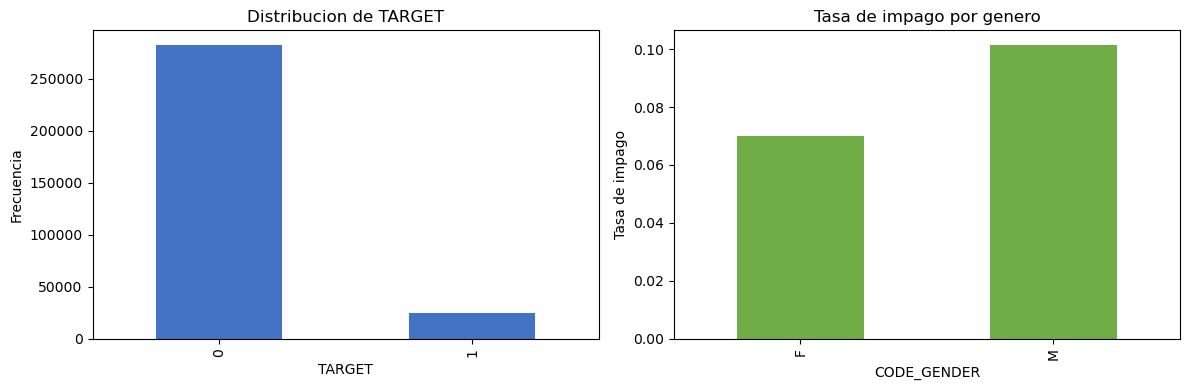

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError("No se encontro application_train.csv en la carpeta del notebook.")

df = pd.read_csv(DATA_PATH)
if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE).sort_index().reset_index(drop=True)

required_cols = ["TARGET", "CODE_GENDER"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Faltan columnas obligatorias: {missing_required}")

df = df[df["CODE_GENDER"].isin(["M", "F"])].copy()
df["TARGET"] = df["TARGET"].astype("int8")
df["SENSITIVE_GENDER"] = df["CODE_GENDER"].map({"F": 0, "M": 1}).astype("int8")

print("Shape:", df.shape)
print("Tasa global de impago:")
print(df["TARGET"].mean())

display(df["TARGET"].value_counts(normalize=True).rename_axis("TARGET").reset_index(name="proporcion"))
display(df.groupby("CODE_GENDER")["TARGET"].agg(n="count", tasa_impago="mean").reset_index())

missing_pct = df.isna().mean().mul(100).sort_values(ascending=False).rename("missing_%").reset_index()
missing_pct = missing_pct.rename(columns={"index": "variable"})
display(missing_pct.head(25))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["TARGET"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4472C4")
axes[0].set_title("Distribucion de TARGET")
axes[0].set_xlabel("TARGET")
axes[0].set_ylabel("Frecuencia")
df.groupby("CODE_GENDER")["TARGET"].mean().plot(kind="bar", ax=axes[1], color="#70AD47")
axes[1].set_title("Tasa de impago por genero")
axes[1].set_xlabel("CODE_GENDER")
axes[1].set_ylabel("Tasa de impago")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "exploracion_target_genero.png", dpi=140, bbox_inches="tight")
plt.show()


## Feature engineering y variables

Los ratios financieros se calculan antes del escalado. La capa custom posterior calcula ratios adicionales sobre variables monetarias raw no escaladas.


In [4]:
epsilon = 1e-6

def safe_divide(numerator, denominator, eps=epsilon):
    return numerator / (denominator.replace(0, np.nan) + eps)


if "DAYS_EMPLOYED" in df.columns:
    df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

df["ANNUITY_INCOME_RATIO"] = safe_divide(df["AMT_ANNUITY"], df["AMT_INCOME_TOTAL"])
df["CREDIT_INCOME_RATIO"] = safe_divide(df["AMT_CREDIT"], df["AMT_INCOME_TOTAL"])
df["ANNUITY_CREDIT_RATIO"] = safe_divide(df["AMT_ANNUITY"], df["AMT_CREDIT"])
df["GOODS_CREDIT_RATIO"] = safe_divide(df["AMT_GOODS_PRICE"], df["AMT_CREDIT"])
df["EMPLOYED_AGE_RATIO"] = safe_divide(df["DAYS_EMPLOYED"], df["DAYS_BIRTH"])

EXT_SOURCE_COLS = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
df["EXT_SOURCE_MEAN"] = df[EXT_SOURCE_COLS].mean(axis=1)
df["EXT_SOURCE_STD"] = df[EXT_SOURCE_COLS].std(axis=1)
df["EXT_SOURCE_MIN"] = df[EXT_SOURCE_COLS].min(axis=1)
df["EXT_SOURCE_MAX"] = df[EXT_SOURCE_COLS].max(axis=1)
df["EXT_SOURCE_MISSING_COUNT"] = df[EXT_SOURCE_COLS].isna().sum(axis=1)
df["EXT_SOURCE_AVAILABLE_COUNT"] = 3 - df["EXT_SOURCE_MISSING_COUNT"]
df.replace([np.inf, -np.inf], np.nan, inplace=True)

ENGINEERED_FINANCIAL_RATIOS = [
    "ANNUITY_INCOME_RATIO",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_CREDIT_RATIO",
    "GOODS_CREDIT_RATIO",
    "EMPLOYED_AGE_RATIO",
]

NUMERIC_FEATURES = [
    "AMT_INCOME_TOTAL",
    "AMT_ANNUITY",
    "AMT_CREDIT",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "REGION_RATING_CLIENT",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_CREDIT_RATIO",
    "GOODS_CREDIT_RATIO",
    "EMPLOYED_AGE_RATIO",
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_STD",
    "EXT_SOURCE_MIN",
    "EXT_SOURCE_MAX",
    "EXT_SOURCE_MISSING_COUNT",
]

CATEGORICAL_FEATURES = [
    "NAME_CONTRACT_TYPE",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
]

financial_raw_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_ANNUITY",
    "AMT_CREDIT",
    "AMT_GOODS_PRICE",
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
NUMERIC_FEATURES_NO_RATIOS = [c for c in NUMERIC_FEATURES if c not in ENGINEERED_FINANCIAL_RATIOS]
FEATURES_NO_RATIOS = NUMERIC_FEATURES_NO_RATIOS + CATEGORICAL_FEATURES

missing_predictors = [c for c in FEATURES + financial_raw_cols if c not in df.columns]
if missing_predictors:
    raise ValueError(f"Faltan variables predictoras esperadas: {missing_predictors}")

assert "CODE_GENDER" not in FEATURES
assert "SENSITIVE_GENDER" not in FEATURES

display(pd.DataFrame({"numeric_features": NUMERIC_FEATURES}))
display(pd.DataFrame({"categorical_features": CATEGORICAL_FEATURES}))


,numeric_features
0,AMT_INCOME_TOTAL
1,AMT_ANNUITY
2,AMT_CREDIT
3,AMT_GOODS_PRICE
4,DAYS_BIRTH
5,DAYS_EMPLOYED
6,CNT_CHILDREN
7,CNT_FAM_MEMBERS
8,REGION_RATING_CLIENT
9,EXT_SOURCE_1


,categorical_features
0,NAME_CONTRACT_TYPE
1,FLAG_OWN_CAR
2,FLAG_OWN_REALTY
3,NAME_INCOME_TYPE
4,NAME_EDUCATION_TYPE
5,NAME_FAMILY_STATUS
6,NAME_HOUSING_TYPE
7,OCCUPATION_TYPE
8,ORGANIZATION_TYPE


## Split y preprocesado sin data leakage

Los imputadores, escaladores, one-hot encoders y calibradores se ajustan solo con train o validation segun corresponda. Test no participa en ninguna seleccion.


In [5]:
X = df[FEATURES].copy()
X_no_ratios = df[FEATURES_NO_RATIOS].copy()
y = df["TARGET"].copy()
s = df["SENSITIVE_GENDER"].copy()
ids = df["SK_ID_CURR"].copy() if "SK_ID_CURR" in df.columns else pd.Series(df.index, name="SK_ID_CURR")

X_train_raw, X_temp_raw, X_train_no_ratios_raw, X_temp_no_ratios_raw, y_train, y_temp, s_train, s_temp, ids_train, ids_temp = train_test_split(
    X,
    X_no_ratios,
    y,
    s,
    ids,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_val_raw, X_test_raw, X_val_no_ratios_raw, X_test_no_ratios_raw, y_val, y_test, s_val, s_test, ids_val, ids_test = train_test_split(
    X_temp_raw,
    X_temp_no_ratios_raw,
    y_temp,
    s_temp,
    ids_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

def make_preprocessor(numeric_features, categorical_features):
    try:
        one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        one_hot = OneHotEncoder(handle_unknown="ignore", sparse=True)
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
            ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", one_hot)]), categorical_features),
        ],
        remainder="drop",
    )

def to_dense_float32(matrix):
    if sparse.issparse(matrix):
        return matrix.toarray().astype(np.float32)
    return np.asarray(matrix, dtype=np.float32)

preprocessor = make_preprocessor(NUMERIC_FEATURES, CATEGORICAL_FEATURES)
X_train_keras = to_dense_float32(preprocessor.fit_transform(X_train_raw))
X_val_keras = to_dense_float32(preprocessor.transform(X_val_raw))
X_test_keras = to_dense_float32(preprocessor.transform(X_test_raw))

preprocessor_no_ratios = make_preprocessor(NUMERIC_FEATURES_NO_RATIOS, CATEGORICAL_FEATURES)
X_train_no_ratios_keras = to_dense_float32(preprocessor_no_ratios.fit_transform(X_train_no_ratios_raw))
X_val_no_ratios_keras = to_dense_float32(preprocessor_no_ratios.transform(X_val_no_ratios_raw))
X_test_no_ratios_keras = to_dense_float32(preprocessor_no_ratios.transform(X_test_no_ratios_raw))

financial_imputer = SimpleImputer(strategy="median")
X_train_fin_raw = financial_imputer.fit_transform(X_train_raw[financial_raw_cols]).astype(np.float32)
X_val_fin_raw = financial_imputer.transform(X_val_raw[financial_raw_cols]).astype(np.float32)
X_test_fin_raw = financial_imputer.transform(X_test_raw[financial_raw_cols]).astype(np.float32)

y_train_np = y_train.to_numpy().astype(np.float32)
y_val_np = y_val.to_numpy().astype(np.float32)
y_test_np = y_test.to_numpy().astype(np.float32)
s_train_np = s_train.to_numpy().astype(np.float32)
s_val_np = s_val.to_numpy().astype(np.float32)
s_test_np = s_test.to_numpy().astype(np.float32)

input_dim = X_train_keras.shape[1]
input_dim_no_ratios = X_train_no_ratios_keras.shape[1]

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(y_train), len(y_val), len(y_test)],
    "default_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    "male_rate": [s_train.mean(), s_val.mean(), s_test.mean()],
})
display(split_summary)
print("Processed input:", X_train_keras.shape, X_val_keras.shape, X_test_keras.shape)
print("Processed input sin ratios:", X_train_no_ratios_keras.shape, X_val_no_ratios_keras.shape, X_test_no_ratios_keras.shape)
print("Raw financial input:", X_train_fin_raw.shape, X_val_fin_raw.shape, X_test_fin_raw.shape)


,split,rows,default_rate,male_rate
0,train,215254,0.0807,0.3417
1,validation,46126,0.0807,0.3430
2,test,46127,0.0807,0.3402


Processed input: (215254, 129) (46126, 129) (46127, 129)
Processed input sin ratios: (215254, 124) (46126, 124) (46127, 124)
Raw financial input: (215254, 4) (46126, 4) (46127, 4)


## Utilidades de metricas, thresholds, costes y bootstrap


In [6]:
def _safe_roc_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_score = np.asarray(y_score).astype(float).ravel()
    if len(np.unique(y_true)) < 2:
        return np.nan
    try:
        return roc_auc_score(y_true, y_score)
    except Exception:
        return np.nan

def _safe_pr_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_score = np.asarray(y_score).astype(float).ravel()
    if len(np.unique(y_true)) < 2:
        return np.nan
    try:
        return average_precision_score(y_true, y_score)
    except Exception:
        return np.nan

def _safe_corr(a, b):
    a = np.asarray(a, dtype=float).ravel()
    b = np.asarray(b, dtype=float).ravel()
    if len(a) < 2 or np.nanstd(a) < 1e-12 or np.nanstd(b) < 1e-12:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def _group_rate(values, mask):
    values = np.asarray(values)
    mask = np.asarray(mask).astype(bool)
    return float(values[mask].mean()) if mask.sum() > 0 else np.nan

def _tpr_fpr_by_group(y_true, y_pred, sensitive, group_value):
    mask = np.asarray(sensitive).astype(int) == group_value
    if mask.sum() == 0:
        return np.nan, np.nan
    yt = np.asarray(y_true).astype(int)[mask]
    yp = np.asarray(y_pred).astype(int)[mask]
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    return tpr, fpr

def evaluate_model(name, y_true, y_proba, sensitive, threshold=0.5, threshold_strategy="fixed_0.5"):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_proba = np.asarray(y_proba).astype(float).ravel()
    sensitive = np.asarray(sensitive).astype(int).ravel()
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    male_mask = sensitive == 1
    female_mask = sensitive == 0
    mean_pred_male = _group_rate(y_proba, male_mask)
    mean_pred_female = _group_rate(y_proba, female_mask)
    label_rate_male = _group_rate(y_pred, male_mask)
    label_rate_female = _group_rate(y_pred, female_mask)
    tpr_male, fpr_male = _tpr_fpr_by_group(y_true, y_pred, sensitive, 1)
    tpr_female, fpr_female = _tpr_fpr_by_group(y_true, y_pred, sensitive, 0)

    return {
        "model": name,
        "threshold_strategy": threshold_strategy,
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": _safe_roc_auc(y_true, y_proba),
        "pr_auc": _safe_pr_auc(y_true, y_proba),
        "brier_score": brier_score_loss(y_true, y_proba),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "mean_prediction": float(np.mean(y_proba)),
        "default_rate_real": float(np.mean(y_true)),
        "corr_pred_gender": _safe_corr(y_proba, sensitive),
        "demographic_parity_gap_score": abs(mean_pred_male - mean_pred_female)
            if not (np.isnan(mean_pred_male) or np.isnan(mean_pred_female)) else np.nan,
        "demographic_parity_gap_label": abs(label_rate_male - label_rate_female)
            if not (np.isnan(label_rate_male) or np.isnan(label_rate_female)) else np.nan,
        "equal_opportunity_gap": abs(tpr_male - tpr_female)
            if not (np.isnan(tpr_male) or np.isnan(tpr_female)) else np.nan,
        "fpr_gap": abs(fpr_male - fpr_female)
            if not (np.isnan(fpr_male) or np.isnan(fpr_female)) else np.nan,
    }

def find_best_threshold(y_true, y_proba, metric="f1"):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_threshold = 0.5
    best_score = -np.inf
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba).astype(float)
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == "balanced_accuracy":
            score = balanced_accuracy_score(y_true, y_pred)
        else:
            raise ValueError("metric debe ser 'f1' o 'balanced_accuracy'")
        if score > best_score:
            best_score = score
            best_threshold = threshold
    return float(best_threshold), float(best_score)

def cost_at_threshold(y_true, y_proba, threshold, cost_fp=1.0, cost_fn=5.0):
    y_true = np.asarray(y_true).astype(int)
    y_pred = (np.asarray(y_proba) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return float(cost_fp * fp + cost_fn * fn)

def find_best_threshold_by_cost(y_true, y_proba, cost_fp=1.0, cost_fn=5.0):
    thresholds = np.linspace(0.01, 0.99, 99)
    costs = [cost_at_threshold(y_true, y_proba, t, cost_fp, cost_fn) for t in thresholds]
    idx = int(np.argmin(costs))
    return float(thresholds[idx]), float(costs[idx])

def make_callbacks(monitor="val_auc", mode="max", patience=8):
    return [
        keras.callbacks.EarlyStopping(monitor=monitor, mode=mode, patience=patience, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor=monitor, mode=mode, patience=max(2, patience // 2), factor=0.5, min_lr=1e-6, verbose=1),
    ]

def plot_training_history(history, model_name, filename):
    hist = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(hist.index + 1, hist["loss"], label="loss")
    if "val_loss" in hist:
        axes[0].plot(hist.index + 1, hist["val_loss"], label="val_loss")
    axes[0].set_title(f"{model_name}: loss")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    if "auc" in hist:
        axes[1].plot(hist.index + 1, hist["auc"], label="auc")
    if "val_auc" in hist:
        axes[1].plot(hist.index + 1, hist["val_auc"], label="val_auc")
    axes[1].set_title(f"{model_name}: AUC")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    if "pr_auc" in hist:
        axes[2].plot(hist.index + 1, hist["pr_auc"], label="pr_auc")
    if "val_pr_auc" in hist:
        axes[2].plot(hist.index + 1, hist["val_pr_auc"], label="val_pr_auc")
    axes[2].set_title(f"{model_name}: PR-AUC")
    axes[2].legend()
    axes[2].grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=140, bbox_inches="tight")
    plt.show()

def bootstrap_metric_ci(y_true, y_pred_a, y_pred_b=None, sensitive=None, metric_func=None, n_boot=500, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred_a = np.asarray(y_pred_a)
    y_pred_b = None if y_pred_b is None else np.asarray(y_pred_b)
    sensitive = None if sensitive is None else np.asarray(sensitive)
    values = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        try:
            if y_pred_b is None:
                val = metric_func(y_true[idx], y_pred_a[idx], None if sensitive is None else sensitive[idx])
            else:
                val = metric_func(y_true[idx], y_pred_a[idx], y_pred_b[idx], None if sensitive is None else sensitive[idx])
        except Exception:
            continue
        if pd.notna(val):
            values.append(float(val))
    if not values:
        return np.nan, np.nan, np.nan, 0
    arr = np.asarray(values)
    return float(np.mean(arr)), float(np.percentile(arr, 2.5)), float(np.percentile(arr, 97.5)), int(len(arr))

def ci_text(row):
    return f"[{row['ci_95_low']:.4f}, {row['ci_95_high']:.4f}]"


## Benchmarks clasicos

Estos modelos se evaluan sobre todo test y se usan como referencia. La politica MC Dropout no se anade aqui porque tiene cobertura selectiva.


In [7]:
results_full_test = []

classic_models = {
    "Dummy prior": DummyClassifier(strategy="prior", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs"),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=250, learning_rate=0.05, l2_regularization=0.01, random_state=RANDOM_STATE),
}

for model_name, model in classic_models.items():
    print(f"Entrenando {model_name}...")
    model.fit(X_train_keras, y_train_np)
    val_proba = model.predict_proba(X_val_keras)[:, 1]
    test_proba = model.predict_proba(X_test_keras)[:, 1]
    threshold, val_f1 = find_best_threshold(y_val_np, val_proba, metric="f1")
    metrics = evaluate_model(model_name, y_test_np, test_proba, s_test_np, threshold, "best_f1_validation")
    metrics["evaluation_scope"] = "full_test"
    metrics["validation_best_f1"] = val_f1
    results_full_test.append(metrics)

display(pd.DataFrame(results_full_test))


Entrenando Dummy prior...
Entrenando Logistic Regression...
Entrenando HistGradientBoosting...


  File "c:\Users\david\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\david\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\david\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\david\anaconda3\Lib\subprocess.

,model,threshold_strategy,threshold,accuracy,balanced_accuracy,roc_auc,pr_auc,brier_score,precision,recall,f1,tn,fp,fn,tp,mean_prediction,default_rate_real,corr_pred_gender,demographic_parity_gap_score,demographic_parity_gap_label,equal_opportunity_gap,fpr_gap,evaluation_scope,validation_best_f1
0,Dummy prior,best_f1_validation,0.0100,0.0807,0.5000,0.5000,0.0807,0.0742,0.0807,1.0000,0.1494,0,42403,0,3724,0.0807,0.0807,NaN,0.0000,0.0000,0.0000,0.0000,full_test,0.1494
1,Logistic Regression,best_f1_validation,0.6600,0.8396,0.6494,0.7470,0.2346,0.2051,0.2306,0.4227,0.2984,37152,5251,2150,1574,0.4249,0.0807,0.1338,0.0563,0.0751,0.0904,0.0641,full_test,0.2919
2,HistGradientBoosting,best_f1_validation,0.1600,0.8588,0.6513,0.7605,0.2552,0.0674,0.2594,0.4039,0.3159,38110,4293,2220,1504,0.0809,0.0807,0.1172,0.0194,0.0645,0.1009,0.0514,full_test,0.3083


## Capa custom financiera y modelos sin BatchNormalization

Para estimar incertidumbre con MC Dropout evitamos BatchNormalization, porque llamar al modelo con `training=True` activaria tambien las estadisticas de entrenamiento de BatchNorm y contaminaria la varianza predictiva. Por eso usamos LayerNormalization o una arquitectura sin BatchNorm.


In [8]:
classes = np.array([0, 1])
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_np.astype(int))
class_weight_dict = {int(cls): float(weight) for cls, weight in zip(classes, class_weights)}
sample_weight_train = compute_sample_weight("balanced", y_train_np.astype(int)).astype(np.float32)
sample_weight_val = compute_sample_weight("balanced", y_val_np.astype(int)).astype(np.float32)
print("class_weight:", class_weight_dict)

class DebtRatioSaturationLayer(keras.layers.Layer):
    def __init__(self, units=8, alpha=1.0, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.alpha = alpha
        self.epsilon = epsilon
        self.projection = layers.Dense(units, activation="relu")

    def call(self, inputs):
        income = inputs[:, 0:1]
        annuity = inputs[:, 1:2]
        credit = inputs[:, 2:3]
        goods = inputs[:, 3:4]
        ratios = tf.concat(
            [
                annuity / (income + self.epsilon),
                credit / (income + self.epsilon),
                annuity / (credit + self.epsilon),
                goods / (credit + self.epsilon),
            ],
            axis=-1,
        )
        saturated = tf.math.tanh(self.alpha * ratios)
        return self.projection(saturated)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"units": self.units, "alpha": self.alpha, "epsilon": self.epsilon})
        return cfg

def correlation_penalty(y_pred, sensitive, eps=1e-7):
    y_pred = tf.reshape(tf.cast(y_pred, tf.float32), (-1, 1))
    sensitive = tf.reshape(tf.cast(sensitive, tf.float32), (-1, 1))
    pred_centered = y_pred - tf.reduce_mean(y_pred)
    sens_centered = sensitive - tf.reduce_mean(sensitive)
    numerator = tf.reduce_mean(pred_centered * sens_centered)
    denominator = tf.sqrt(tf.reduce_mean(tf.square(pred_centered)) * tf.reduce_mean(tf.square(sens_centered)) + eps)
    return tf.square(numerator / denominator)

class FairCorrelationLoss(keras.losses.Loss):
    def __init__(self, lambda_corr=0.3, eps=1e-7, name="fair_correlation_loss"):
        super().__init__(name=name)
        self.lambda_corr = lambda_corr
        self.eps = eps

    def call(self, y_true_ext, y_pred):
        y_true = tf.reshape(tf.cast(y_true_ext[:, 0], tf.float32), (-1, 1))
        sensitive = tf.reshape(tf.cast(y_true_ext[:, 1], tf.float32), (-1, 1))
        y_pred = tf.reshape(tf.cast(y_pred, tf.float32), (-1, 1))
        bce = keras.losses.binary_crossentropy(y_true, y_pred)
        return bce + self.lambda_corr * correlation_penalty(y_pred, sensitive, self.eps)

    def get_config(self):
        return {"lambda_corr": self.lambda_corr, "eps": self.eps, "name": self.name}

def make_fair_y(y_values, sensitive_values):
    return np.column_stack([
        np.asarray(y_values).astype(np.float32).ravel(),
        np.asarray(sensitive_values).astype(np.float32).ravel(),
    ]).astype(np.float32)

y_train_ext = make_fair_y(y_train_np, s_train_np)
y_val_ext = make_fair_y(y_val_np, s_val_np)

def add_norm_layer(x, use_batch_norm=False, use_layer_norm=True, name=None):
    if use_batch_norm:
        return layers.BatchNormalization(name=None if name is None else f"{name}_batchnorm")(x)
    if use_layer_norm:
        return layers.LayerNormalization(name=None if name is None else f"{name}_layernorm")(x)
    return x

def build_dense_model(processed_dim, dense_units=(64, 32), dropout_rates=(0.25, 0.20), learning_rate=1e-3,
                      use_batch_norm=False, use_layer_norm=True, fair_lambda=None, model_name="dense_model"):
    processed_input = keras.Input(shape=(processed_dim,), name="processed_input")
    x = processed_input
    for i, units in enumerate(dense_units):
        x = layers.Dense(units, activation="relu", name=f"dense_{i+1}")(x)
        x = add_norm_layer(x, use_batch_norm, use_layer_norm, name=f"norm_{i+1}")
        dropout = dropout_rates[i] if i < len(dropout_rates) else dropout_rates[-1]
        x = layers.Dropout(dropout, name=f"dropout_{i+1}")(x)
    output = layers.Dense(1, activation="sigmoid", name="default_probability")(x)
    model = keras.Model(processed_input, output, name=model_name)
    compile_model(model, fair_lambda=fair_lambda, learning_rate=learning_rate)
    return model

def build_custom_layer_model(processed_dim, dense_units=(64, 32), dropout_rates=(0.25, 0.20), learning_rate=1e-3,
                             use_batch_norm=False, use_layer_norm=True, fair_lambda=None, model_name="custom_model"):
    processed_input = keras.Input(shape=(processed_dim,), name="processed_input")
    raw_financial_input = keras.Input(shape=(4,), name="raw_financial_input")
    financial_features = DebtRatioSaturationLayer(units=8, alpha=1.0, name="debt_ratio_saturation")(raw_financial_input)
    x = layers.Concatenate(name="concat_processed_financial")([processed_input, financial_features])
    for i, units in enumerate(dense_units):
        x = layers.Dense(units, activation="relu", name=f"dense_{i+1}")(x)
        x = add_norm_layer(x, use_batch_norm, use_layer_norm, name=f"norm_{i+1}")
        dropout = dropout_rates[i] if i < len(dropout_rates) else dropout_rates[-1]
        x = layers.Dropout(dropout, name=f"dropout_{i+1}")(x)
    output = layers.Dense(1, activation="sigmoid", name="default_probability")(x)
    model = keras.Model([processed_input, raw_financial_input], output, name=model_name)
    compile_model(model, fair_lambda=fair_lambda, learning_rate=learning_rate)
    return model

def compile_model(model, fair_lambda=None, learning_rate=1e-3):
    if fair_lambda is None:
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
            loss=keras.losses.BinaryCrossentropy(),
            metrics=[keras.metrics.AUC(name="auc"), keras.metrics.AUC(curve="PR", name="pr_auc")],
        )
    else:
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
            loss=FairCorrelationLoss(lambda_corr=fair_lambda),
            metrics=[],
        )

def assert_no_batchnorm(model):
    batchnorm_layers = [
        layer.name for layer in model.layers
        if isinstance(layer, tf.keras.layers.BatchNormalization)
    ]
    if batchnorm_layers:
        raise ValueError(
            f"El modelo usado para MC Dropout contiene BatchNormalization: {batchnorm_layers}. "
            "Usa LayerNormalization o elimina BatchNorm."
        )


class_weight: {0: 0.5439085896794473, 1: 6.193646774472003}


## Limitacion de la FAIR loss batch-wise

La penalizacion FAIR se calcula por batch, por lo que es una aproximacion estocastica de la dependencia global entre prediccion y genero. Por ese motivo, la fairness real se audita posteriormente en validation y test con metricas globales: correlacion, demographic parity gap, equal opportunity gap y FPR gap.


## Base NN Custom Layer original sin FAIR

Modelo con capa custom, LayerNormalization y sin BatchNormalization. El threshold `best_threshold_base` se elige solo en validation.



Epoch 1/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - auc: 0.6948 - loss: 0.6495 - pr_auc: 0.1580 - val_auc: 0.7397 - val_loss: 0.5858 - val_pr_auc: 0.2123 - learning_rate: 0.0010
Epoch 2/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7275 - loss: 0.6121 - pr_auc: 0.1908 - val_auc: 0.7442 - val_loss: 0.5873 - val_pr_auc: 0.2204 - learning_rate: 0.0010
Epoch 3/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7344 - loss: 0.6055 - pr_auc: 0.2026 - val_auc: 0.7460 - val_loss: 0.5810 - val_pr_auc: 0.2249 - learning_rate: 0.0010
Epoch 4/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7385 - loss: 0.6022 - pr_auc: 0.2073 - val_auc: 0.7472 - val_loss: 0.5769 - val_pr_auc: 0.2266 - learning_rate: 0.0010
Epoch 5/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7414 - loss: 0.5996 - pr_auc: 0.2100 - val_auc: 0.7483 - val_loss: 0.5744 - val_pr_auc: 0.2296 - learning_rate: 0.0010
Epoch 6/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7431 - loss: 0.5983 - pr_auc: 0.2127 -

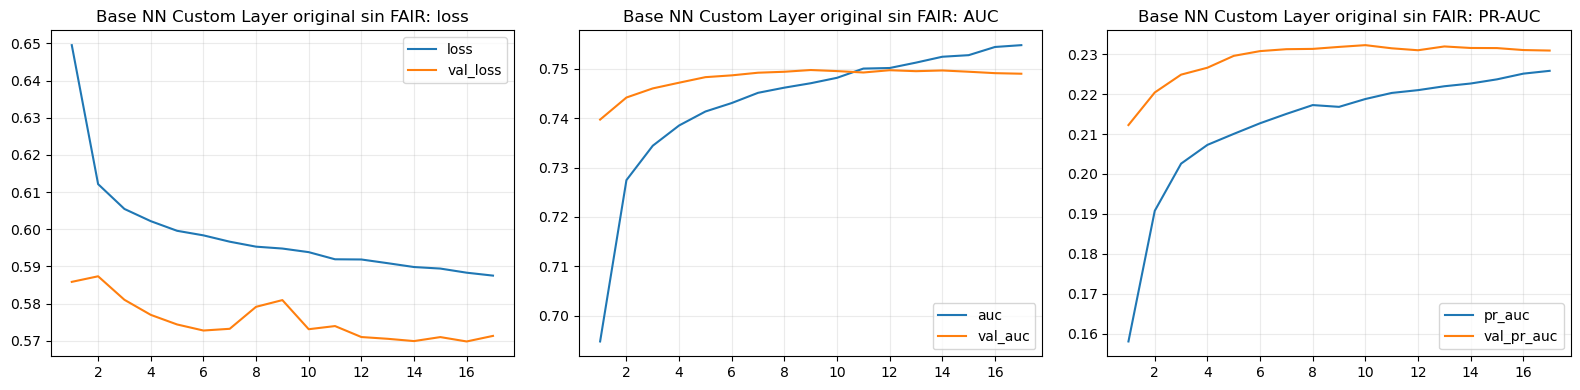

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
best_threshold_base: 0.65


,model,threshold_strategy,threshold,accuracy,balanced_accuracy,roc_auc,pr_auc,brier_score,precision,recall,f1,tn,fp,fn,tp,mean_prediction,default_rate_real,corr_pred_gender,demographic_parity_gap_score,demographic_parity_gap_label,equal_opportunity_gap,fpr_gap,lambda_corr,evaluation_scope
0,Base NN Custom Layer original sin FAIR,best_f1_validation,0.6500,0.8404,0.6521,0.7529,0.2402,0.1995,0.2334,0.4275,0.3019,37173,5230,2132,1592,0.4213,0.0807,0.1408,0.0563,0.0810,0.1096,0.0686,0.0000,full_test


In [9]:
reset_seeds(42)
base_custom_model = build_custom_layer_model(
    processed_dim=input_dim,
    dense_units=(64, 32),
    dropout_rates=(0.25, 0.20),
    learning_rate=1e-3,
    use_batch_norm=False,
    use_layer_norm=True,
    fair_lambda=None,
    model_name="Base_NN_CustomLayer_NoFair_Original",
)
assert_no_batchnorm(base_custom_model)

history_base_custom = base_custom_model.fit(
    [X_train_keras, X_train_fin_raw],
    y_train_np,
    validation_data=([X_val_keras, X_val_fin_raw], y_val_np),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(monitor="val_auc", mode="max", patience=8),
    verbose=1,
)
plot_training_history(history_base_custom, "Base NN Custom Layer original sin FAIR", "loss_curve_base_custom_no_fair.png")

y_val_proba_base = base_custom_model.predict([X_val_keras, X_val_fin_raw], batch_size=BATCH_SIZE).ravel()
y_test_proba_base = base_custom_model.predict([X_test_keras, X_test_fin_raw], batch_size=BATCH_SIZE).ravel()

best_threshold_base, best_val_f1_base = find_best_threshold(y_val_np, y_val_proba_base, metric="f1")
base_test_metrics = evaluate_model(
    "Base NN Custom Layer original sin FAIR",
    y_test_np,
    y_test_proba_base,
    s_test_np,
    threshold=best_threshold_base,
    threshold_strategy="best_f1_validation",
)
base_test_metrics["lambda_corr"] = 0.0
base_test_metrics["evaluation_scope"] = "full_test"
results_full_test.append(base_test_metrics)
print("best_threshold_base:", best_threshold_base)
display(pd.DataFrame([base_test_metrics]))


## Sweep FAIR multi-seed y seleccion de lambda con validation

Cada lambda se entrena con varias semillas para reducir dependencia de la inicializacion. La seleccion de `best_lambda_fair` usa medias de validation, nunca test.


In [10]:
lambdas = [0.0, 0.05, 0.1, 0.3, 0.5, 0.8, 1.0]
lambda_seed_val_rows = []
lambda_seed_test_rows = []

for seed in SEEDS_FAIR_SWEEP:
    for lambda_corr in lambdas:
        print(f"Entrenando FAIR seed={seed}, lambda={lambda_corr}...")
        reset_seeds(seed)
        tf.keras.backend.clear_session()
        model = build_custom_layer_model(
            processed_dim=input_dim,
            dense_units=(64, 32),
            dropout_rates=(0.25, 0.20),
            learning_rate=1e-3,
            use_batch_norm=False,
            use_layer_norm=True,
            fair_lambda=lambda_corr,
            model_name=f"Fair_seed_{seed}_lambda_{lambda_corr}",
        )
        assert_no_batchnorm(model)
        model.fit(
            [X_train_keras, X_train_fin_raw],
            y_train_ext,
            validation_data=([X_val_keras, X_val_fin_raw], y_val_ext, sample_weight_val),
            sample_weight=sample_weight_train,
            epochs=FAIRNESS_EPOCHS,
            batch_size=FAIR_BATCH_SIZE,
            callbacks=make_callbacks(monitor="val_loss", mode="min", patience=5),
            verbose=0,
        )
        val_proba = model.predict([X_val_keras, X_val_fin_raw], batch_size=BATCH_SIZE, verbose=0).ravel()
        test_proba = model.predict([X_test_keras, X_test_fin_raw], batch_size=BATCH_SIZE, verbose=0).ravel()
        threshold, _ = find_best_threshold(y_val_np, val_proba, metric="f1")
        val_metrics = evaluate_model("fair_seed_validation", y_val_np, val_proba, s_val_np, threshold, "best_f1_validation")
        test_metrics = evaluate_model("fair_seed_test", y_test_np, test_proba, s_test_np, threshold, "best_f1_validation")
        lambda_seed_val_rows.append({
            "seed": seed,
            "lambda_corr": lambda_corr,
            "split": "validation",
            "threshold": threshold,
            "roc_auc": val_metrics["roc_auc"],
            "pr_auc": val_metrics["pr_auc"],
            "corr_pred_gender": val_metrics["corr_pred_gender"],
            "abs_corr_pred_gender": abs(val_metrics["corr_pred_gender"]),
            "demographic_parity_gap_score": val_metrics["demographic_parity_gap_score"],
            "equal_opportunity_gap": val_metrics["equal_opportunity_gap"],
            "fpr_gap": val_metrics["fpr_gap"],
            "precision": val_metrics["precision"],
            "recall": val_metrics["recall"],
            "f1": val_metrics["f1"],
        })
        lambda_seed_test_rows.append({
            "seed": seed,
            "lambda_corr": lambda_corr,
            "split": "test",
            "threshold": threshold,
            "roc_auc": test_metrics["roc_auc"],
            "pr_auc": test_metrics["pr_auc"],
            "corr_pred_gender": test_metrics["corr_pred_gender"],
            "abs_corr_pred_gender": abs(test_metrics["corr_pred_gender"]),
            "demographic_parity_gap_score": test_metrics["demographic_parity_gap_score"],
            "equal_opportunity_gap": test_metrics["equal_opportunity_gap"],
            "fpr_gap": test_metrics["fpr_gap"],
            "precision": test_metrics["precision"],
            "recall": test_metrics["recall"],
            "f1": test_metrics["f1"],
        })

lambda_seed_results_validation = pd.DataFrame(lambda_seed_val_rows)
lambda_seed_results_test = pd.DataFrame(lambda_seed_test_rows)
lambda_seed_results_validation.to_csv(TABLE_DIR / "lambda_seed_results_validation.csv", index=False)
lambda_seed_results_test.to_csv(TABLE_DIR / "lambda_seed_results_test.csv", index=False)

val_summary = lambda_seed_results_validation.groupby("lambda_corr").agg(
    val_roc_auc_mean=("roc_auc", "mean"),
    val_roc_auc_std=("roc_auc", "std"),
    val_abs_corr_mean=("abs_corr_pred_gender", "mean"),
    val_abs_corr_std=("abs_corr_pred_gender", "std"),
    val_pr_auc_mean=("pr_auc", "mean"),
    val_demographic_parity_gap_mean=("demographic_parity_gap_score", "mean"),
).reset_index()

test_summary = lambda_seed_results_test.groupby("lambda_corr").agg(
    test_roc_auc_mean=("roc_auc", "mean"),
    test_roc_auc_std=("roc_auc", "std"),
    test_abs_corr_mean=("abs_corr_pred_gender", "mean"),
    test_abs_corr_std=("abs_corr_pred_gender", "std"),
    test_pr_auc_mean=("pr_auc", "mean"),
).reset_index()

lambda_sweep_summary_by_seed = val_summary.merge(test_summary, on="lambda_corr", how="left")
lambda_sweep_summary_by_seed["n_runs"] = len(SEEDS_FAIR_SWEEP)
lambda_sweep_summary_by_seed.to_csv(TABLE_DIR / "lambda_sweep_summary_by_seed.csv", index=False)
lambda_seed_results_validation.rename(columns={
    "roc_auc": "val_roc_auc",
    "pr_auc": "val_pr_auc",
    "corr_pred_gender": "val_corr_pred_gender",
    "abs_corr_pred_gender": "val_abs_corr_pred_gender",
    "demographic_parity_gap_score": "val_demographic_parity_gap_score",
}).to_csv(TABLE_DIR / "lambda_val_results.csv", index=False)
lambda_seed_results_test.rename(columns={
    "roc_auc": "test_roc_auc",
    "pr_auc": "test_pr_auc",
    "corr_pred_gender": "test_corr_pred_gender",
    "abs_corr_pred_gender": "test_abs_corr_pred_gender",
    "demographic_parity_gap_score": "test_demographic_parity_gap_score",
}).to_csv(TABLE_DIR / "lambda_test_results.csv", index=False)

candidate_lambdas = lambda_sweep_summary_by_seed[lambda_sweep_summary_by_seed["val_abs_corr_mean"] < 0.05].copy()
if not candidate_lambdas.empty:
    selected = candidate_lambdas.sort_values("val_roc_auc_mean", ascending=False).iloc[0]
    lambda_selection_rule = "Mayor val_roc_auc_mean con val_abs_corr_mean < 0.05"
else:
    lambda_sweep_summary_by_seed["selection_score"] = (
        lambda_sweep_summary_by_seed["val_roc_auc_mean"] - 0.05 * lambda_sweep_summary_by_seed["val_abs_corr_mean"]
    )
    selected = lambda_sweep_summary_by_seed.sort_values("selection_score", ascending=False).iloc[0]
    lambda_selection_rule = "Mayor val_roc_auc_mean - 0.05 * val_abs_corr_mean"

best_lambda_fair = float(selected["lambda_corr"])
print("best_lambda_fair:", best_lambda_fair)
print("Regla:", lambda_selection_rule)
display(lambda_sweep_summary_by_seed)


Entrenando FAIR seed=42, lambda=0.0...

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 21: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 16.
Entrenando FAIR seed=42, lambda=0.05...

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 22: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 17.
Entrenando FAIR seed=42, lambda=0.1...

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 18: R

,lambda_corr,val_roc_auc_mean,val_roc_auc_std,val_abs_corr_mean,val_abs_corr_std,val_pr_auc_mean,val_demographic_parity_gap_mean,test_roc_auc_mean,test_roc_auc_std,test_abs_corr_mean,test_abs_corr_std,test_pr_auc_mean,n_runs
0,0.0000,0.7491,0.0007,0.1391,0.0019,0.2296,0.0597,0.7525,0.0006,0.1367,0.0019,0.2395,3
1,0.0500,0.7493,0.0008,0.1182,0.0012,0.2299,0.0508,0.7528,0.0008,0.1159,0.0011,0.2398,3
2,0.1000,0.7490,0.0007,0.1031,0.0007,0.2296,0.0442,0.7526,0.0007,0.1009,0.0007,0.2395,3
3,0.3000,0.7479,0.0008,0.0688,0.0019,0.2289,0.0295,0.7518,0.0006,0.0669,0.0019,0.2389,3
4,0.5000,0.7471,0.0004,0.0513,0.0018,0.2290,0.0218,0.7512,0.0005,0.0498,0.0018,0.2386,3
5,0.8000,0.7465,0.0006,0.0396,0.0036,0.2285,0.0167,0.7509,0.0005,0.0386,0.0037,0.2380,3
6,1.0000,0.7466,0.0007,0.0363,0.0040,0.2284,0.0153,0.7506,0.0006,0.0350,0.0040,0.2382,3


## Modelo FAIR final reentrenado

Una vez elegido `best_lambda_fair` con validation multi-seed, se reentrena un modelo final con semilla principal 42. El threshold `best_threshold_fair` se fija en validation.


Epoch 1/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6700 - val_loss: 0.6083 - learning_rate: 0.0010
Epoch 2/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6241 - val_loss: 0.6040 - learning_rate: 0.0010
Epoch 3/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6142 - val_loss: 0.6022 - learning_rate: 0.0010
Epoch 4/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6101 - val_loss: 0.6010 - learning_rate: 0.0010
Epoch 5/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6075 - val_loss: 0.5999 - learning_rate: 0.0010
Epoch 6/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6048 - val_loss: 0.5995 - learning_rate: 0.0010
Epoch 7/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6041 - val_loss: 0.5990 - learning_rate: 0.0010
Epoch 8/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6023 - val_loss: 0.5986 - learning_rate: 0.0010
Epoch 9/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6019 - val_loss: 0.5984 - learning_rate: 0.0010
Epoch 10/8

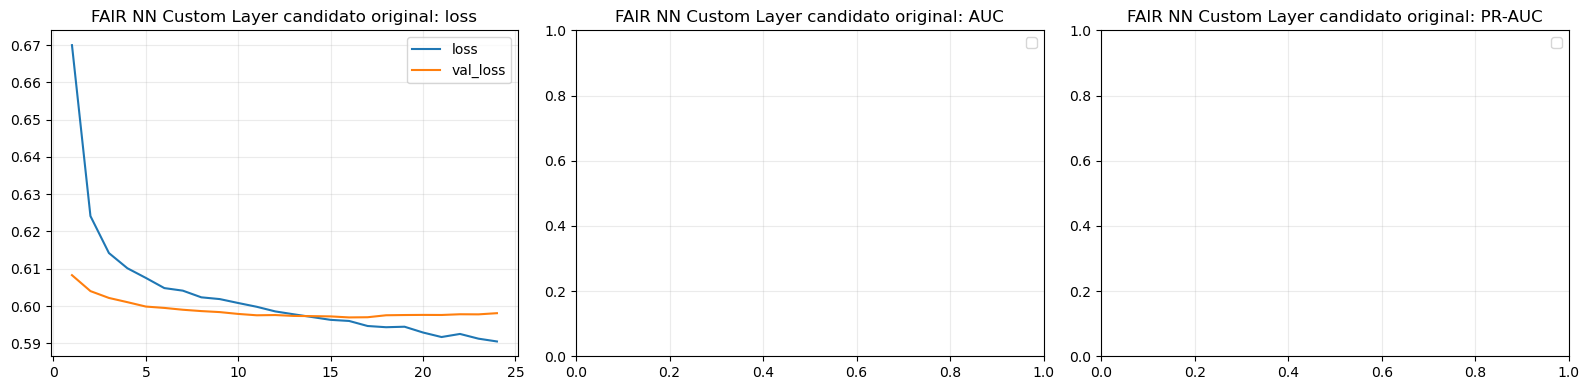

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
best_threshold_fair: 0.66


,model,threshold_strategy,threshold,accuracy,balanced_accuracy,roc_auc,pr_auc,brier_score,precision,recall,f1,tn,fp,fn,tp,mean_prediction,default_rate_real,corr_pred_gender,demographic_parity_gap_score,demographic_parity_gap_label,equal_opportunity_gap,fpr_gap,lambda_corr,evaluation_scope
0,FAIR NN Custom Layer candidato original,best_f1_validation,0.6600,0.8451,0.6475,0.7513,0.2397,0.2003,0.2364,0.4119,0.3004,37448,4955,2190,1534,0.4200,0.0807,0.0375,0.0154,0.0427,0.0408,0.0334,1.0000,full_test


In [11]:
reset_seeds(42)
tf.keras.backend.clear_session()
best_fair_model = build_custom_layer_model(
    processed_dim=input_dim,
    dense_units=(64, 32),
    dropout_rates=(0.25, 0.20),
    learning_rate=1e-3,
    use_batch_norm=False,
    use_layer_norm=True,
    fair_lambda=best_lambda_fair,
    model_name="Fair_NN_CustomLayer_Original",
)
assert_no_batchnorm(best_fair_model)

history_best_fair = best_fair_model.fit(
    [X_train_keras, X_train_fin_raw],
    y_train_ext,
    validation_data=([X_val_keras, X_val_fin_raw], y_val_ext, sample_weight_val),
    sample_weight=sample_weight_train,
    epochs=MAX_EPOCHS,
    batch_size=FAIR_BATCH_SIZE,
    callbacks=make_callbacks(monitor="val_loss", mode="min", patience=8),
    verbose=1,
)
plot_training_history(history_best_fair, "FAIR NN Custom Layer candidato original", "loss_curve_best_fair.png")

y_val_proba_fair = best_fair_model.predict([X_val_keras, X_val_fin_raw], batch_size=BATCH_SIZE).ravel()
y_test_proba_fair = best_fair_model.predict([X_test_keras, X_test_fin_raw], batch_size=BATCH_SIZE).ravel()
best_threshold_fair, best_val_f1_fair = find_best_threshold(y_val_np, y_val_proba_fair, metric="f1")

best_fair_test_metrics = evaluate_model(
    "FAIR NN Custom Layer candidato original",
    y_test_np,
    y_test_proba_fair,
    s_test_np,
    best_threshold_fair,
    "best_f1_validation",
)
best_fair_test_metrics["lambda_corr"] = best_lambda_fair
best_fair_test_metrics["evaluation_scope"] = "full_test"
results_full_test.append(best_fair_test_metrics)

print("best_threshold_fair:", best_threshold_fair)
display(pd.DataFrame([best_fair_test_metrics]))


## Curva de Pareto FAIR validation/test

La seleccion se hace con validation. La curva de test se muestra solo como reporte posterior.


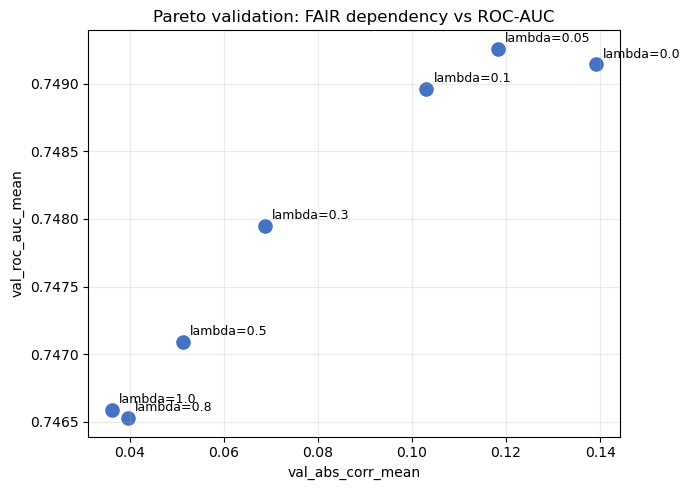

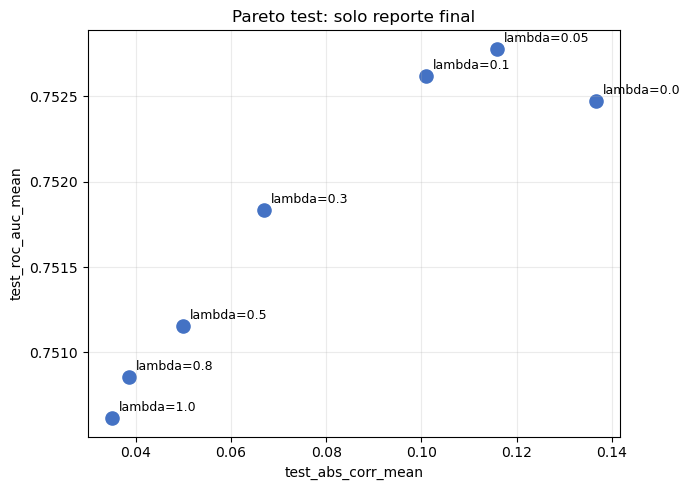

In [12]:
def plot_pareto(df_plot, x_col, y_col, label_col, title, filename):
    plt.figure(figsize=(7, 5))
    plt.scatter(df_plot[x_col], df_plot[y_col], s=90, color="#4472C4")
    for _, row in df_plot.iterrows():
        plt.annotate(f"lambda={row[label_col]}", (row[x_col], row[y_col]), textcoords="offset points", xytext=(5, 5), fontsize=9)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=140, bbox_inches="tight")
    plt.show()

plot_pareto(
    lambda_sweep_summary_by_seed,
    "val_abs_corr_mean",
    "val_roc_auc_mean",
    "lambda_corr",
    "Pareto validation: FAIR dependency vs ROC-AUC",
    "pareto_fairness_performance_validation.png",
)
plot_pareto(
    lambda_sweep_summary_by_seed,
    "test_abs_corr_mean",
    "test_roc_auc_mean",
    "lambda_corr",
    "Pareto test: solo reporte final",
    "pareto_fairness_performance_test.png",
)


## Threshold por coste economico

El umbral final de la practica se reporta por F1 para mantener comparacion estandar, pero en una aplicacion real de credito deberia elegirse con una funcion de costes. Un falso negativo (aprobar como buen pagador a quien tendra dificultad de pago) suele ser mas costoso que un falso positivo.


In [13]:
threshold_rows = []
for model_name, val_proba, test_proba, f1_threshold in [
    ("Base NN Custom Layer original sin FAIR", y_val_proba_base, y_test_proba_base, best_threshold_base),
    ("FAIR NN Custom Layer candidato original", y_val_proba_fair, y_test_proba_fair, best_threshold_fair),
]:
    cost_threshold, val_cost = find_best_threshold_by_cost(y_val_np, val_proba, cost_fp=1.0, cost_fn=5.0)
    strategies = [
        ("threshold_0_50", 0.5),
        ("best_f1_validation", f1_threshold),
        ("minimum_cost_validation", cost_threshold),
    ]
    for strategy_name, threshold in strategies:
        metrics = evaluate_model(model_name, y_test_np, test_proba, s_test_np, threshold, strategy_name)
        threshold_rows.append({
            "model": model_name,
            "threshold_strategy": strategy_name,
            "threshold": threshold,
            "cost_fp": 1.0,
            "cost_fn": 5.0,
            "total_cost_validation": cost_at_threshold(y_val_np, val_proba, threshold, 1.0, 5.0),
            "total_cost_test": cost_at_threshold(y_test_np, test_proba, threshold, 1.0, 5.0),
            "accuracy_test": metrics["accuracy"],
            "precision_test": metrics["precision"],
            "recall_test": metrics["recall"],
            "f1_test": metrics["f1"],
            "roc_auc_test": metrics["roc_auc"],
            "pr_auc_test": metrics["pr_auc"],
        })

threshold_strategy_comparison = pd.DataFrame(threshold_rows)
threshold_strategy_comparison.to_csv(TABLE_DIR / "threshold_strategy_comparison.csv", index=False)
display(threshold_strategy_comparison)


,model,threshold_strategy,threshold,cost_fp,cost_fn,total_cost_validation,total_cost_test,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test,pr_auc_test
0,Base NN Custom Layer original sin FAIR,threshold_0_50,0.5000,1.0000,5.0000,"18,704.0000","18,676.0000",0.7012,0.1660,0.6716,0.2663,0.7529,0.2402
1,Base NN Custom Layer original sin FAIR,best_f1_validation,0.6500,1.0000,5.0000,"16,024.0000","15,890.0000",0.8404,0.2334,0.4275,0.3019,0.7529,0.2402
2,Base NN Custom Layer original sin FAIR,minimum_cost_validation,0.6700,1.0000,5.0000,"15,971.0000","15,869.0000",0.8536,0.2441,0.3880,0.2997,0.7529,0.2402
3,FAIR NN Custom Layer candidato original,threshold_0_50,0.5000,1.0000,5.0000,"18,873.0000","18,823.0000",0.6959,0.1645,0.6780,0.2647,0.7513,0.2397
4,FAIR NN Custom Layer candidato original,best_f1_validation,0.6600,1.0000,5.0000,"15,981.0000","15,905.0000",0.8451,0.2364,0.4119,0.3004,0.7513,0.2397
5,FAIR NN Custom Layer candidato original,minimum_cost_validation,0.6700,1.0000,5.0000,"15,976.0000","15,908.0000",0.8511,0.2411,0.3931,0.2989,0.7513,0.2397


## Calibracion de probabilidades

Las redes entrenadas con class_weight tienden a producir probabilidades brutas demasiado altas. Por tanto, las probabilidades sin calibrar deben interpretarse como scores de ranking, no como PD reales. Para usarlas como probabilidades de default habria que calibrarlas.

Platt Scaling se entrena solo en validation y luego se aplica a test.


,model,brier_uncalibrated_test,brier_calibrated_test,mean_predicted_probability_uncalibrated,mean_predicted_probability_calibrated,real_default_rate_test,roc_auc_uncalibrated,roc_auc_calibrated
0,Base NN Custom Layer original sin FAIR,0.1995,0.0682,0.4213,0.0817,0.0807,0.7529,0.7529
1,FAIR NN Custom Layer candidato original,0.2003,0.0683,0.4200,0.0819,0.0807,0.7513,0.7513


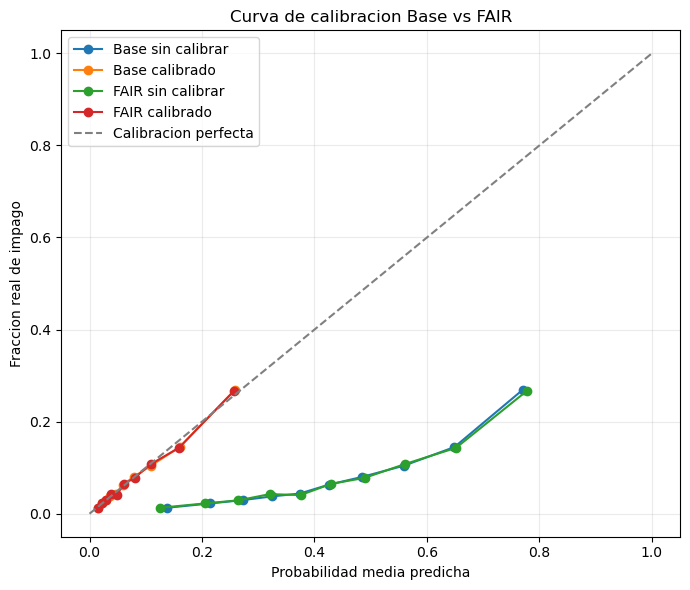

In [14]:
def fit_platt(y_val_true, val_proba):
    calibrator = LogisticRegression(solver="lbfgs")
    calibrator.fit(np.asarray(val_proba).reshape(-1, 1), np.asarray(y_val_true).astype(int))
    return calibrator

calibrator_base = fit_platt(y_val_np, y_val_proba_base)
calibrator_fair = fit_platt(y_val_np, y_val_proba_fair)

y_test_proba_base_calibrated = calibrator_base.predict_proba(y_test_proba_base.reshape(-1, 1))[:, 1]
y_test_proba_fair_calibrated = calibrator_fair.predict_proba(y_test_proba_fair.reshape(-1, 1))[:, 1]

calibration_results_base_vs_fair = pd.DataFrame([
    {
        "model": "Base NN Custom Layer original sin FAIR",
        "brier_uncalibrated_test": brier_score_loss(y_test_np, y_test_proba_base),
        "brier_calibrated_test": brier_score_loss(y_test_np, y_test_proba_base_calibrated),
        "mean_predicted_probability_uncalibrated": float(np.mean(y_test_proba_base)),
        "mean_predicted_probability_calibrated": float(np.mean(y_test_proba_base_calibrated)),
        "real_default_rate_test": float(np.mean(y_test_np)),
        "roc_auc_uncalibrated": _safe_roc_auc(y_test_np, y_test_proba_base),
        "roc_auc_calibrated": _safe_roc_auc(y_test_np, y_test_proba_base_calibrated),
    },
    {
        "model": "FAIR NN Custom Layer candidato original",
        "brier_uncalibrated_test": brier_score_loss(y_test_np, y_test_proba_fair),
        "brier_calibrated_test": brier_score_loss(y_test_np, y_test_proba_fair_calibrated),
        "mean_predicted_probability_uncalibrated": float(np.mean(y_test_proba_fair)),
        "mean_predicted_probability_calibrated": float(np.mean(y_test_proba_fair_calibrated)),
        "real_default_rate_test": float(np.mean(y_test_np)),
        "roc_auc_uncalibrated": _safe_roc_auc(y_test_np, y_test_proba_fair),
        "roc_auc_calibrated": _safe_roc_auc(y_test_np, y_test_proba_fair_calibrated),
    },
])
calibration_results_base_vs_fair.to_csv(TABLE_DIR / "calibration_results_base_vs_fair.csv", index=False)
display(calibration_results_base_vs_fair)

plt.figure(figsize=(7, 6))
for label, proba in [
    ("Base sin calibrar", y_test_proba_base),
    ("Base calibrado", y_test_proba_base_calibrated),
    ("FAIR sin calibrar", y_test_proba_fair),
    ("FAIR calibrado", y_test_proba_fair_calibrated),
]:
    frac_pos, mean_pred = calibration_curve(y_test_np, proba, n_bins=10, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=label)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibracion perfecta")
plt.xlabel("Probabilidad media predicha")
plt.ylabel("Fraccion real de impago")
plt.title("Curva de calibracion Base vs FAIR")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "calibration_curve_base_vs_fair.png", dpi=140, bbox_inches="tight")
plt.show()


## Bootstrap confidence intervals Base vs FAIR

Los intervalos bootstrap permiten comprobar si la caida de AUC y la reduccion de dependencia con genero son robustas frente a variacion muestral.


In [15]:
def demographic_gap_score_metric(y_true, proba, sensitive):
    sensitive = np.asarray(sensitive).astype(int)
    return abs(np.mean(proba[sensitive == 1]) - np.mean(proba[sensitive == 0]))

def compute_bootstrap_base_vs_fair(y_test, y_base, y_fair, s_test, n_boot=500):
    rows = []
    metric_specs = [
        ("roc_auc", "Base", lambda y, p, s: _safe_roc_auc(y, p), y_base),
        ("roc_auc", "FAIR", lambda y, p, s: _safe_roc_auc(y, p), y_fair),
        ("pr_auc", "Base", lambda y, p, s: _safe_pr_auc(y, p), y_base),
        ("pr_auc", "FAIR", lambda y, p, s: _safe_pr_auc(y, p), y_fair),
        ("corr_pred_gender", "Base", lambda y, p, s: _safe_corr(p, s), y_base),
        ("corr_pred_gender", "FAIR", lambda y, p, s: _safe_corr(p, s), y_fair),
        ("abs_corr_pred_gender", "Base", lambda y, p, s: abs(_safe_corr(p, s)), y_base),
        ("abs_corr_pred_gender", "FAIR", lambda y, p, s: abs(_safe_corr(p, s)), y_fair),
        ("demographic_parity_gap_score", "Base", lambda y, p, s: demographic_gap_score_metric(y, p, s), y_base),
        ("demographic_parity_gap_score", "FAIR", lambda y, p, s: demographic_gap_score_metric(y, p, s), y_fair),
    ]
    for metric, label, func, pred in metric_specs:
        mean, low, high, n_valid = bootstrap_metric_ci(
            y_test,
            pred,
            sensitive=s_test,
            metric_func=lambda y, p, sens, f=func: f(y, p, sens),
            n_boot=n_boot,
            seed=RANDOM_STATE,
        )
        rows.append({
            "metric": metric,
            "model_or_difference": label,
            "mean": mean,
            "ci_95_low": low,
            "ci_95_high": high,
            "n_boot_valid": n_valid,
        })

    diff_specs = [
        ("delta_roc_auc_fair_minus_base", lambda y, a, b, s: _safe_roc_auc(y, b) - _safe_roc_auc(y, a)),
        ("delta_pr_auc_fair_minus_base", lambda y, a, b, s: _safe_pr_auc(y, b) - _safe_pr_auc(y, a)),
        ("delta_abs_corr_fair_minus_base", lambda y, a, b, s: abs(_safe_corr(b, s)) - abs(_safe_corr(a, s))),
        ("delta_demographic_gap_fair_minus_base", lambda y, a, b, s: demographic_gap_score_metric(y, b, s) - demographic_gap_score_metric(y, a, s)),
    ]
    for metric, func in diff_specs:
        mean, low, high, n_valid = bootstrap_metric_ci(
            y_test,
            y_base,
            y_pred_b=y_fair,
            sensitive=s_test,
            metric_func=func,
            n_boot=n_boot,
            seed=RANDOM_STATE,
        )
        rows.append({
            "metric": metric,
            "model_or_difference": "FAIR - Base",
            "mean": mean,
            "ci_95_low": low,
            "ci_95_high": high,
            "n_boot_valid": n_valid,
        })
    return pd.DataFrame(rows)

bootstrap_ci_base_vs_fair = compute_bootstrap_base_vs_fair(
    y_test_np,
    y_test_proba_base,
    y_test_proba_fair,
    s_test_np,
    n_boot=N_BOOTSTRAP,
)
bootstrap_ci_base_vs_fair.to_csv(TABLE_DIR / "bootstrap_ci_base_vs_fair.csv", index=False)
display(bootstrap_ci_base_vs_fair)


,metric,model_or_difference,mean,ci_95_low,ci_95_high,n_boot_valid
0,roc_auc,Base,0.7530,0.7446,0.7610,500
1,roc_auc,FAIR,0.7513,0.7430,0.7597,500
2,pr_auc,Base,0.2406,0.2279,0.2552,500
3,pr_auc,FAIR,0.2398,0.2270,0.2537,500
4,corr_pred_gender,Base,0.1408,0.1317,0.1494,500
5,corr_pred_gender,FAIR,0.0375,0.0284,0.0463,500
6,abs_corr_pred_gender,Base,0.1408,0.1317,0.1494,500
7,abs_corr_pred_gender,FAIR,0.0375,0.0284,0.0463,500
8,demographic_parity_gap_score,Base,0.0563,0.0526,0.0597,500
9,demographic_parity_gap_score,FAIR,0.0155,0.0117,0.0191,500


## Tabla Base vs FAIR con intervalos y calibracion


In [16]:
def lookup_ci(metric, label):
    row = bootstrap_ci_base_vs_fair[
        (bootstrap_ci_base_vs_fair["metric"] == metric)
        & (bootstrap_ci_base_vs_fair["model_or_difference"] == label)
    ]
    return ci_text(row.iloc[0]) if not row.empty else np.nan

def row_base_fair(metrics, lambda_corr, label, brier_calibrated):
    return {
        "model": metrics["model"],
        "lambda_corr": lambda_corr,
        "threshold_strategy": metrics["threshold_strategy"],
        "threshold_usado": metrics["threshold"],
        "accuracy_test": metrics["accuracy"],
        "balanced_accuracy_test": metrics["balanced_accuracy"],
        "roc_auc_test": metrics["roc_auc"],
        "roc_auc_ci95": lookup_ci("roc_auc", label),
        "pr_auc_test": metrics["pr_auc"],
        "pr_auc_ci95": lookup_ci("pr_auc", label),
        "brier_uncalibrated_test": metrics["brier_score"],
        "brier_calibrated_test": brier_calibrated,
        "precision_test": metrics["precision"],
        "recall_test": metrics["recall"],
        "f1_test": metrics["f1"],
        "corr_pred_gender_test": metrics["corr_pred_gender"],
        "corr_pred_gender_ci95": lookup_ci("corr_pred_gender", label),
        "abs_corr_pred_gender_test": abs(metrics["corr_pred_gender"]),
        "demographic_parity_gap_score_test": metrics["demographic_parity_gap_score"],
        "equal_opportunity_gap_test": metrics["equal_opportunity_gap"],
        "fpr_gap_test": metrics["fpr_gap"],
        "tn": metrics["tn"],
        "fp": metrics["fp"],
        "fn": metrics["fn"],
        "tp": metrics["tp"],
    }

tabla_base_vs_fair_test = pd.DataFrame([
    row_base_fair(base_test_metrics, 0.0, "Base", brier_score_loss(y_test_np, y_test_proba_base_calibrated)),
    row_base_fair(best_fair_test_metrics, best_lambda_fair, "FAIR", brier_score_loss(y_test_np, y_test_proba_fair_calibrated)),
])
tabla_base_vs_fair_test.to_csv(TABLE_DIR / "tabla_base_vs_fair_test.csv", index=False)
display(tabla_base_vs_fair_test)

diff_rows = []
for metric, base_col, fair_col in [
    ("roc_auc", "roc_auc_test", "roc_auc_test"),
    ("pr_auc", "pr_auc_test", "pr_auc_test"),
    ("brier_uncalibrated", "brier_uncalibrated_test", "brier_uncalibrated_test"),
    ("brier_calibrated", "brier_calibrated_test", "brier_calibrated_test"),
    ("abs_corr_pred_gender", "abs_corr_pred_gender_test", "abs_corr_pred_gender_test"),
    ("demographic_parity_gap_score", "demographic_parity_gap_score_test", "demographic_parity_gap_score_test"),
    ("equal_opportunity_gap", "equal_opportunity_gap_test", "equal_opportunity_gap_test"),
    ("fpr_gap", "fpr_gap_test", "fpr_gap_test"),
    ("recall", "recall_test", "recall_test"),
    ("precision", "precision_test", "precision_test"),
    ("f1", "f1_test", "f1_test"),
]:
    base_val = tabla_base_vs_fair_test.loc[0, base_col]
    fair_val = tabla_base_vs_fair_test.loc[1, fair_col]
    diff = fair_val - base_val
    if metric in ["roc_auc", "pr_auc", "recall", "precision", "f1"]:
        interp = "Mejora si positivo; coste predictivo si negativo."
    elif metric.startswith("brier"):
        interp = "Mejora si negativo, porque Brier menor indica mejor calibracion."
    else:
        interp = "Mejora fairness si negativo, porque reduce dependencia/brecha."
    diff_rows.append({
        "metric": metric,
        "base_value": base_val,
        "fair_value": fair_val,
        "difference_fair_minus_base": diff,
        "interpretation": interp,
    })

tabla_base_vs_fair_differences = pd.DataFrame(diff_rows)
tabla_base_vs_fair_differences.to_csv(TABLE_DIR / "tabla_base_vs_fair_differences.csv", index=False)
display(tabla_base_vs_fair_differences)

delta_auc_row = bootstrap_ci_base_vs_fair[bootstrap_ci_base_vs_fair["metric"] == "delta_roc_auc_fair_minus_base"].iloc[0]
display(Markdown(
    f"El modelo FAIR reduce la dependencia con genero desde {tabla_base_vs_fair_test.loc[0, 'abs_corr_pred_gender_test']:.4f} "
    f"hasta {tabla_base_vs_fair_test.loc[1, 'abs_corr_pred_gender_test']:.4f}. "
    f"El coste en ROC-AUC es {tabla_base_vs_fair_test.loc[1, 'roc_auc_test'] - tabla_base_vs_fair_test.loc[0, 'roc_auc_test']:.4f}. "
    f"Con bootstrap, el intervalo de confianza de la diferencia de AUC es {ci_text(delta_auc_row)}."
))


,model,lambda_corr,threshold_strategy,threshold_usado,accuracy_test,balanced_accuracy_test,roc_auc_test,roc_auc_ci95,pr_auc_test,pr_auc_ci95,brier_uncalibrated_test,brier_calibrated_test,precision_test,recall_test,f1_test,corr_pred_gender_test,corr_pred_gender_ci95,abs_corr_pred_gender_test,demographic_parity_gap_score_test,equal_opportunity_gap_test,fpr_gap_test,tn,fp,fn,tp
0,Base NN Custom Layer original sin FAIR,0.0000,best_f1_validation,0.6500,0.8404,0.6521,0.7529,"[0.7446, 0.7610]",0.2402,"[0.2279, 0.2552]",0.1995,0.0682,0.2334,0.4275,0.3019,0.1408,"[0.1317, 0.1494]",0.1408,0.0563,0.1096,0.0686,37173,5230,2132,1592
1,FAIR NN Custom Layer candidato original,1.0000,best_f1_validation,0.6600,0.8451,0.6475,0.7513,"[0.7430, 0.7597]",0.2397,"[0.2270, 0.2537]",0.2003,0.0683,0.2364,0.4119,0.3004,0.0375,"[0.0284, 0.0463]",0.0375,0.0154,0.0408,0.0334,37448,4955,2190,1534


,metric,base_value,fair_value,difference_fair_minus_base,interpretation
0,roc_auc,0.7529,0.7513,-0.0016,Mejora si positivo; coste predictivo si negativo.
1,pr_auc,0.2402,0.2397,-0.0006,Mejora si positivo; coste predictivo si negativo.
2,brier_uncalibrated,0.1995,0.2003,0.0008,"Mejora si negativo, porque Brier menor indica ..."
3,brier_calibrated,0.0682,0.0683,0.0001,"Mejora si negativo, porque Brier menor indica ..."
4,abs_corr_pred_gender,0.1408,0.0375,-0.1034,"Mejora fairness si negativo, porque reduce dep..."
5,demographic_parity_gap_score,0.0563,0.0154,-0.0408,"Mejora fairness si negativo, porque reduce dep..."
6,equal_opportunity_gap,0.1096,0.0408,-0.0688,"Mejora fairness si negativo, porque reduce dep..."
7,fpr_gap,0.0686,0.0334,-0.0352,"Mejora fairness si negativo, porque reduce dep..."
8,recall,0.4275,0.4119,-0.0156,Mejora si positivo; coste predictivo si negativo.
9,precision,0.2334,0.2364,0.0030,Mejora si positivo; coste predictivo si negativo.


El modelo FAIR reduce la dependencia con genero desde 0.1408 hasta 0.0375. El coste en ROC-AUC es -0.0016. Con bootstrap, el intervalo de confianza de la diferencia de AUC es [-0.0035, 0.0002].

## Ablation study: impacto de la capa custom financiera

Se comparan tres redes sin FAIR:

A. NN sin capa custom y sin ratios engineered.  
B. NN con ratios engineered como features, pero sin capa custom raw.  
C. NN con `DebtRatioSaturationLayer`.

Si la capa custom no mejora AUC, su valor sigue siendo interpretabilidad y restriccion financiera.



Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 8.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 9.


,model,uses_engineered_ratios,uses_raw_custom_layer,roc_auc_test,pr_auc_test,brier_score_test,precision_test,recall_test,f1_test,corr_pred_gender_test
0,A: NN sin ratios engineered ni capa custom,False,False,0.7483,0.2288,0.1967,0.2140,0.4793,0.2959,0.1405
1,B: NN con ratios engineered sin capa custom,True,False,0.7516,0.2376,0.2000,0.2289,0.4433,0.3019,0.1371
2,C: NN con DebtRatioSaturationLayer,True,True,0.7529,0.2402,0.1995,0.2334,0.4275,0.3019,0.1408


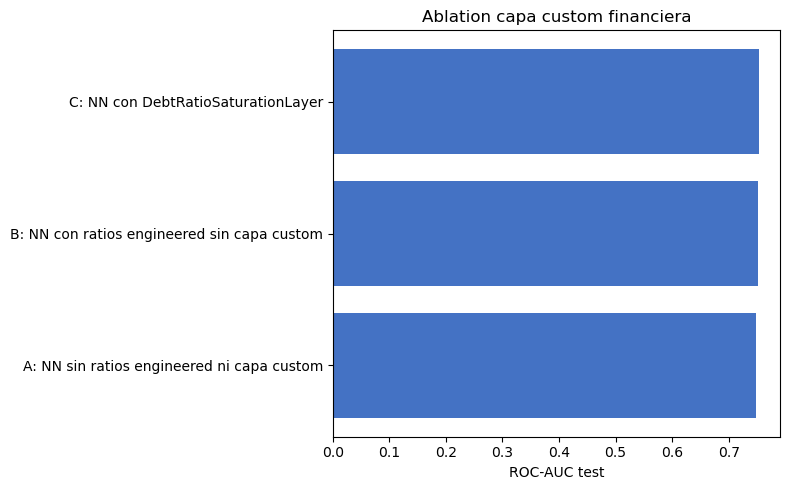

In [17]:
ablation_rows = []

def train_eval_ablation(model_name, model, train_inputs, val_inputs, test_inputs, uses_engineered_ratios, uses_raw_custom_layer):
    reset_seeds(42)
    history = model.fit(
        train_inputs,
        y_train_np,
        validation_data=(val_inputs, y_val_np),
        epochs=ABLATION_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=make_callbacks(monitor="val_auc", mode="max", patience=5),
        verbose=0,
    )
    val_proba = model.predict(val_inputs, batch_size=BATCH_SIZE, verbose=0).ravel()
    test_proba = model.predict(test_inputs, batch_size=BATCH_SIZE, verbose=0).ravel()
    threshold, _ = find_best_threshold(y_val_np, val_proba, metric="f1")
    metrics = evaluate_model(model_name, y_test_np, test_proba, s_test_np, threshold, "best_f1_validation")
    return {
        "model": model_name,
        "uses_engineered_ratios": uses_engineered_ratios,
        "uses_raw_custom_layer": uses_raw_custom_layer,
        "roc_auc_test": metrics["roc_auc"],
        "pr_auc_test": metrics["pr_auc"],
        "brier_score_test": metrics["brier_score"],
        "precision_test": metrics["precision"],
        "recall_test": metrics["recall"],
        "f1_test": metrics["f1"],
        "corr_pred_gender_test": metrics["corr_pred_gender"],
    }

model_a = build_dense_model(input_dim_no_ratios, use_batch_norm=False, use_layer_norm=True, model_name="A_no_ratios_no_custom")
ablation_rows.append(train_eval_ablation(
    "A: NN sin ratios engineered ni capa custom",
    model_a,
    X_train_no_ratios_keras,
    X_val_no_ratios_keras,
    X_test_no_ratios_keras,
    False,
    False,
))

model_b = build_dense_model(input_dim, use_batch_norm=False, use_layer_norm=True, model_name="B_ratios_no_custom")
ablation_rows.append(train_eval_ablation(
    "B: NN con ratios engineered sin capa custom",
    model_b,
    X_train_keras,
    X_val_keras,
    X_test_keras,
    True,
    False,
))

ablation_rows.append({
    "model": "C: NN con DebtRatioSaturationLayer",
    "uses_engineered_ratios": True,
    "uses_raw_custom_layer": True,
    "roc_auc_test": base_test_metrics["roc_auc"],
    "pr_auc_test": base_test_metrics["pr_auc"],
    "brier_score_test": base_test_metrics["brier_score"],
    "precision_test": base_test_metrics["precision"],
    "recall_test": base_test_metrics["recall"],
    "f1_test": base_test_metrics["f1"],
    "corr_pred_gender_test": base_test_metrics["corr_pred_gender"],
})

custom_layer_ablation_results = pd.DataFrame(ablation_rows)
custom_layer_ablation_results.to_csv(TABLE_DIR / "custom_layer_ablation_results.csv", index=False)
display(custom_layer_ablation_results)

plt.figure(figsize=(8, 5))
plt.barh(custom_layer_ablation_results["model"], custom_layer_ablation_results["roc_auc_test"], color="#4472C4")
plt.xlabel("ROC-AUC test")
plt.title("Ablation capa custom financiera")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "custom_layer_ablation_roc_auc.png", dpi=140, bbox_inches="tight")
plt.show()


## Auditoria de la restriccion matematica tanh

La saturacion `tanh` limita la influencia de outliers. Si demasiadas observaciones quedan cerca de 1, la transformacion puede estar perdiendo granularidad en perfiles extremos.


,ratio_name,raw_mean,raw_median,raw_p95,raw_p99,raw_max,saturated_mean,saturated_median,saturated_p95,saturated_p99,saturated_max,pct_saturated_above_0_95,pct_saturated_above_0_99
0,ANNUITY_INCOME_RAW,0.1808,0.1626,0.3549,0.4845,1.5706,0.1770,0.1612,0.3407,0.4498,0.9171,0.0000,0.0000
1,CREDIT_INCOME_RAW,3.9520,3.2531,9.1229,13.0136,49.2272,0.9582,0.9970,1.0000,1.0000,1.0000,0.7976,0.6230
2,ANNUITY_CREDIT_RAW,0.0537,0.0500,0.1050,0.1143,0.1581,0.0536,0.0500,0.1046,0.1138,0.1568,0.0000,0.0000
3,GOODS_CREDIT_RAW,0.9018,0.8938,1.0000,1.0000,6.6667,0.7138,0.7133,0.7616,0.7616,1.0000,0.0008,0.0002


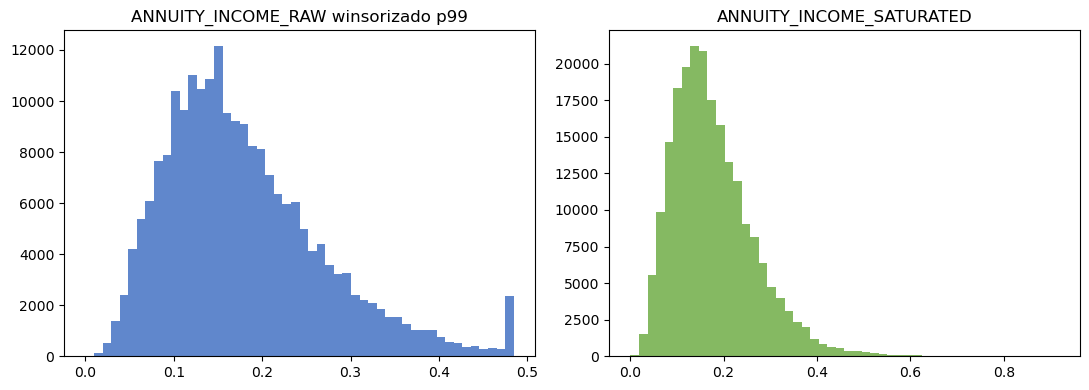

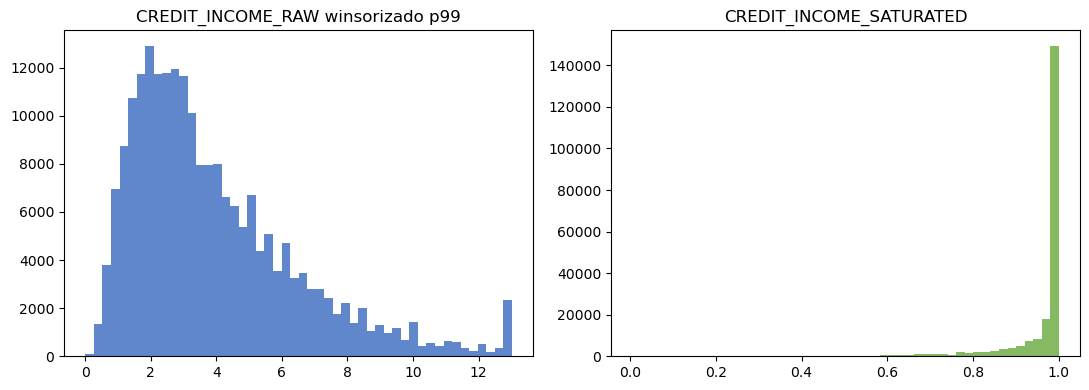

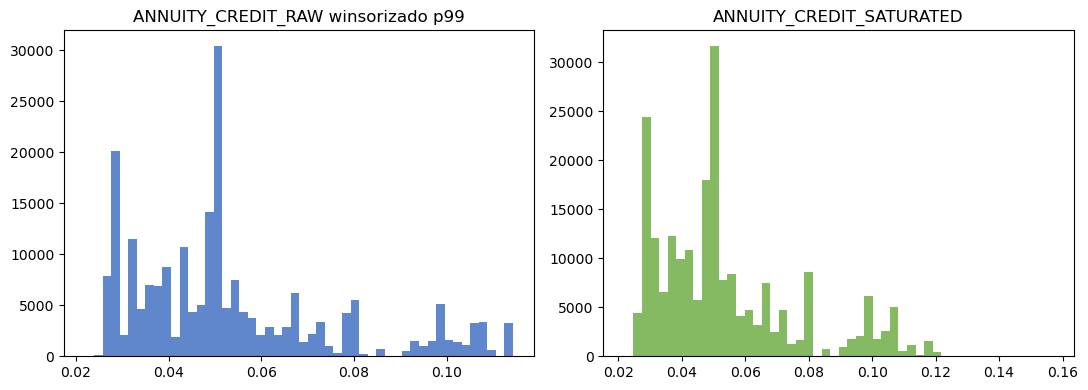

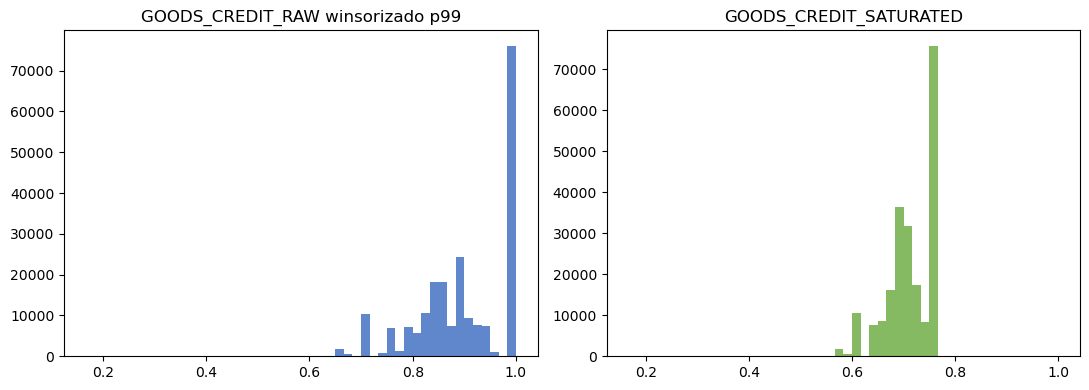

In [18]:
def compute_raw_ratios(raw_matrix, alpha=1.0, eps=1e-6):
    income = raw_matrix[:, 0]
    annuity = raw_matrix[:, 1]
    credit = raw_matrix[:, 2]
    goods = raw_matrix[:, 3]
    ratios = pd.DataFrame({
        "ANNUITY_INCOME_RAW": annuity / (income + eps),
        "CREDIT_INCOME_RAW": credit / (income + eps),
        "ANNUITY_CREDIT_RAW": annuity / (credit + eps),
        "GOODS_CREDIT_RAW": goods / (credit + eps),
    })
    saturated = np.tanh(alpha * ratios)
    saturated.columns = [c.replace("_RAW", "_SATURATED") for c in ratios.columns]
    return ratios, saturated

raw_ratios_train, saturated_ratios_train = compute_raw_ratios(X_train_fin_raw, alpha=1.0)

ratio_rows = []
for raw_col, sat_col in zip(raw_ratios_train.columns, saturated_ratios_train.columns):
    raw = raw_ratios_train[raw_col].replace([np.inf, -np.inf], np.nan).dropna()
    sat = saturated_ratios_train[sat_col].replace([np.inf, -np.inf], np.nan).dropna()
    ratio_rows.append({
        "ratio_name": raw_col,
        "raw_mean": raw.mean(),
        "raw_median": raw.median(),
        "raw_p95": raw.quantile(0.95),
        "raw_p99": raw.quantile(0.99),
        "raw_max": raw.max(),
        "saturated_mean": sat.mean(),
        "saturated_median": sat.median(),
        "saturated_p95": sat.quantile(0.95),
        "saturated_p99": sat.quantile(0.99),
        "saturated_max": sat.max(),
        "pct_saturated_above_0_95": float((sat > 0.95).mean()),
        "pct_saturated_above_0_99": float((sat > 0.99).mean()),
    })

ratio_saturation_summary = pd.DataFrame(ratio_rows)
ratio_saturation_summary.to_csv(TABLE_DIR / "ratio_saturation_summary.csv", index=False)
display(ratio_saturation_summary)

plot_names = {
    "ANNUITY_INCOME_RAW": "ratio_saturation_annuity_income.png",
    "CREDIT_INCOME_RAW": "ratio_saturation_credit_income.png",
    "ANNUITY_CREDIT_RAW": "ratio_saturation_annuity_credit.png",
    "GOODS_CREDIT_RAW": "ratio_saturation_goods_credit.png",
}
for raw_col, filename in plot_names.items():
    sat_col = raw_col.replace("_RAW", "_SATURATED")
    raw = raw_ratios_train[raw_col].replace([np.inf, -np.inf], np.nan).dropna()
    sat = saturated_ratios_train[sat_col].replace([np.inf, -np.inf], np.nan).dropna()
    raw_wins = raw.clip(upper=raw.quantile(0.99))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(raw_wins, bins=50, color="#4472C4", alpha=0.85)
    axes[0].set_title(f"{raw_col} winsorizado p99")
    axes[1].hist(sat, bins=50, color="#70AD47", alpha=0.85)
    axes[1].set_title(f"{sat_col}")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=140, bbox_inches="tight")
    plt.show()


## AutoML y fairness: dos estrategias

**Estrategia A:** Keras Tuner busca la mejor arquitectura predictiva segun `val_auc`.

**Estrategia B:** Con la mejor arquitectura encontrada, se realiza un sweep de `lambda_corr` para construir la curva de Pareto fairness-performance.

Keras Tuner no optimiza directamente una metrica fairness externa como objetivo principal. Por eso se audita fairness en validation para los mejores trials y se guarda una tabla aparte.


Trial 15 Complete [00h 00m 28s]
val_auc: 0.7462947964668274

Best val_auc So Far: 0.7499524354934692
Total elapsed time: 00h 05m 13s


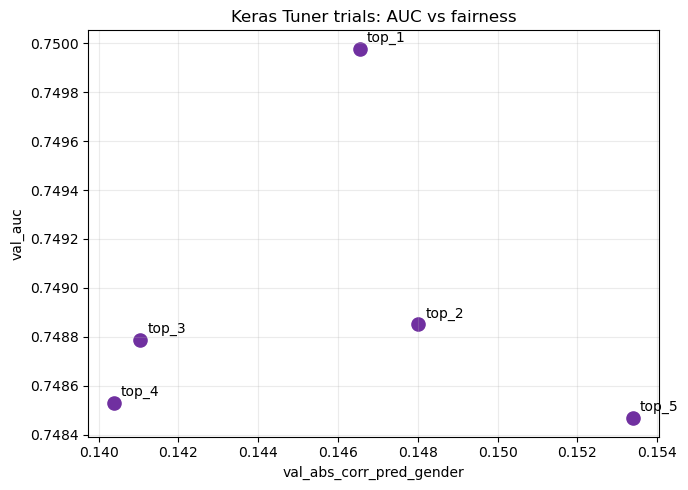

Epoch 1/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.6864 - loss: 0.6675 - pr_auc: 0.1544 - val_auc: 0.7397 - val_loss: 0.5862 - val_pr_auc: 0.2108 - learning_rate: 5.0000e-04
Epoch 2/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.7212 - loss: 0.6189 - pr_auc: 0.1878 - val_auc: 0.7444 - val_loss: 0.5869 - val_pr_auc: 0.2198 - learning_rate: 5.0000e-04
Epoch 3/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.7307 - loss: 0.6091 - pr_auc: 0.1993 - val_auc: 0.7462 - val_loss: 0.5884 - val_pr_auc: 0.2234 - learning_rate: 5.0000e-04
Epoch 4/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.7355 - loss: 0.6048 - pr_auc: 0.2057 - val_auc: 0.7471 - val_loss: 0.5830 - val_pr_auc: 0.2254 - learning_rate: 5.0000e-04
Epoch 5/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.7393 - loss: 0.6011 - pr_auc: 0.2115 - val_auc: 0.7479 - val_loss: 0.5832 - val_pr_auc: 0.2271 - learning_rate: 5.0000e-04
Epoch 6/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.7429 - loss: 0.5980

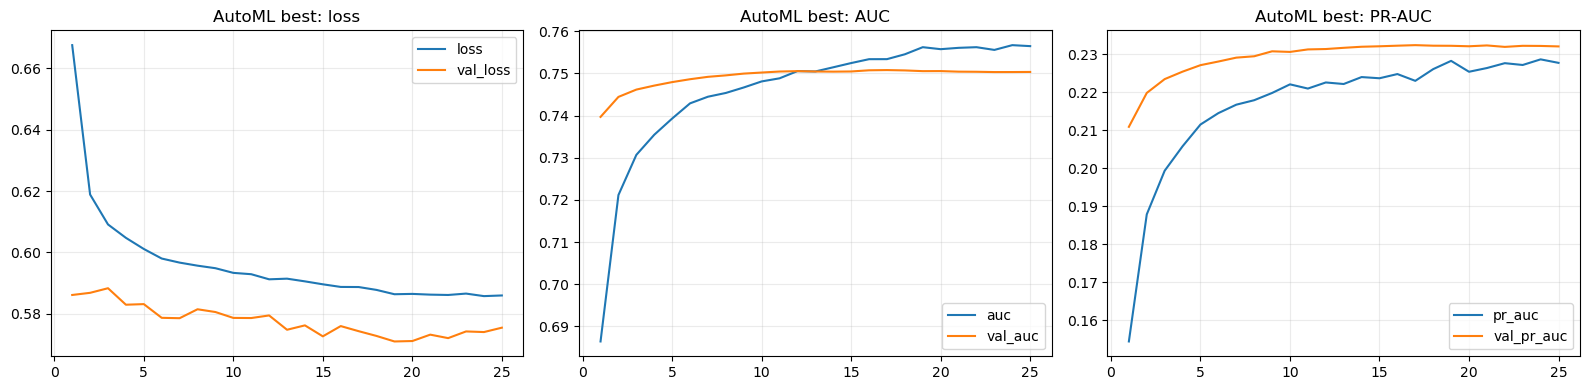

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 32: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 35: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 37: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 39: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.

Epoch 41: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.

Epoch 43: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.
Epoch 44: early stopping
Restoring model weights from the end of the best epoch: 39.

Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 32: ReduceLROnPlateau reducing learning rate to 

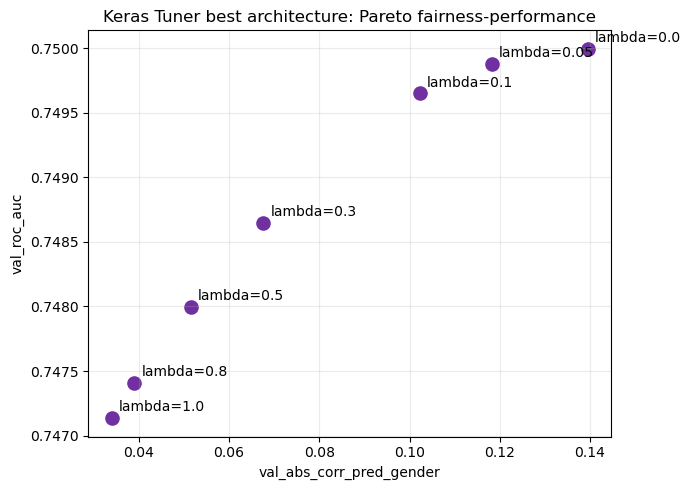

In [19]:
def hp_get(hp, name, default=np.nan):
    try:
        return hp.get(name)
    except Exception:
        return default

def build_tuned_model(hp, fair_lambda=None, model_name="tuned_model"):
    num_layers = hp.Int("num_layers", min_value=1, max_value=4, step=1)
    learning_rate = hp.Choice("learning_rate", values=[1e-2, 1e-3, 5e-4, 1e-4])
    dense_units = []
    dropout_rates = []
    for i in range(num_layers):
        dense_units.append(hp.Int(f"units_{i}", min_value=16, max_value=128, step=16))
        dropout_rates.append(hp.Float(f"dropout_{i}", min_value=0.0, max_value=0.5, step=0.1))
    return build_custom_layer_model(
        processed_dim=input_dim,
        dense_units=tuple(dense_units),
        dropout_rates=tuple(dropout_rates),
        learning_rate=learning_rate,
        use_batch_norm=False,
        use_layer_norm=True,
        fair_lambda=fair_lambda,
        model_name=model_name,
    )

keras_tuner_trials_with_fairness = pd.DataFrame()
tuner_pareto_results_df = pd.DataFrame()

if kt is not None:
    project_name = "home_credit_aml_v2_critica"
    project_dir = TUNER_DIR / project_name
    if project_dir.exists():
        shutil.rmtree(project_dir)

    tuner = kt.RandomSearch(
        lambda hp: build_tuned_model(hp, fair_lambda=None, model_name="KerasTuner_NoFair"),
        objective=kt.Objective("val_auc", direction="max"),
        max_trials=TUNER_MAX_TRIALS,
        overwrite=True,
        directory=str(TUNER_DIR.resolve()),
        project_name=project_name,
        seed=RANDOM_STATE,
    )

    tuner.search(
        [X_train_keras, X_train_fin_raw],
        y_train_np,
        validation_data=([X_val_keras, X_val_fin_raw], y_val_np),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True)],
        verbose=1,
    )

    top_n = min(5, TUNER_MAX_TRIALS)
    best_hps_list = tuner.get_best_hyperparameters(num_trials=top_n)
    best_models = tuner.get_best_models(num_models=top_n)
    trial_rows = []
    for i, (hp, model) in enumerate(zip(best_hps_list, best_models), start=1):
        val_proba = model.predict([X_val_keras, X_val_fin_raw], batch_size=BATCH_SIZE, verbose=0).ravel()
        threshold, _ = find_best_threshold(y_val_np, val_proba, metric="f1")
        val_eval = evaluate_model(f"keras_tuner_top_{i}", y_val_np, val_proba, s_val_np, threshold, "best_f1_validation")
        num_layers = hp_get(hp, "num_layers")
        units = [hp_get(hp, f"units_{j}") for j in range(int(num_layers))]
        dropout = [hp_get(hp, f"dropout_{j}") for j in range(int(num_layers))]
        trial_rows.append({
            "trial_id": f"top_{i}",
            "lambda_corr": 0.0,
            "num_layers": num_layers,
            "units": json.dumps(units),
            "dropout": json.dumps(dropout),
            "learning_rate": hp_get(hp, "learning_rate"),
            "use_layer_norm": True,
            "val_auc": val_eval["roc_auc"],
            "val_pr_auc": val_eval["pr_auc"],
            "val_corr_pred_gender": val_eval["corr_pred_gender"],
            "val_abs_corr_pred_gender": abs(val_eval["corr_pred_gender"]),
            "val_demographic_parity_gap_score": val_eval["demographic_parity_gap_score"],
            "val_equal_opportunity_gap": val_eval["equal_opportunity_gap"],
        })

    keras_tuner_trials_with_fairness = pd.DataFrame(trial_rows)
    keras_tuner_trials_with_fairness.to_csv(TABLE_DIR / "keras_tuner_trials_with_fairness.csv", index=False)

    plt.figure(figsize=(7, 5))
    plt.scatter(keras_tuner_trials_with_fairness["val_abs_corr_pred_gender"], keras_tuner_trials_with_fairness["val_auc"], s=90, c="#7030A0")
    for _, row in keras_tuner_trials_with_fairness.iterrows():
        plt.annotate(row["trial_id"], (row["val_abs_corr_pred_gender"], row["val_auc"]), textcoords="offset points", xytext=(5, 5))
    plt.xlabel("val_abs_corr_pred_gender")
    plt.ylabel("val_auc")
    plt.title("Keras Tuner trials: AUC vs fairness")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "keras_tuner_trials_auc_vs_fairness.png", dpi=140, bbox_inches="tight")
    plt.show()

    best_hp = best_hps_list[0]
    automl_model = build_tuned_model(best_hp, fair_lambda=None, model_name="AutoML_Best_NoFair")
    history_automl_best = automl_model.fit(
        [X_train_keras, X_train_fin_raw],
        y_train_np,
        validation_data=([X_val_keras, X_val_fin_raw], y_val_np),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=make_callbacks(monitor="val_auc", mode="max", patience=8),
        verbose=1,
    )
    plot_training_history(history_automl_best, "AutoML best", "loss_curve_automl_best.png")
    automl_val_proba = automl_model.predict([X_val_keras, X_val_fin_raw], batch_size=BATCH_SIZE).ravel()
    automl_test_proba = automl_model.predict([X_test_keras, X_test_fin_raw], batch_size=BATCH_SIZE).ravel()
    automl_threshold, _ = find_best_threshold(y_val_np, automl_val_proba, metric="f1")
    automl_metrics = evaluate_model("AutoML Keras Tuner", y_test_np, automl_test_proba, s_test_np, automl_threshold, "best_f1_validation")
    automl_metrics["evaluation_scope"] = "full_test"
    results_full_test.append(automl_metrics)

    tuner_pareto_rows = []
    for lambda_corr in lambdas:
        reset_seeds(42)
        tf.keras.backend.clear_session()
        model = build_tuned_model(best_hp, fair_lambda=lambda_corr, model_name=f"AutoML_best_arch_lambda_{lambda_corr}")
        model.fit(
            [X_train_keras, X_train_fin_raw],
            y_train_ext,
            validation_data=([X_val_keras, X_val_fin_raw], y_val_ext, sample_weight_val),
            sample_weight=sample_weight_train,
            epochs=FAIRNESS_EPOCHS,
            batch_size=FAIR_BATCH_SIZE,
            callbacks=make_callbacks(monitor="val_loss", mode="min", patience=5),
            verbose=0,
        )
        val_proba = model.predict([X_val_keras, X_val_fin_raw], batch_size=BATCH_SIZE, verbose=0).ravel()
        test_proba = model.predict([X_test_keras, X_test_fin_raw], batch_size=BATCH_SIZE, verbose=0).ravel()
        threshold, _ = find_best_threshold(y_val_np, val_proba, metric="f1")
        val_eval = evaluate_model(f"AutoML FAIR lambda={lambda_corr}", y_val_np, val_proba, s_val_np, threshold, "best_f1_validation")
        test_eval = evaluate_model(f"AutoML FAIR lambda={lambda_corr}", y_test_np, test_proba, s_test_np, threshold, "best_f1_validation")
        tuner_pareto_rows.append({
            "trial_id": f"best_arch_lambda_{lambda_corr}",
            "lambda_corr": lambda_corr,
            "num_layers": hp_get(best_hp, "num_layers"),
            "learning_rate": hp_get(best_hp, "learning_rate"),
            "val_roc_auc": val_eval["roc_auc"],
            "val_pr_auc": val_eval["pr_auc"],
            "val_corr_pred_gender": val_eval["corr_pred_gender"],
            "val_abs_corr_pred_gender": abs(val_eval["corr_pred_gender"]),
            "val_demographic_parity_gap_score": val_eval["demographic_parity_gap_score"],
            "test_roc_auc": test_eval["roc_auc"],
            "test_pr_auc": test_eval["pr_auc"],
            "test_corr_pred_gender": test_eval["corr_pred_gender"],
        })
    tuner_pareto_results_df = pd.DataFrame(tuner_pareto_rows)
    tuner_pareto_results_df.to_csv(TABLE_DIR / "tuner_pareto_results.csv", index=False)

    plt.figure(figsize=(7, 5))
    plt.scatter(tuner_pareto_results_df["val_abs_corr_pred_gender"], tuner_pareto_results_df["val_roc_auc"], s=90, color="#7030A0")
    for _, row in tuner_pareto_results_df.iterrows():
        plt.annotate(f"lambda={row['lambda_corr']}", (row["val_abs_corr_pred_gender"], row["val_roc_auc"]), textcoords="offset points", xytext=(5, 5))
    plt.xlabel("val_abs_corr_pred_gender")
    plt.ylabel("val_roc_auc")
    plt.title("Keras Tuner best architecture: Pareto fairness-performance")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "keras_tuner_pareto_precision_vs_fair_dependency.png", dpi=140, bbox_inches="tight")
    plt.show()
else:
    keras_tuner_trials_with_fairness.to_csv(TABLE_DIR / "keras_tuner_trials_with_fairness.csv", index=False)
    tuner_pareto_results_df.to_csv(TABLE_DIR / "tuner_pareto_results.csv", index=False)
    for filename, title in [
        ("keras_tuner_trials_auc_vs_fairness.png", "Keras Tuner no disponible"),
        ("keras_tuner_pareto_precision_vs_fair_dependency.png", "Keras Tuner no disponible"),
        ("loss_curve_automl_best.png", "Keras Tuner no disponible"),
    ]:
        plt.figure(figsize=(6, 4))
        plt.text(0.5, 0.5, title, ha="center", va="center")
        plt.axis("off")
        plt.savefig(FIGURE_DIR / filename, dpi=140, bbox_inches="tight")
        plt.show()


## MC Dropout e incertidumbre sin BatchNormalization

El umbral de alta incertidumbre se fija en validation y despues se aplica sin reajustar al conjunto de test.


In [20]:
def mc_dropout_predict(model, inputs, n_samples=100):
    preds = []
    for _ in range(n_samples):
        pred = model(inputs, training=True).numpy().ravel()
        preds.append(pred)
    preds = np.asarray(preds)
    return preds.mean(axis=0), preds.var(axis=0), preds.std(axis=0)

best_fair_model_for_uncertainty = best_fair_model
assert_no_batchnorm(best_fair_model_for_uncertainty)

val_mean_proba_mc, val_pred_variance, val_pred_std = mc_dropout_predict(
    best_fair_model_for_uncertainty,
    [X_val_keras, X_val_fin_raw],
    n_samples=N_MC_SAMPLES,
)
uncertainty_threshold_p90 = float(np.percentile(val_pred_variance, 90))

uncertainty_threshold_validation = pd.DataFrame([{
    "threshold_name": "p90_validation_variance",
    "value": uncertainty_threshold_p90,
    "source_split": "validation",
    "n_mc_samples": N_MC_SAMPLES,
}])
uncertainty_threshold_validation.to_csv(TABLE_DIR / "uncertainty_threshold_validation.csv", index=False)
display(uncertainty_threshold_validation)

test_mean_proba_mc, test_pred_variance, test_pred_std = mc_dropout_predict(
    best_fair_model_for_uncertainty,
    [X_test_keras, X_test_fin_raw],
    n_samples=N_MC_SAMPLES,
)

test_pred_class = (test_mean_proba_mc >= best_threshold_fair).astype(int)
test_high_uncertainty = test_pred_variance >= uncertainty_threshold_p90
uncertainty_percentile = pd.Series(test_pred_variance).rank(pct=True).to_numpy() * 100

test_predictions_with_uncertainty = pd.DataFrame({
    "SK_ID_CURR": ids_test.to_numpy(),
    "y_true": y_test_np.astype(int),
    "predicted_probability_mean": test_mean_proba_mc,
    "predicted_class": test_pred_class,
    "predicted_label": np.where(test_pred_class == 1, "Mal pagador", "Buen pagador"),
    "prediction_variance": test_pred_variance,
    "prediction_std": test_pred_std,
    "uncertainty_percentile": uncertainty_percentile,
    "high_uncertainty": test_high_uncertainty,
    "CODE_GENDER_encoded": s_test_np.astype(int),
    "EXT_SOURCE_1": X_test_raw["EXT_SOURCE_1"].to_numpy(),
    "EXT_SOURCE_2": X_test_raw["EXT_SOURCE_2"].to_numpy(),
    "EXT_SOURCE_3": X_test_raw["EXT_SOURCE_3"].to_numpy(),
    "EXT_SOURCE_MISSING_COUNT": X_test_raw["EXT_SOURCE_MISSING_COUNT"].to_numpy(),
})
test_predictions_with_uncertainty.to_csv(TABLE_DIR / "test_predictions_with_uncertainty.csv", index=False)
display(test_predictions_with_uncertainty.head(20))


,threshold_name,value,source_split,n_mc_samples
0,p90_validation_variance,0.0034,validation,100


,SK_ID_CURR,y_true,predicted_probability_mean,predicted_class,predicted_label,prediction_variance,prediction_std,uncertainty_percentile,high_uncertainty,CODE_GENDER_encoded,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,EXT_SOURCE_MISSING_COUNT
0,167425,0,0.4492,0,Buen pagador,0.0026,0.0514,74.8976,False,1,0.5024,0.4097,0.7981,0
1,427850,1,0.3235,0,Buen pagador,0.0024,0.0487,64.4850,False,0,0.4169,0.7211,0.5691,0
2,120090,0,0.2329,0,Buen pagador,0.0017,0.0416,27.9923,False,0,0.6266,0.5907,0.6848,0
3,441710,0,0.6992,1,Mal pagador,0.0019,0.0434,37.6916,False,0,0.2243,0.3302,0.2721,0
4,405767,0,0.7569,1,Mal pagador,0.0028,0.0532,80.4258,False,1,NaN,0.3296,0.2512,1
5,406742,0,0.6595,0,Buen pagador,0.0018,0.0425,32.3910,False,1,NaN,0.2393,0.2881,1
6,339961,1,0.4880,0,Buen pagador,0.0014,0.0374,9.4283,False,0,0.3754,0.5826,0.2822,0
7,373980,0,0.4481,0,Buen pagador,0.0024,0.0492,66.8849,False,0,NaN,0.4996,0.5029,1
8,201042,1,0.6744,1,Mal pagador,0.0032,0.0565,87.6190,False,0,0.5835,0.4491,0.1368,0
9,188345,0,0.3083,0,Buen pagador,0.0032,0.0570,88.3929,False,1,0.4393,0.5992,NaN,1


## Incertidumbre por clase predicha

No se exagera la separacion. Se reporta diferencia relativa de varianza entre clasificados como buen pagador y mal pagador.


,predicted_label,n_obs,mean_variance,median_variance,p75_variance,p90_variance,real_default_rate,mean_predicted_probability,variance_relative_to_good,interpretation
0,Buen pagador,39952,0.0023,0.0021,0.0027,0.0034,0.0561,0.3733,1.0000,La incertidumbre media apenas separa a buenos ...
1,Mal pagador,6175,0.0020,0.0019,0.0023,0.0028,0.2402,0.7448,0.8566,La incertidumbre media apenas separa a buenos ...


**Interpretacion:** La incertidumbre media apenas separa a buenos y malos pagadores predichos; su valor principal esta en detectar casos donde el modelo discrimina peor.

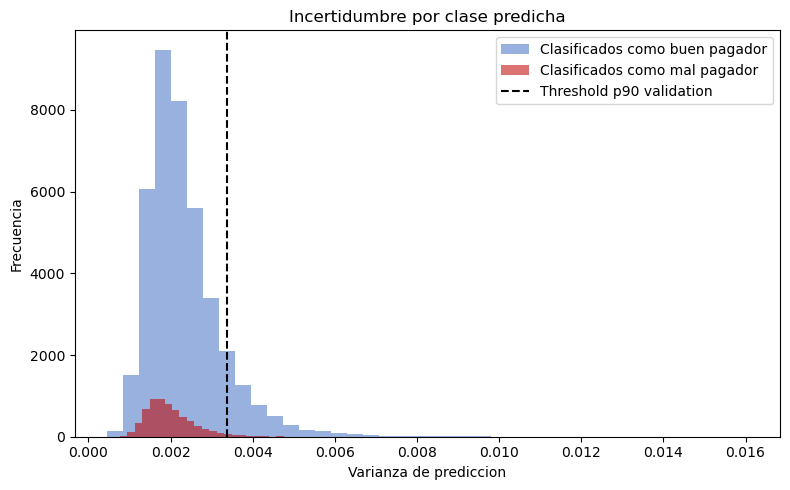

In [21]:
uncertainty_by_predicted_class = (
    test_predictions_with_uncertainty
    .groupby("predicted_label")
    .agg(
        n_obs=("prediction_variance", "size"),
        mean_variance=("prediction_variance", "mean"),
        median_variance=("prediction_variance", "median"),
        p75_variance=("prediction_variance", lambda x: np.percentile(x, 75)),
        p90_variance=("prediction_variance", lambda x: np.percentile(x, 90)),
        real_default_rate=("y_true", "mean"),
        mean_predicted_probability=("predicted_probability_mean", "mean"),
    )
    .reset_index()
)

good_mean = uncertainty_by_predicted_class.loc[
    uncertainty_by_predicted_class["predicted_label"] == "Buen pagador", "mean_variance"
]
bad_mean = uncertainty_by_predicted_class.loc[
    uncertainty_by_predicted_class["predicted_label"] == "Mal pagador", "mean_variance"
]
if len(good_mean) and len(bad_mean) and float(good_mean.iloc[0]) > 0:
    mean_var_good_pred = float(good_mean.iloc[0])
    mean_var_bad_pred = float(bad_mean.iloc[0])
    relative_diff = (mean_var_bad_pred - mean_var_good_pred) / mean_var_good_pred
else:
    relative_diff = np.nan

if pd.notna(relative_diff) and relative_diff > 0.10:
    uncertainty_interpretation = "La incertidumbre es claramente mayor en los clasificados como mal pagador."
elif pd.notna(relative_diff) and relative_diff > 0.02:
    uncertainty_interpretation = "La incertidumbre es ligeramente mayor en los clasificados como mal pagador, pero la diferencia es moderada."
else:
    uncertainty_interpretation = "La incertidumbre media apenas separa a buenos y malos pagadores predichos; su valor principal esta en detectar casos donde el modelo discrimina peor."

uncertainty_by_predicted_class["variance_relative_to_good"] = uncertainty_by_predicted_class["mean_variance"] / (float(good_mean.iloc[0]) if len(good_mean) else np.nan)
uncertainty_by_predicted_class["interpretation"] = uncertainty_interpretation
uncertainty_by_predicted_class.to_csv(TABLE_DIR / "uncertainty_by_predicted_class.csv", index=False)
display(uncertainty_by_predicted_class)
display(Markdown(f"**Interpretacion:** {uncertainty_interpretation}"))

plt.figure(figsize=(8, 5))
for label, color in [("Buen pagador", "#4472C4"), ("Mal pagador", "#C00000")]:
    values = test_predictions_with_uncertainty.loc[test_predictions_with_uncertainty["predicted_label"] == label, "prediction_variance"]
    plt.hist(values, bins=40, alpha=0.55, label=f"Clasificados como {label.lower()}", color=color)
plt.axvline(uncertainty_threshold_p90, color="black", linestyle="--", label="Threshold p90 validation")
plt.xlabel("Varianza de prediccion")
plt.ylabel("Frecuencia")
plt.title("Incertidumbre por clase predicha")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "uncertainty_distribution_predicted_good_vs_bad.png", dpi=140, bbox_inches="tight")
plt.show()


## EXT_SOURCE e incertidumbre, con control parcial por riesgo

Este analisis controla parcialmente por nivel de riesgo predicho. Asi distinguimos si la mayor incertidumbre se debe solo a que el grupo tiene mas riesgo, o si, para niveles de riesgo similares, la ausencia de EXT_SOURCE sigue asociada a mayor varianza.


,ext_source_quality_group,n_obs,mean_prediction_variance,median_prediction_variance,p90_prediction_variance,real_default_rate,mean_predicted_probability,roc_auc_group
0,Alta calidad,16429,0.0023,0.0021,0.0034,0.0725,0.3956,0.7642
2,Calidad media,24111,0.0022,0.0020,0.0032,0.0826,0.4289,0.7493
1,Baja calidad,5587,0.0026,0.0023,0.0039,0.0968,0.4786,0.7168


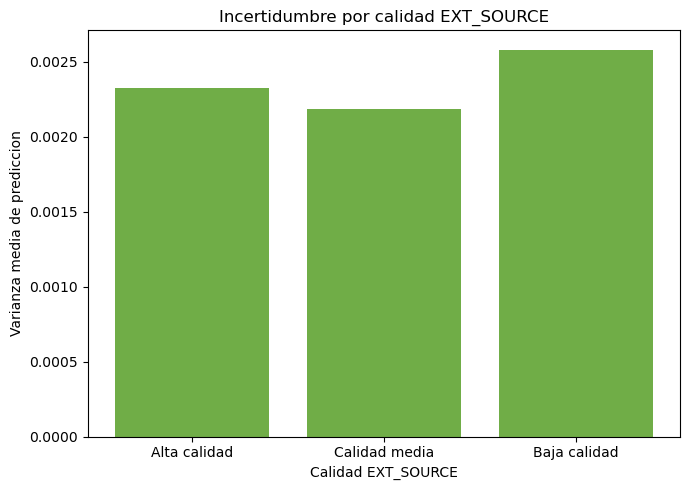

,risk_decile,ext_source_quality_group,n_obs,mean_predicted_probability,real_default_rate,mean_prediction_variance,median_prediction_variance
0,0,Alta calidad,2292,0.1362,0.0109,0.0018,0.0017
1,0,Baja calidad,219,0.1411,0.0502,0.0022,0.0021
2,0,Calidad media,2102,0.1399,0.0114,0.0019,0.0018
3,1,Alta calidad,1982,0.2134,0.0207,0.0024,0.0022
4,1,Baja calidad,310,0.2170,0.0194,0.0028,0.0027
5,1,Calidad media,2321,0.2147,0.0246,0.0024,0.0022
6,2,Alta calidad,1801,0.2718,0.0267,0.0024,0.0022
7,2,Baja calidad,435,0.2717,0.0276,0.0029,0.0026
8,2,Calidad media,2376,0.2727,0.0332,0.0024,0.0022
9,3,Alta calidad,1695,0.3267,0.0431,0.0024,0.0022


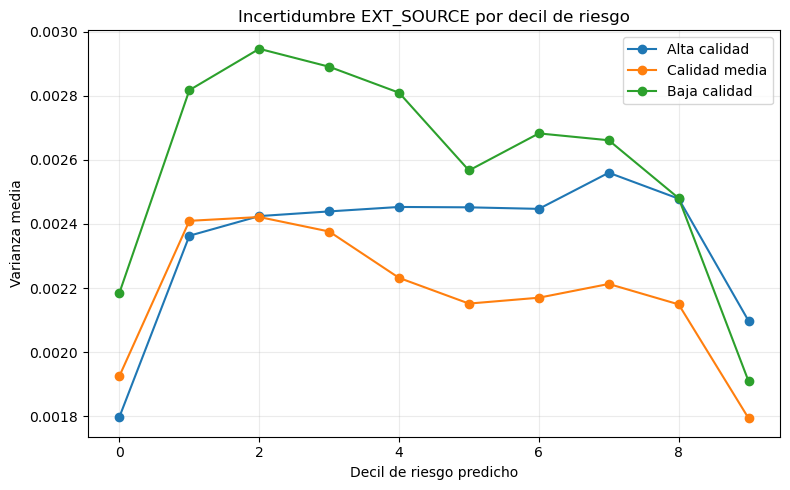

In [22]:
def ext_source_quality_group(missing_count):
    if missing_count == 0:
        return "Alta calidad"
    if missing_count == 1:
        return "Calidad media"
    return "Baja calidad"

test_predictions_with_uncertainty["EXT_SOURCE_AVAILABLE_COUNT"] = 3 - test_predictions_with_uncertainty["EXT_SOURCE_MISSING_COUNT"]
test_predictions_with_uncertainty["ext_source_quality_group"] = test_predictions_with_uncertainty["EXT_SOURCE_MISSING_COUNT"].apply(ext_source_quality_group)

quality_rows = []
for group, part in test_predictions_with_uncertainty.groupby("ext_source_quality_group"):
    quality_rows.append({
        "ext_source_quality_group": group,
        "n_obs": len(part),
        "mean_prediction_variance": part["prediction_variance"].mean(),
        "median_prediction_variance": part["prediction_variance"].median(),
        "p90_prediction_variance": np.percentile(part["prediction_variance"], 90),
        "real_default_rate": part["y_true"].mean(),
        "mean_predicted_probability": part["predicted_probability_mean"].mean(),
        "roc_auc_group": _safe_roc_auc(part["y_true"], part["predicted_probability_mean"]),
    })
uncertainty_by_ext_source_quality = pd.DataFrame(quality_rows)
quality_order = {"Alta calidad": 0, "Calidad media": 1, "Baja calidad": 2}
uncertainty_by_ext_source_quality["order"] = uncertainty_by_ext_source_quality["ext_source_quality_group"].map(quality_order)
uncertainty_by_ext_source_quality = uncertainty_by_ext_source_quality.sort_values("order").drop(columns="order")
uncertainty_by_ext_source_quality.to_csv(TABLE_DIR / "uncertainty_by_ext_source_quality.csv", index=False)
display(uncertainty_by_ext_source_quality)

plt.figure(figsize=(7, 5))
plt.bar(uncertainty_by_ext_source_quality["ext_source_quality_group"], uncertainty_by_ext_source_quality["mean_prediction_variance"], color="#70AD47")
plt.xlabel("Calidad EXT_SOURCE")
plt.ylabel("Varianza media de prediccion")
plt.title("Incertidumbre por calidad EXT_SOURCE")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "uncertainty_by_ext_source_quality.png", dpi=140, bbox_inches="tight")
plt.show()

test_predictions_with_uncertainty["risk_decile"] = pd.qcut(
    test_predictions_with_uncertainty["predicted_probability_mean"],
    10,
    labels=False,
    duplicates="drop",
)
uncertainty_ext_source_by_risk_decile = (
    test_predictions_with_uncertainty
    .groupby(["risk_decile", "ext_source_quality_group"])
    .agg(
        n_obs=("prediction_variance", "size"),
        mean_predicted_probability=("predicted_probability_mean", "mean"),
        real_default_rate=("y_true", "mean"),
        mean_prediction_variance=("prediction_variance", "mean"),
        median_prediction_variance=("prediction_variance", "median"),
    )
    .reset_index()
)
uncertainty_ext_source_by_risk_decile.to_csv(TABLE_DIR / "uncertainty_ext_source_by_risk_decile.csv", index=False)
display(uncertainty_ext_source_by_risk_decile.head(20))

plt.figure(figsize=(8, 5))
for group in ["Alta calidad", "Calidad media", "Baja calidad"]:
    part = uncertainty_ext_source_by_risk_decile[uncertainty_ext_source_by_risk_decile["ext_source_quality_group"] == group]
    if not part.empty:
        plt.plot(part["risk_decile"], part["mean_prediction_variance"], marker="o", label=group)
plt.xlabel("Decil de riesgo predicho")
plt.ylabel("Varianza media")
plt.title("Incertidumbre EXT_SOURCE por decil de riesgo")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "uncertainty_ext_source_by_risk_decile.png", dpi=140, bbox_inches="tight")
plt.show()


## Politica de prediccion selectiva con MC Dropout

La politica MC Dropout no se compara como un modelo mas, porque solo automatiza el subconjunto de menor incertidumbre. Se reporta como politica de cobertura selectiva.


,policy_name,uncertainty_threshold_source,coverage_automated,coverage_human_review,n_total_test,n_automated,n_human_review,roc_auc_automated,roc_auc_human_review,pr_auc_automated,pr_auc_human_review,default_rate_automated,default_rate_human_review,mean_variance_automated,mean_variance_human_review,f1_automated,precision_automated,recall_automated
0,MC Dropout p90 validation,validation,0.9006,0.0994,46127,41540,4587,0.7572,0.6816,0.2471,0.1334,0.0821,0.0682,0.0021,0.0043,0.3088,0.2424,0.4251


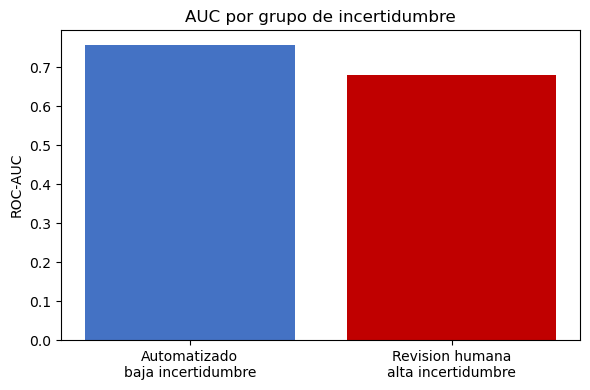

In [23]:
automated_mask = ~test_high_uncertainty
review_mask = test_high_uncertainty

selective_prediction_policy_results = pd.DataFrame([{
    "policy_name": "MC Dropout p90 validation",
    "uncertainty_threshold_source": "validation",
    "coverage_automated": float(automated_mask.mean()),
    "coverage_human_review": float(review_mask.mean()),
    "n_total_test": int(len(test_predictions_with_uncertainty)),
    "n_automated": int(automated_mask.sum()),
    "n_human_review": int(review_mask.sum()),
    "roc_auc_automated": _safe_roc_auc(y_test_np[automated_mask], test_mean_proba_mc[automated_mask]),
    "roc_auc_human_review": _safe_roc_auc(y_test_np[review_mask], test_mean_proba_mc[review_mask]),
    "pr_auc_automated": _safe_pr_auc(y_test_np[automated_mask], test_mean_proba_mc[automated_mask]),
    "pr_auc_human_review": _safe_pr_auc(y_test_np[review_mask], test_mean_proba_mc[review_mask]),
    "default_rate_automated": float(np.mean(y_test_np[automated_mask])),
    "default_rate_human_review": float(np.mean(y_test_np[review_mask])),
    "mean_variance_automated": float(np.mean(test_pred_variance[automated_mask])),
    "mean_variance_human_review": float(np.mean(test_pred_variance[review_mask])),
    "f1_automated": f1_score(y_test_np[automated_mask], test_pred_class[automated_mask], zero_division=0),
    "precision_automated": precision_score(y_test_np[automated_mask], test_pred_class[automated_mask], zero_division=0),
    "recall_automated": recall_score(y_test_np[automated_mask], test_pred_class[automated_mask], zero_division=0),
}])
selective_prediction_policy_results.to_csv(TABLE_DIR / "selective_prediction_policy_results.csv", index=False)
display(selective_prediction_policy_results)

plt.figure(figsize=(6, 4))
auc_values = [
    selective_prediction_policy_results.loc[0, "roc_auc_automated"],
    selective_prediction_policy_results.loc[0, "roc_auc_human_review"],
]
plt.bar(["Automatizado\nbaja incertidumbre", "Revision humana\nalta incertidumbre"], auc_values, color=["#4472C4", "#C00000"])
plt.ylabel("ROC-AUC")
plt.title("AUC por grupo de incertidumbre")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "selective_prediction_low_vs_high_uncertainty_auc.png", dpi=140, bbox_inches="tight")
plt.show()

human_review_policy_summary = selective_prediction_policy_results.copy()
human_review_policy_summary.to_csv(TABLE_DIR / "human_review_policy_summary.csv", index=False)


## Tabla general de modelos evaluados en todo test

La tabla general excluye la politica MC Dropout porque no cubre todo test.


,model,threshold_strategy,threshold,accuracy,balanced_accuracy,roc_auc,pr_auc,brier_score,precision,recall,f1,tn,fp,fn,tp,mean_prediction,default_rate_real,corr_pred_gender,demographic_parity_gap_score,demographic_parity_gap_label,equal_opportunity_gap,fpr_gap,evaluation_scope,validation_best_f1,lambda_corr
2,HistGradientBoosting,best_f1_validation,0.1600,0.8588,0.6513,0.7605,0.2552,0.0674,0.2594,0.4039,0.3159,38110,4293,2220,1504,0.0809,0.0807,0.1172,0.0194,0.0645,0.1009,0.0514,full_test,0.3083,NaN
5,AutoML Keras Tuner,best_f1_validation,0.6600,0.8463,0.6498,0.7529,0.2435,0.1971,0.2395,0.4154,0.3039,37492,4911,2177,1547,0.4145,0.0807,0.1431,0.0599,0.0812,0.1118,0.0688,full_test,NaN,NaN
3,Base NN Custom Layer original sin FAIR,best_f1_validation,0.6500,0.8404,0.6521,0.7529,0.2402,0.1995,0.2334,0.4275,0.3019,37173,5230,2132,1592,0.4213,0.0807,0.1408,0.0563,0.0810,0.1096,0.0686,full_test,NaN,0.0000
4,FAIR NN Custom Layer candidato original,best_f1_validation,0.6600,0.8451,0.6475,0.7513,0.2397,0.2003,0.2364,0.4119,0.3004,37448,4955,2190,1534,0.4200,0.0807,0.0375,0.0154,0.0427,0.0408,0.0334,full_test,NaN,1.0000
1,Logistic Regression,best_f1_validation,0.6600,0.8396,0.6494,0.7470,0.2346,0.2051,0.2306,0.4227,0.2984,37152,5251,2150,1574,0.4249,0.0807,0.1338,0.0563,0.0751,0.0904,0.0641,full_test,0.2919,NaN
0,Dummy prior,best_f1_validation,0.0100,0.0807,0.5000,0.5000,0.0807,0.0742,0.0807,1.0000,0.1494,0,42403,0,3724,0.0807,0.0807,NaN,0.0000,0.0000,0.0000,0.0000,full_test,0.1494,NaN


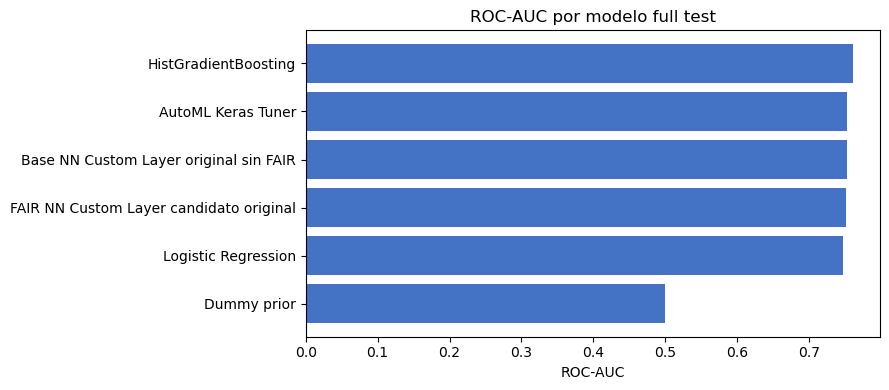

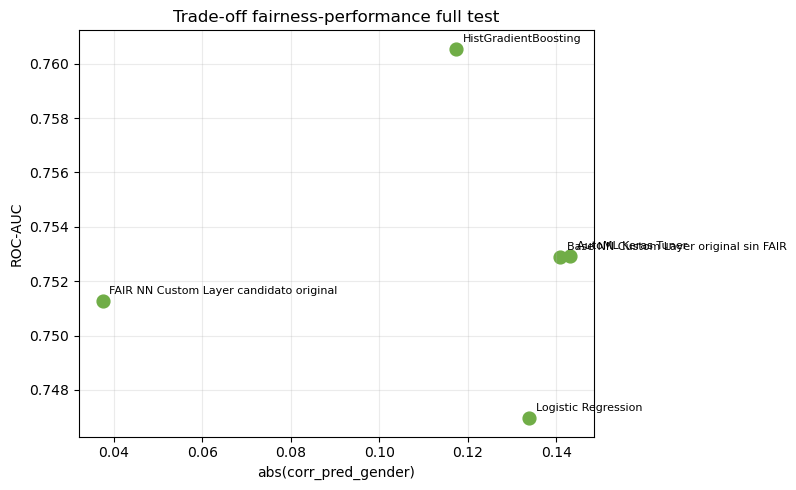

In [24]:
results_df = pd.DataFrame(results_full_test)
results_df = results_df[results_df["evaluation_scope"] == "full_test"].copy()
results_df.to_csv(TABLE_DIR / "model_comparison_results.csv", index=False)
display(results_df.sort_values("roc_auc", ascending=False))

plot_df = results_df.copy()
plot_df["abs_corr_pred_gender"] = plot_df["corr_pred_gender"].abs()

plt.figure(figsize=(9, max(4, 0.45 * len(plot_df))))
ordered = plot_df.sort_values("roc_auc", ascending=True)
plt.barh(ordered["model"], ordered["roc_auc"], color="#4472C4")
plt.xlabel("ROC-AUC")
plt.title("ROC-AUC por modelo full test")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "roc_auc_por_modelo.png", dpi=140, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["abs_corr_pred_gender"], plot_df["roc_auc"], s=85, color="#70AD47")
for _, row in plot_df.iterrows():
    plt.annotate(row["model"], (row["abs_corr_pred_gender"], row["roc_auc"]), textcoords="offset points", xytext=(5, 5), fontsize=8)
plt.xlabel("abs(corr_pred_gender)")
plt.ylabel("ROC-AUC")
plt.title("Trade-off fairness-performance full test")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "tradeoff_fairness_performance_general.png", dpi=140, bbox_inches="tight")
plt.show()


## README, requirements, gitignore y resumen ejecutivo critico


In [25]:
best_general = results_df.sort_values("roc_auc", ascending=False).iloc[0]
base_auc = tabla_base_vs_fair_test.loc[0, "roc_auc_test"]
fair_auc = tabla_base_vs_fair_test.loc[1, "roc_auc_test"]
base_corr = tabla_base_vs_fair_test.loc[0, "corr_pred_gender_test"]
fair_corr = tabla_base_vs_fair_test.loc[1, "corr_pred_gender_test"]
delta_auc = fair_auc - base_auc
delta_dep = abs(fair_corr) - abs(base_corr)

summary_md = "\n".join([
    "# Conclusiones para presentacion de 5 minutos",
    "",
    "## 1. Problema",
    "Home Credit Default Risk. TARGET mide dificultad de pago. CODE_GENDER es variable sensible.",
    "",
    "## 2. Capa custom financiera",
    "DebtRatioSaturationLayer calcula ratios monetarios raw y aplica tanh para limitar outliers.",
    "",
    "## 3. Modelo base vs FAIR",
    f"- AUC base: {base_auc:.4f}",
    f"- AUC FAIR: {fair_auc:.4f}",
    f"- correlacion genero base: {base_corr:.4f}",
    f"- correlacion genero FAIR: {fair_corr:.4f}",
    f"- delta AUC: {delta_auc:.4f}",
    f"- delta dependencia absoluta: {delta_dep:.4f}",
    "",
    "## 4. Pareto fairness-performance",
    f"El lambda FAIR seleccionado es {best_lambda_fair}, elegido con validation segun: {lambda_selection_rule}.",
    "",
    "## 5. Incertidumbre",
    "MC Dropout se calcula sin BatchNormalization. Cada prediccion devuelve clase, probabilidad media y varianza. El umbral de alta incertidumbre se fija en validation y alimenta una politica de revision humana.",
    "",
    "## 6. EXT_SOURCE",
    "Se analiza si la baja calidad de EXT_SOURCE aumenta incertidumbre y se repite el analisis dentro de deciles de riesgo predicho para controlar parcialmente por riesgo.",
    "",
    "## 7. Benchmark tabular",
    f"El mejor modelo predictivo puro en la tabla general es {best_general['model']}, pero el foco del taller es la red confiable con fairness e incertidumbre.",
    "",
    "## 8. Limitaciones",
    "- FAIR loss penaliza correlacion lineal, no toda dependencia posible.",
    "- La penalizacion se calcula por batch.",
    "- Probabilidades necesitan calibracion.",
    "- MC Dropout da incertidumbre aproximada.",
    "- Resultados dependen de semilla, por eso se anade analisis multi-seed.",
    "",
    "## 9. Mensaje final",
    "El modelo FAIR no maximiza unicamente AUC, sino que ofrece un mejor compromiso entre capacidad predictiva, justicia demografica e incertidumbre.",
    "",
    "## Nota sobre incertidumbre",
    uncertainty_interpretation,
])
Path("resumen_presentacion_5min.md").write_text(summary_md, encoding="utf-8")

readme_md = "\n".join([
    "# Taller B4-T1: Redes Confiables para Credit Scoring",
    "",
    "## 1. Objetivo",
    "Construir y auditar modelos de credit scoring con redes confiables, fairness e incertidumbre.",
    "",
    "## 2. Dataset",
    "Home Credit Default Risk, archivo `application_train.csv`. TARGET mide dificultad de pago.",
    "",
    "## 3. Estructura del repositorio",
    "- notebooks `.ipynb`",
    "- `tables/`: resultados CSV",
    "- `figures/`: graficos PNG",
    "- `models/`: modelos si se exportan",
    "",
    "## 4. Como ejecutar el notebook",
    "Abrir `Practica_via_B_mejorada_entrega_v2_critica.ipynb` en Jupyter y ejecutar de arriba abajo. Para depurar, activar `FAST_MODE=True`.",
    "",
    "## 5. Modelos entrenados",
    "Dummy, Logistic Regression, HistGradientBoosting, redes con/sin capa custom, FAIR loss y AutoML/Keras Tuner.",
    "",
    "## 6. Metricas principales",
    "ROC-AUC, PR-AUC, Brier Score, precision, recall, F1 y metricas fairness por genero.",
    "",
    "## 7. Resultados clave Base vs FAIR",
    f"Base AUC={base_auc:.4f}; FAIR AUC={fair_auc:.4f}; delta AUC={delta_auc:.4f}; delta dependencia={delta_dep:.4f}.",
    "",
    "## 8. Incertidumbre y revision humana",
    "MC Dropout estima varianza predictiva y define una politica de revision humana con threshold fijado en validation.",
    "",
    "## 9. Limitaciones",
    "Fairness solo por genero, perdida batch-wise, calibracion necesaria y MC Dropout aproximado.",
    "",
    "## 10. Archivos generados",
    "Ver `tables/`, `figures/` y `resumen_presentacion_5min.md`.",
])
Path("README.md").write_text(readme_md, encoding="utf-8")

Path("requirements.txt").write_text("\n".join([
    "pandas",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tensorflow",
    "keras-tuner",
    "jupyter",
    "",
]), encoding="utf-8")

Path(".gitignore").write_text("\n".join([
    "__pycache__/",
    ".ipynb_checkpoints/",
    "models/",
    "*.h5",
    "*.keras",
    "*.pkl",
    "*.joblib",
    ".DS_Store",
    "",
]), encoding="utf-8")

display(Markdown(summary_md))


# Conclusiones para presentacion de 5 minutos

## 1. Problema
Home Credit Default Risk. TARGET mide dificultad de pago. CODE_GENDER es variable sensible.

## 2. Capa custom financiera
DebtRatioSaturationLayer calcula ratios monetarios raw y aplica tanh para limitar outliers.

## 3. Modelo base vs FAIR
- AUC base: 0.7529
- AUC FAIR: 0.7513
- correlacion genero base: 0.1408
- correlacion genero FAIR: 0.0375
- delta AUC: -0.0016
- delta dependencia absoluta: -0.1034

## 4. Pareto fairness-performance
El lambda FAIR seleccionado es 1.0, elegido con validation segun: Mayor val_roc_auc_mean con val_abs_corr_mean < 0.05.

## 5. Incertidumbre
MC Dropout se calcula sin BatchNormalization. Cada prediccion devuelve clase, probabilidad media y varianza. El umbral de alta incertidumbre se fija en validation y alimenta una politica de revision humana.

## 6. EXT_SOURCE
Se analiza si la baja calidad de EXT_SOURCE aumenta incertidumbre y se repite el analisis dentro de deciles de riesgo predicho para controlar parcialmente por riesgo.

## 7. Benchmark tabular
El mejor modelo predictivo puro en la tabla general es HistGradientBoosting, pero el foco del taller es la red confiable con fairness e incertidumbre.

## 8. Limitaciones
- FAIR loss penaliza correlacion lineal, no toda dependencia posible.
- La penalizacion se calcula por batch.
- Probabilidades necesitan calibracion.
- MC Dropout da incertidumbre aproximada.
- Resultados dependen de semilla, por eso se anade analisis multi-seed.

## 9. Mensaje final
El modelo FAIR no maximiza unicamente AUC, sino que ofrece un mejor compromiso entre capacidad predictiva, justicia demografica e incertidumbre.

## Nota sobre incertidumbre
La incertidumbre media apenas separa a buenos y malos pagadores predichos; su valor principal esta en detectar casos donde el modelo discrimina peor.

# Correcciones v4: selección final sin test y narrativa de fiabilidad

Esta sección sustituye la selección final de la v3. El objetivo es dejar el notebook listo para entrega:

- La selección entre capa original y adaptativa usa solo validation y auditoría de saturación en train.
- El test se reserva para evaluación final.
- La incertidumbre MC Dropout se interpreta como fiabilidad del modelo, no como riesgo directo.
- La tabla Base vs FAIR final usa predicciones reentrenadas y bootstrap final.


## AutoML y fairness: limitación explícita

El AutoML implementado en este notebook no es un optimizador Pareto multiobjetivo puro. Keras Tuner se usa principalmente para encontrar una arquitectura predictiva competitiva. Después, el trade-off fairness-performance se analiza mediante el barrido de `lambda_corr` FAIR.

Por tanto, lo correcto es hablar de **AutoML predictivo + análisis de fairness**, no de AutoML fairness completo. Cuando se usa un score combinado, se trata de una escalarización de varias métricas, no de una frontera de Pareto multiobjetivo exacta.


## Capa adaptativa y auditoría de saturación

La saturación adaptativa corrige un problema de escala: `CREDIT_INCOME_RATIO` puede ser mucho mayor que otros ratios, por lo que `tanh(1.0 * ratio)` comprime demasiada información cerca de 1.


,ratio_name,method,alpha,raw_median,raw_p95,raw_p99,raw_max,sat_median,sat_p95,sat_p99,sat_max,pct_sat_above_0_95,pct_sat_above_0_99
0,ANNUITY_INCOME_RAW,original_alpha_1,1.0000,0.1626,0.3549,0.4845,1.5706,0.1612,0.3407,0.4498,0.9171,0.0000,0.0000
1,ANNUITY_INCOME_RAW,adaptive_alpha,1.0000,0.1626,0.3549,0.4845,1.5706,0.1612,0.3407,0.4498,0.9171,0.0000,0.0000
2,CREDIT_INCOME_RAW,original_alpha_1,1.0000,3.2531,9.1229,13.0136,49.2272,0.9970,1.0000,1.0000,1.0000,0.7976,0.6230
3,CREDIT_INCOME_RAW,adaptive_alpha,0.1000,3.2531,9.1229,13.0136,49.2272,0.3143,0.7222,0.8621,0.9999,0.0014,0.0002
4,ANNUITY_CREDIT_RAW,original_alpha_1,1.0000,0.0500,0.1050,0.1143,0.1581,0.0500,0.1046,0.1138,0.1568,0.0000,0.0000
5,ANNUITY_CREDIT_RAW,adaptive_alpha,5.0000,0.0500,0.1050,0.1143,0.1581,0.2449,0.4816,0.5164,0.6587,0.0000,0.0000
6,GOODS_CREDIT_RAW,original_alpha_1,1.0000,0.8938,1.0000,1.0000,6.6667,0.7133,0.7616,0.7616,1.0000,0.0008,0.0002
7,GOODS_CREDIT_RAW,adaptive_alpha,1.0000,0.8938,1.0000,1.0000,6.6667,0.7133,0.7616,0.7616,1.0000,0.0008,0.0002


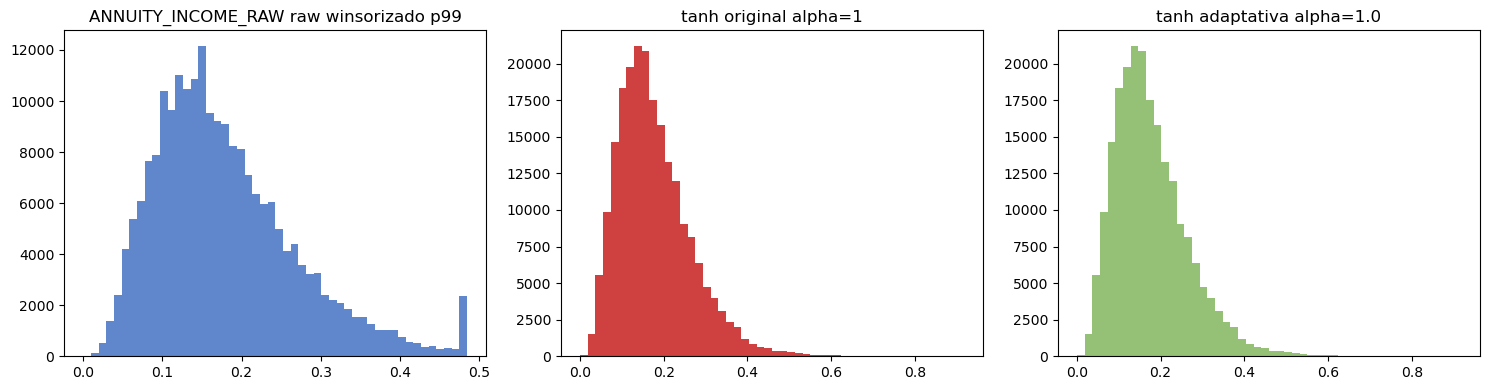

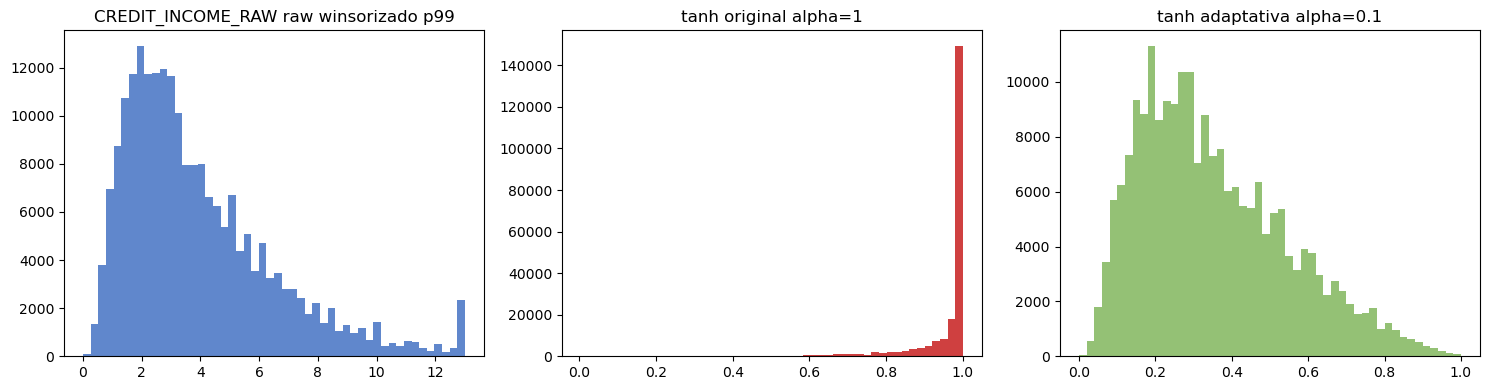

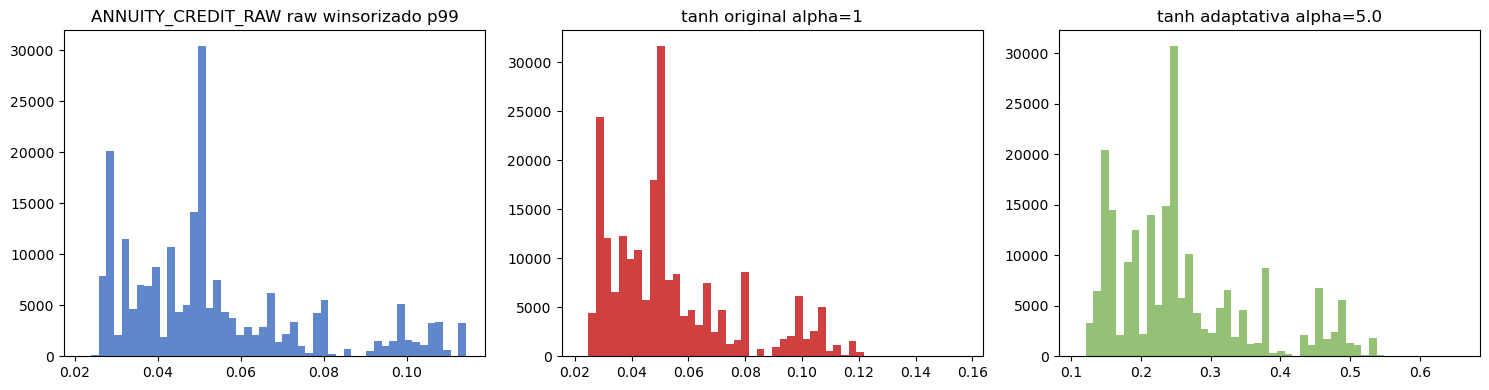

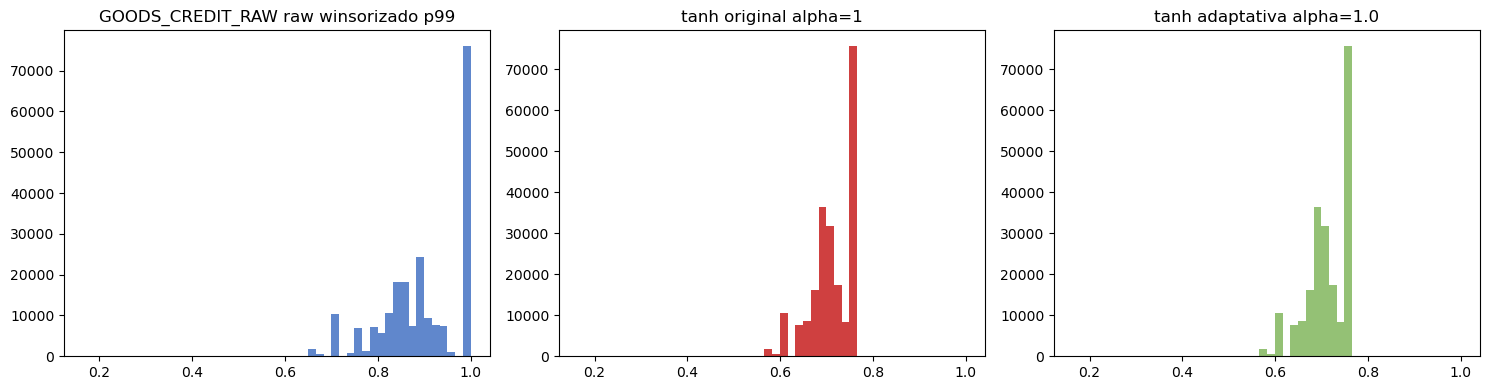

In [26]:
SEEDS_ADAPTIVE_FAIR_SWEEP = [42] if FAST_MODE else [42, 123, 2026]
lambdas_adaptive = [0.0, 0.1, 0.3, 0.5, 0.8, 1.0]


class DebtRatioAdaptiveSaturationLayer(keras.layers.Layer):
    def __init__(
        self,
        units=8,
        alpha_annuity_income=1.0,
        alpha_credit_income=0.10,
        alpha_annuity_credit=5.0,
        alpha_goods_credit=1.0,
        epsilon=1e-6,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.alpha_annuity_income = alpha_annuity_income
        self.alpha_credit_income = alpha_credit_income
        self.alpha_annuity_credit = alpha_annuity_credit
        self.alpha_goods_credit = alpha_goods_credit
        self.units = units
        self.epsilon = epsilon
        self.projection = layers.Dense(units, activation="relu")

    def call(self, inputs):
        income = inputs[:, 0:1]
        annuity = inputs[:, 1:2]
        credit = inputs[:, 2:3]
        goods = inputs[:, 3:4]

        annuity_income = annuity / (income + self.epsilon)
        credit_income = credit / (income + self.epsilon)
        annuity_credit = annuity / (credit + self.epsilon)
        goods_credit = goods / (credit + self.epsilon)

        ratios_sat = tf.concat(
            [
                tf.math.tanh(self.alpha_annuity_income * annuity_income),
                tf.math.tanh(self.alpha_credit_income * credit_income),
                tf.math.tanh(self.alpha_annuity_credit * annuity_credit),
                tf.math.tanh(self.alpha_goods_credit * goods_credit),
            ],
            axis=-1,
        )
        return self.projection(ratios_sat)

    def get_config(self):
        config = super().get_config()
        config.update({
            "alpha_annuity_income": self.alpha_annuity_income,
            "alpha_credit_income": self.alpha_credit_income,
            "alpha_annuity_credit": self.alpha_annuity_credit,
            "alpha_goods_credit": self.alpha_goods_credit,
            "units": self.units,
            "epsilon": self.epsilon,
        })
        return config


ADAPTIVE_ALPHAS = {
    "ANNUITY_INCOME_RAW": 1.0,
    "CREDIT_INCOME_RAW": 0.10,
    "ANNUITY_CREDIT_RAW": 5.0,
    "GOODS_CREDIT_RAW": 1.0,
}


def build_adaptive_custom_layer_model(
    processed_dim,
    dense_units=(64, 32),
    dropout_rates=(0.25, 0.20),
    learning_rate=1e-3,
    fair_lambda=None,
    model_name="adaptive_custom_model",
):
    processed_input = keras.Input(shape=(processed_dim,), name="processed_input")
    raw_financial_input = keras.Input(shape=(4,), name="raw_financial_input")
    financial_repr = DebtRatioAdaptiveSaturationLayer(name="debt_ratio_adaptive_saturation")(raw_financial_input)
    x = layers.Concatenate(name="concat_processed_adaptive_financial")([processed_input, financial_repr])
    for i, units in enumerate(dense_units):
        x = layers.Dense(units, activation="relu", name=f"dense_{i+1}")(x)
        x = layers.LayerNormalization(name=f"layer_norm_{i+1}")(x)
        dropout = dropout_rates[i] if i < len(dropout_rates) else dropout_rates[-1]
        x = layers.Dropout(dropout, name=f"dropout_{i+1}")(x)
    output = layers.Dense(1, activation="sigmoid", name="default_probability")(x)
    model = keras.Model([processed_input, raw_financial_input], output, name=model_name)
    compile_model(model, fair_lambda=fair_lambda, learning_rate=learning_rate)
    return model


def raw_financial_ratios_from_matrix(raw_matrix, eps=1e-6):
    income = raw_matrix[:, 0]
    annuity = raw_matrix[:, 1]
    credit = raw_matrix[:, 2]
    goods = raw_matrix[:, 3]
    return pd.DataFrame({
        "ANNUITY_INCOME_RAW": annuity / (income + eps),
        "CREDIT_INCOME_RAW": credit / (income + eps),
        "ANNUITY_CREDIT_RAW": annuity / (credit + eps),
        "GOODS_CREDIT_RAW": goods / (credit + eps),
    }).replace([np.inf, -np.inf], np.nan)


raw_ratios_train_v4 = raw_financial_ratios_from_matrix(X_train_fin_raw)
saturation_rows = []
for ratio_name in raw_ratios_train_v4.columns:
    raw = raw_ratios_train_v4[ratio_name].dropna()
    for method, alpha in [("original_alpha_1", 1.0), ("adaptive_alpha", ADAPTIVE_ALPHAS[ratio_name])]:
        sat = np.tanh(alpha * raw)
        saturation_rows.append({
            "ratio_name": ratio_name,
            "method": method,
            "alpha": alpha,
            "raw_median": raw.median(),
            "raw_p95": raw.quantile(0.95),
            "raw_p99": raw.quantile(0.99),
            "raw_max": raw.max(),
            "sat_median": np.median(sat),
            "sat_p95": np.percentile(sat, 95),
            "sat_p99": np.percentile(sat, 99),
            "sat_max": np.max(sat),
            "pct_sat_above_0_95": float(np.mean(sat > 0.95)),
            "pct_sat_above_0_99": float(np.mean(sat > 0.99)),
        })

ratio_saturation_original_vs_adaptive = pd.DataFrame(saturation_rows)
ratio_saturation_original_vs_adaptive.to_csv(TABLE_DIR / "ratio_saturation_original_vs_adaptive.csv", index=False)
display(ratio_saturation_original_vs_adaptive)

plot_map = {
    "ANNUITY_INCOME_RAW": "saturation_comparison_annuity_income.png",
    "CREDIT_INCOME_RAW": "saturation_comparison_credit_income.png",
    "ANNUITY_CREDIT_RAW": "saturation_comparison_annuity_credit.png",
    "GOODS_CREDIT_RAW": "saturation_comparison_goods_credit.png",
}
for ratio_name, filename in plot_map.items():
    raw = raw_ratios_train_v4[ratio_name].dropna()
    raw_w = raw.clip(upper=raw.quantile(0.99))
    sat_original = np.tanh(raw)
    sat_adaptive = np.tanh(ADAPTIVE_ALPHAS[ratio_name] * raw)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].hist(raw_w, bins=50, color="#4472C4", alpha=0.85)
    axes[0].set_title(f"{ratio_name} raw winsorizado p99")
    axes[1].hist(sat_original, bins=50, color="#C00000", alpha=0.75)
    axes[1].set_title("tanh original alpha=1")
    axes[2].hist(sat_adaptive, bins=50, color="#70AD47", alpha=0.75)
    axes[2].set_title(f"tanh adaptativa alpha={ADAPTIVE_ALPHAS[ratio_name]}")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=140, bbox_inches="tight")
    plt.show()


## Sweep adaptativo multi-seed

La selección de `lambda_corr` para la capa adaptativa se hace con medias de validation sobre varias semillas. Las métricas de test se guardan solo para reporte final, no para seleccionar.


In [27]:
adaptive_seed_val_rows = []
adaptive_seed_test_rows = []

for seed in SEEDS_ADAPTIVE_FAIR_SWEEP:
    for lambda_corr in lambdas_adaptive:
        print(f"Entrenando adaptativo seed={seed}, lambda={lambda_corr}...")
        reset_seeds(seed)
        tf.keras.backend.clear_session()
        model = build_adaptive_custom_layer_model(
            processed_dim=input_dim,
            dense_units=(64, 32),
            dropout_rates=(0.25, 0.20),
            learning_rate=1e-3,
            fair_lambda=lambda_corr,
            model_name=f"Adaptive_Fair_seed_{seed}_lambda_{lambda_corr}",
        )
        assert_no_batchnorm(model)
        model.fit(
            [X_train_keras, X_train_fin_raw],
            y_train_ext,
            validation_data=([X_val_keras, X_val_fin_raw], y_val_ext, sample_weight_val),
            sample_weight=sample_weight_train,
            epochs=FAIRNESS_EPOCHS,
            batch_size=FAIR_BATCH_SIZE,
            callbacks=make_callbacks(monitor="val_loss", mode="min", patience=5),
            verbose=0,
        )
        val_proba = model.predict([X_val_keras, X_val_fin_raw], batch_size=BATCH_SIZE, verbose=0).ravel()
        test_proba = model.predict([X_test_keras, X_test_fin_raw], batch_size=BATCH_SIZE, verbose=0).ravel()
        threshold, _ = find_best_threshold(y_val_np, val_proba, metric="f1")
        val_metrics = evaluate_model("adaptive_seed_validation", y_val_np, val_proba, s_val_np, threshold, "best_f1_validation")
        test_metrics = evaluate_model("adaptive_seed_test", y_test_np, test_proba, s_test_np, threshold, "best_f1_validation")
        adaptive_seed_val_rows.append({
            "seed": seed,
            "lambda_corr": lambda_corr,
            "split": "validation",
            "roc_auc": val_metrics["roc_auc"],
            "pr_auc": val_metrics["pr_auc"],
            "corr_pred_gender": val_metrics["corr_pred_gender"],
            "abs_corr_pred_gender": abs(val_metrics["corr_pred_gender"]),
            "demographic_parity_gap_score": val_metrics["demographic_parity_gap_score"],
            "equal_opportunity_gap": val_metrics["equal_opportunity_gap"],
            "fpr_gap": val_metrics["fpr_gap"],
            "precision": val_metrics["precision"],
            "recall": val_metrics["recall"],
            "f1": val_metrics["f1"],
        })
        adaptive_seed_test_rows.append({
            "seed": seed,
            "lambda_corr": lambda_corr,
            "split": "test",
            "roc_auc": test_metrics["roc_auc"],
            "pr_auc": test_metrics["pr_auc"],
            "corr_pred_gender": test_metrics["corr_pred_gender"],
            "abs_corr_pred_gender": abs(test_metrics["corr_pred_gender"]),
            "demographic_parity_gap_score": test_metrics["demographic_parity_gap_score"],
            "equal_opportunity_gap": test_metrics["equal_opportunity_gap"],
            "fpr_gap": test_metrics["fpr_gap"],
            "precision": test_metrics["precision"],
            "recall": test_metrics["recall"],
            "f1": test_metrics["f1"],
        })

lambda_adaptive_seed_results_validation = pd.DataFrame(adaptive_seed_val_rows)
lambda_adaptive_seed_results_test = pd.DataFrame(adaptive_seed_test_rows)
lambda_adaptive_seed_results_validation.to_csv(TABLE_DIR / "lambda_adaptive_seed_results_validation.csv", index=False)
lambda_adaptive_seed_results_test.to_csv(TABLE_DIR / "lambda_adaptive_seed_results_test.csv", index=False)

val_summary_adapt = lambda_adaptive_seed_results_validation.groupby("lambda_corr").agg(
    val_roc_auc_mean=("roc_auc", "mean"),
    val_roc_auc_std=("roc_auc", "std"),
    val_pr_auc_mean=("pr_auc", "mean"),
    val_pr_auc_std=("pr_auc", "std"),
    val_abs_corr_mean=("abs_corr_pred_gender", "mean"),
    val_abs_corr_std=("abs_corr_pred_gender", "std"),
    val_demographic_parity_gap_mean=("demographic_parity_gap_score", "mean"),
    val_demographic_parity_gap_std=("demographic_parity_gap_score", "std"),
).reset_index()
test_summary_adapt = lambda_adaptive_seed_results_test.groupby("lambda_corr").agg(
    test_roc_auc_mean=("roc_auc", "mean"),
    test_roc_auc_std=("roc_auc", "std"),
    test_abs_corr_mean=("abs_corr_pred_gender", "mean"),
    test_abs_corr_std=("abs_corr_pred_gender", "std"),
).reset_index()
lambda_adaptive_sweep_summary_by_seed = val_summary_adapt.merge(test_summary_adapt, on="lambda_corr", how="left")
lambda_adaptive_sweep_summary_by_seed["n_runs"] = len(SEEDS_ADAPTIVE_FAIR_SWEEP)
lambda_adaptive_sweep_summary_by_seed.to_csv(TABLE_DIR / "lambda_adaptive_sweep_summary_by_seed.csv", index=False)
display(lambda_adaptive_sweep_summary_by_seed)

eligible = lambda_adaptive_sweep_summary_by_seed[
    lambda_adaptive_sweep_summary_by_seed["val_abs_corr_mean"] < 0.05
].copy()
if not eligible.empty:
    max_auc = eligible["val_roc_auc_mean"].max()
    practical_ties = eligible[eligible["val_roc_auc_mean"] >= max_auc - 0.001]
    selected_adaptive_lambda_row = practical_ties.sort_values("lambda_corr").iloc[0]
    best_lambda_adaptive_selection_reason = (
        "Seleccionada con validation agregado: abs corr < 0.05, AUC dentro de empate práctico de 0.001 y lambda menor."
    )
else:
    tmp = lambda_adaptive_sweep_summary_by_seed.copy()
    tmp["score"] = tmp["val_roc_auc_mean"] - 0.05 * tmp["val_abs_corr_mean"]
    selected_adaptive_lambda_row = tmp.sort_values("score", ascending=False).iloc[0]
    best_lambda_adaptive_selection_reason = (
        "Ninguna lambda cumple abs corr < 0.05; se maximiza val_roc_auc_mean - 0.05 * val_abs_corr_mean."
    )

best_lambda_adaptive = float(selected_adaptive_lambda_row["lambda_corr"])
best_lambda_adaptive_selection = pd.DataFrame([{
    "best_lambda_adaptive": best_lambda_adaptive,
    "selection_reason": best_lambda_adaptive_selection_reason,
    "val_roc_auc_mean": selected_adaptive_lambda_row["val_roc_auc_mean"],
    "val_abs_corr_mean": selected_adaptive_lambda_row["val_abs_corr_mean"],
}])
best_lambda_adaptive_selection.to_csv(TABLE_DIR / "best_lambda_adaptive_selection.csv", index=False)
display(best_lambda_adaptive_selection)


Entrenando adaptativo seed=42, lambda=0.0...

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 19.
Entrenando adaptativo seed=42, lambda=0.1...

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 16.
Entrenando adaptativo seed=42, lambda=0.3...

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 16.
Entrenando adaptativo seed=42, lambda=0.5...

Epoch 14: ReduceLR

,lambda_corr,val_roc_auc_mean,val_roc_auc_std,val_pr_auc_mean,val_pr_auc_std,val_abs_corr_mean,val_abs_corr_std,val_demographic_parity_gap_mean,val_demographic_parity_gap_std,test_roc_auc_mean,test_roc_auc_std,test_abs_corr_mean,test_abs_corr_std,n_runs
0,0.0000,0.7493,0.0008,0.2308,0.0027,0.1377,0.0008,0.0594,0.0014,0.7526,0.0009,0.1354,0.0015,3
1,0.1000,0.7491,0.0008,0.2304,0.0024,0.1033,0.0023,0.0441,0.0008,0.7525,0.0008,0.1012,0.0028,3
2,0.3000,0.7480,0.0006,0.2295,0.0023,0.0686,0.0021,0.0290,0.0009,0.7520,0.0005,0.0671,0.0023,3
3,0.5000,0.7472,0.0005,0.2289,0.0021,0.0526,0.0021,0.0223,0.0005,0.7514,0.0003,0.0513,0.0024,3
4,0.8000,0.7465,0.0005,0.2289,0.0023,0.0391,0.0008,0.0167,0.0004,0.7510,0.0002,0.0380,0.0004,3
5,1.0000,0.7463,0.0005,0.2287,0.0019,0.0343,0.0010,0.0147,0.0004,0.7508,0.0002,0.0330,0.0004,3


,best_lambda_adaptive,selection_reason,val_roc_auc_mean,val_abs_corr_mean
0,0.8000,Seleccionada con validation agregado: abs corr...,0.7465,0.0391


## Selección final de capa usando solo validation y saturación en train

La selección del modelo final se realiza únicamente con validation y con la auditoría de saturación en train. El test queda reservado para evaluación final.


In [28]:
def select_final_custom_layer_model(
    original_val_metrics,
    adaptive_val_metrics,
    saturation_summary,
    max_auc_loss=0.005,
    max_abs_corr=0.05,
):
    credit_rows = saturation_summary[saturation_summary["ratio_name"] == "CREDIT_INCOME_RAW"]
    original_sat = float(
        credit_rows.loc[credit_rows["method"] == "original_alpha_1", "pct_sat_above_0_99"].iloc[0]
    )
    adaptive_sat = float(
        credit_rows.loc[credit_rows["method"] == "adaptive_alpha", "pct_sat_above_0_99"].iloc[0]
    )
    saturation_reduced = adaptive_sat < original_sat * 0.75 or (original_sat - adaptive_sat) >= 0.10

    best_val_auc = max(original_val_metrics["roc_auc"], adaptive_val_metrics["roc_auc"])
    adaptive_auc_loss = best_val_auc - adaptive_val_metrics["roc_auc"]
    adaptive_fair_ok = abs(adaptive_val_metrics["corr_pred_gender"]) < max_abs_corr

    rows = []
    for name, layer_type, metrics, sat_value in [
        ("FAIR candidato capa original", "original_common_tanh", original_val_metrics, original_sat),
        ("FAIR candidato capa adaptativa", "adaptive_tanh", adaptive_val_metrics, adaptive_sat),
    ]:
        rows.append({
            "candidate_model": name,
            "custom_layer_type": layer_type,
            "val_roc_auc": metrics["roc_auc"],
            "val_pr_auc": metrics["pr_auc"],
            "val_abs_corr_pred_gender": abs(metrics["corr_pred_gender"]),
            "val_demographic_parity_gap_score": metrics["demographic_parity_gap_score"],
            "credit_income_pct_sat_above_0_99": sat_value,
            "selected": False,
            "selection_reason": "",
        })

    if saturation_reduced and adaptive_auc_loss <= max_auc_loss and adaptive_fair_ok:
        selected_layer = "adaptive"
        reason = (
            "Se elige capa adaptativa: reduce saturación de CREDIT_INCOME_RATIO, "
            "no pierde más de 0.005 AUC en validation y cumple abs(corr)<0.05."
        )
    elif adaptive_auc_loss > max_auc_loss:
        selected_layer = "original"
        reason = (
            "Se mantiene capa original: la adaptativa pierde más de 0.005 ROC-AUC en validation."
        )
    elif not adaptive_fair_ok:
        selected_layer = "original"
        reason = (
            "Se mantiene capa original: la adaptativa no cumple abs(corr_pred_gender_val)<0.05."
        )
    else:
        selected_layer = "original"
        reason = (
            "Se mantiene capa original: la mejora de saturación no es suficientemente clara."
        )

    result = pd.DataFrame(rows)
    result.loc[result["custom_layer_type"].eq("adaptive_tanh" if selected_layer == "adaptive" else "original_common_tanh"), "selected"] = True
    result["selection_reason"] = reason
    return selected_layer, reason, result


reset_seeds(42)
tf.keras.backend.clear_session()
adaptive_fair_candidate = build_adaptive_custom_layer_model(
    processed_dim=input_dim,
    dense_units=(64, 32),
    dropout_rates=(0.25, 0.20),
    learning_rate=1e-3,
    fair_lambda=best_lambda_adaptive,
    model_name="FAIR_NN_Adaptive_CustomLayer_candidate",
)
assert_no_batchnorm(adaptive_fair_candidate)
adaptive_fair_candidate.fit(
    [X_train_keras, X_train_fin_raw],
    y_train_ext,
    validation_data=([X_val_keras, X_val_fin_raw], y_val_ext, sample_weight_val),
    sample_weight=sample_weight_train,
    epochs=MAX_EPOCHS,
    batch_size=FAIR_BATCH_SIZE,
    callbacks=make_callbacks(monitor="val_loss", mode="min", patience=8),
    verbose=1,
)
adaptive_candidate_val_proba = adaptive_fair_candidate.predict([X_val_keras, X_val_fin_raw], batch_size=BATCH_SIZE).ravel()
adaptive_candidate_val_threshold, _ = find_best_threshold(y_val_np, adaptive_candidate_val_proba, metric="f1")
adaptive_candidate_val_metrics = evaluate_model(
    "FAIR candidato capa adaptativa",
    y_val_np,
    adaptive_candidate_val_proba,
    s_val_np,
    adaptive_candidate_val_threshold,
    "best_f1_validation",
)

original_candidate_val_metrics = evaluate_model(
    "FAIR candidato capa original",
    y_val_np,
    y_val_proba_fair,
    s_val_np,
    best_threshold_fair,
    "best_f1_validation",
)

final_layer_choice, final_layer_selection_reason, final_model_selection_validation_only = select_final_custom_layer_model(
    original_candidate_val_metrics,
    adaptive_candidate_val_metrics,
    ratio_saturation_original_vs_adaptive,
    max_auc_loss=0.005,
    max_abs_corr=0.05,
)
final_model_selection_validation_only.to_csv(TABLE_DIR / "final_model_selection_validation_only.csv", index=False)
display(final_model_selection_validation_only)
print("final_layer_choice:", final_layer_choice)
print(final_layer_selection_reason)


Epoch 1/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6723 - val_loss: 0.6091 - learning_rate: 0.0010
Epoch 2/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6251 - val_loss: 0.6041 - learning_rate: 0.0010
Epoch 3/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6151 - val_loss: 0.6022 - learning_rate: 0.0010
Epoch 4/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6103 - val_loss: 0.6010 - learning_rate: 0.0010
Epoch 5/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6078 - val_loss: 0.6000 - learning_rate: 0.0010
Epoch 6/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6049 - val_loss: 0.5997 - learning_rate: 0.0010
Epoch 7/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6039 - val_loss: 0.5993 - learning_rate: 0.0010
Epoch 8/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6023 - val_loss: 0.5988 - learning_rate: 0.0010
Epoch 9/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6015 - val_loss: 0.5984 - learning_rate: 0.0010
Epoch 10/8

,candidate_model,custom_layer_type,val_roc_auc,val_pr_auc,val_abs_corr_pred_gender,val_demographic_parity_gap_score,credit_income_pct_sat_above_0_99,selected,selection_reason
0,FAIR candidato capa original,original_common_tanh,0.7470,0.2301,0.0381,0.0156,0.6230,False,Se elige capa adaptativa: reduce saturación de...
1,FAIR candidato capa adaptativa,adaptive_tanh,0.7469,0.2309,0.0439,0.0177,0.0002,True,Se elige capa adaptativa: reduce saturación de...


final_layer_choice: adaptive
Se elige capa adaptativa: reduce saturación de CREDIT_INCOME_RATIO, no pierde más de 0.005 AUC en validation y cumple abs(corr)<0.05.


## Reentrenamiento final Base vs FAIR

Una vez seleccionados capa y lambda con validation, se reentrenan dos modelos finales con semilla 42. La única diferencia entre ambos es la FAIR loss.


Epoch 1/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.6938 - loss: 0.6516 - pr_auc: 0.1564 - val_auc: 0.7393 - val_loss: 0.5817 - val_pr_auc: 0.2115 - learning_rate: 0.0010
Epoch 2/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7268 - loss: 0.6129 - pr_auc: 0.1893 - val_auc: 0.7439 - val_loss: 0.5841 - val_pr_auc: 0.2199 - learning_rate: 0.0010
Epoch 3/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7339 - loss: 0.6060 - pr_auc: 0.2003 - val_auc: 0.7460 - val_loss: 0.5798 - val_pr_auc: 0.2239 - learning_rate: 0.0010
Epoch 4/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7381 - loss: 0.6026 - pr_auc: 0.2052 - val_auc: 0.7471 - val_loss: 0.5764 - val_pr_auc: 0.2269 - learning_rate: 0.0010
Epoch 5/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7410 - loss: 0.6000 - pr_auc: 0.2093 - val_auc: 0.7482 - val_loss: 0.5744 - val_pr_auc: 0.2300 - learning_rate: 0.0010
Epoch 6/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7432 - loss: 0.5984 - pr_auc: 0.2117 - 

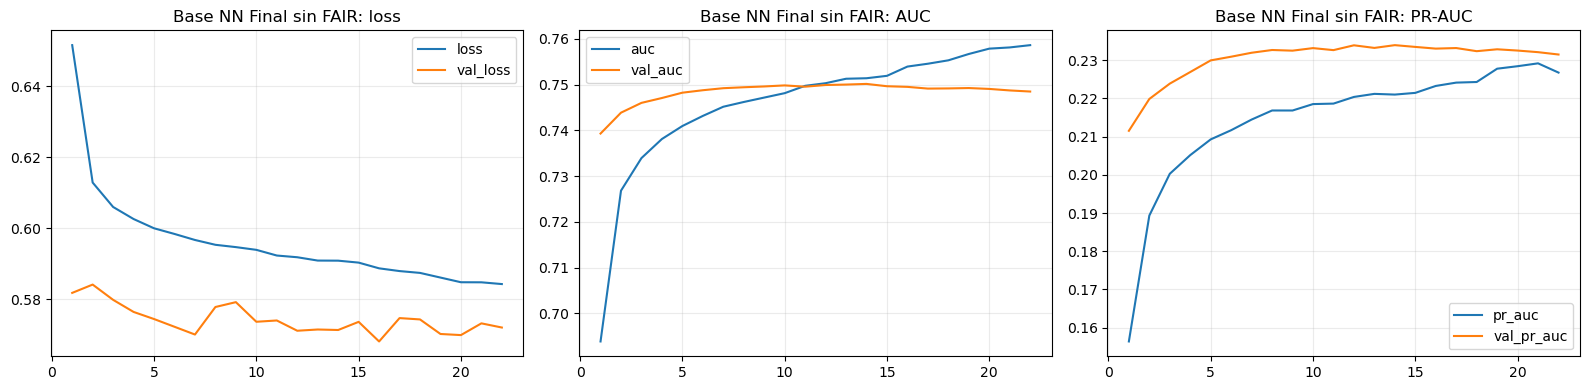

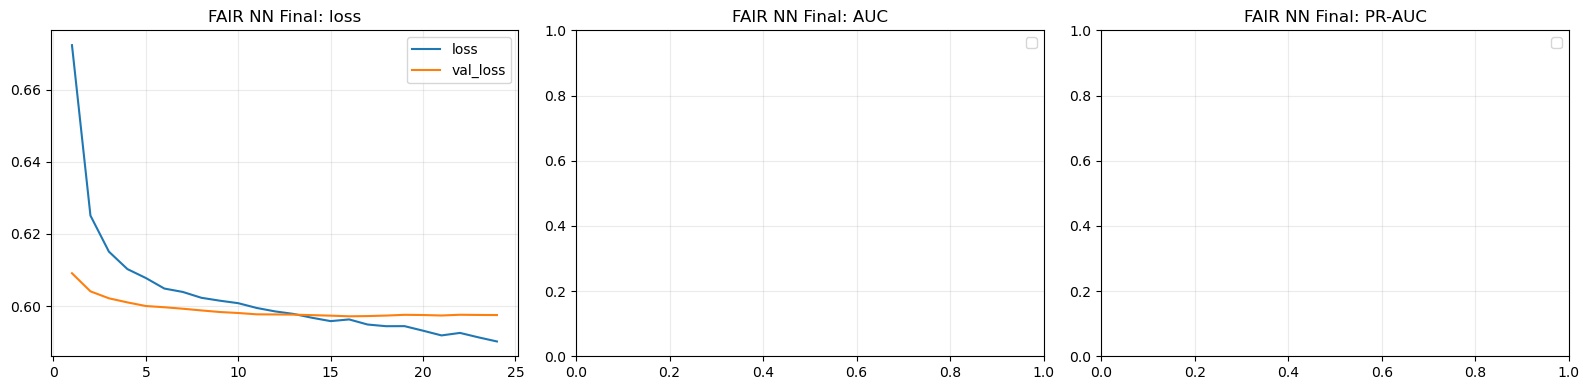

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


,model,threshold_strategy,threshold,accuracy,balanced_accuracy,roc_auc,pr_auc,brier_score,precision,recall,f1,tn,fp,fn,tp,mean_prediction,default_rate_real,corr_pred_gender,demographic_parity_gap_score,demographic_parity_gap_label,equal_opportunity_gap,fpr_gap,lambda_corr,evaluation_scope
0,Base NN Final sin FAIR,best_f1_validation,0.6500,0.8437,0.6526,0.7537,0.2407,0.1958,0.2379,0.4248,0.3050,37335,5068,2142,1582,0.4141,0.0807,0.1438,0.0590,0.0817,0.1175,0.0686,0.0000,full_test
1,FAIR NN Final,best_f1_validation,0.6600,0.8433,0.6481,0.7515,0.2397,0.2014,0.2345,0.4154,0.2997,37352,5051,2177,1547,0.4225,0.0807,0.0428,0.0174,0.0430,0.0435,0.0335,0.8000,full_test


In [29]:
if final_layer_choice == "adaptive":
    final_builder = build_adaptive_custom_layer_model
    final_custom_layer_type = "adaptive_tanh"
    final_lambda = best_lambda_adaptive
else:
    final_builder = build_custom_layer_model
    final_custom_layer_type = "original_common_tanh"
    final_lambda = best_lambda_fair

reset_seeds(42)
tf.keras.backend.clear_session()
base_final_model = final_builder(
    processed_dim=input_dim,
    dense_units=(64, 32),
    dropout_rates=(0.25, 0.20),
    learning_rate=1e-3,
    fair_lambda=None,
    model_name="Base_NN_Final_sin_FAIR",
)
assert_no_batchnorm(base_final_model)
history_base_final = base_final_model.fit(
    [X_train_keras, X_train_fin_raw],
    y_train_np,
    validation_data=([X_val_keras, X_val_fin_raw], y_val_np),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(monitor="val_auc", mode="max", patience=8),
    verbose=1,
)

reset_seeds(42)
tf.keras.backend.clear_session()
fair_final_model = final_builder(
    processed_dim=input_dim,
    dense_units=(64, 32),
    dropout_rates=(0.25, 0.20),
    learning_rate=1e-3,
    fair_lambda=final_lambda,
    model_name="FAIR_NN_Final",
)
assert_no_batchnorm(fair_final_model)
history_fair_final = fair_final_model.fit(
    [X_train_keras, X_train_fin_raw],
    y_train_ext,
    validation_data=([X_val_keras, X_val_fin_raw], y_val_ext, sample_weight_val),
    sample_weight=sample_weight_train,
    epochs=MAX_EPOCHS,
    batch_size=FAIR_BATCH_SIZE,
    callbacks=make_callbacks(monitor="val_loss", mode="min", patience=8),
    verbose=1,
)

plot_training_history(history_base_final, "Base NN Final sin FAIR", "loss_curve_base_final_no_fair.png")
plot_training_history(history_fair_final, "FAIR NN Final", "loss_curve_fair_final.png")

y_val_proba_base_final = base_final_model.predict([X_val_keras, X_val_fin_raw], batch_size=BATCH_SIZE).ravel()
y_test_proba_base_final = base_final_model.predict([X_test_keras, X_test_fin_raw], batch_size=BATCH_SIZE).ravel()
y_val_proba_fair_final = fair_final_model.predict([X_val_keras, X_val_fin_raw], batch_size=BATCH_SIZE).ravel()
y_test_proba_fair_final = fair_final_model.predict([X_test_keras, X_test_fin_raw], batch_size=BATCH_SIZE).ravel()

best_threshold_base_final, _ = find_best_threshold(y_val_np, y_val_proba_base_final, metric="f1")
best_threshold_fair_final, _ = find_best_threshold(y_val_np, y_val_proba_fair_final, metric="f1")

base_final_test_metrics = evaluate_model(
    "Base NN Final sin FAIR",
    y_test_np,
    y_test_proba_base_final,
    s_test_np,
    best_threshold_base_final,
    "best_f1_validation",
)
fair_final_test_metrics = evaluate_model(
    "FAIR NN Final",
    y_test_np,
    y_test_proba_fair_final,
    s_test_np,
    best_threshold_fair_final,
    "best_f1_validation",
)
base_final_test_metrics["lambda_corr"] = 0.0
fair_final_test_metrics["lambda_corr"] = final_lambda
base_final_test_metrics["evaluation_scope"] = "full_test"
fair_final_test_metrics["evaluation_scope"] = "full_test"
display(pd.DataFrame([base_final_test_metrics, fair_final_test_metrics]))


## Bootstrap final Base vs FAIR

Los intervalos se recalculan para el par final reentrenado.


In [30]:
def _fairness_gap_metrics(y_true, y_proba, sensitive, threshold):
    y_pred = (np.asarray(y_proba) >= threshold).astype(int)
    sensitive = np.asarray(sensitive).astype(int)
    male = sensitive == 1
    female = sensitive == 0
    demographic_gap = abs(np.mean(y_proba[male]) - np.mean(y_proba[female])) if male.sum() and female.sum() else np.nan
    tpr_m, fpr_m = _tpr_fpr_by_group(y_true, y_pred, sensitive, 1)
    tpr_f, fpr_f = _tpr_fpr_by_group(y_true, y_pred, sensitive, 0)
    eq_opp = abs(tpr_m - tpr_f) if pd.notna(tpr_m) and pd.notna(tpr_f) else np.nan
    fpr_gap = abs(fpr_m - fpr_f) if pd.notna(fpr_m) and pd.notna(fpr_f) else np.nan
    return demographic_gap, eq_opp, fpr_gap


def compute_bootstrap_base_vs_fair_final(
    y_test,
    y_test_proba_base_final,
    y_test_proba_fair_final,
    s_test,
    threshold_base,
    threshold_fair,
    n_boot=500,
    seed=42,
):
    rng = np.random.default_rng(seed)
    y_test = np.asarray(y_test).astype(int)
    s_test = np.asarray(s_test).astype(int)
    base_p = np.asarray(y_test_proba_base_final).astype(float)
    fair_p = np.asarray(y_test_proba_fair_final).astype(float)
    rows = []
    values = {
        ("roc_auc", "Base"): [],
        ("roc_auc", "FAIR"): [],
        ("pr_auc", "Base"): [],
        ("pr_auc", "FAIR"): [],
        ("abs_corr_pred_gender", "Base"): [],
        ("abs_corr_pred_gender", "FAIR"): [],
        ("demographic_parity_gap_score", "Base"): [],
        ("demographic_parity_gap_score", "FAIR"): [],
        ("equal_opportunity_gap", "Base"): [],
        ("equal_opportunity_gap", "FAIR"): [],
        ("fpr_gap", "Base"): [],
        ("fpr_gap", "FAIR"): [],
        ("delta_roc_auc_fair_minus_base", "FAIR - Base"): [],
        ("delta_pr_auc_fair_minus_base", "FAIR - Base"): [],
        ("delta_abs_corr_fair_minus_base", "FAIR - Base"): [],
        ("delta_demographic_parity_gap_fair_minus_base", "FAIR - Base"): [],
        ("delta_equal_opportunity_gap_fair_minus_base", "FAIR - Base"): [],
        ("delta_fpr_gap_fair_minus_base", "FAIR - Base"): [],
    }
    n = len(y_test)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_b = y_test[idx]
        s_b = s_test[idx]
        pb = base_p[idx]
        pf = fair_p[idx]
        if len(np.unique(y_b)) < 2:
            continue
        base_roc = _safe_roc_auc(y_b, pb)
        fair_roc = _safe_roc_auc(y_b, pf)
        base_pr = _safe_pr_auc(y_b, pb)
        fair_pr = _safe_pr_auc(y_b, pf)
        base_corr = abs(_safe_corr(pb, s_b))
        fair_corr = abs(_safe_corr(pf, s_b))
        base_demo, base_eq, base_fpr = _fairness_gap_metrics(y_b, pb, s_b, threshold_base)
        fair_demo, fair_eq, fair_fpr = _fairness_gap_metrics(y_b, pf, s_b, threshold_fair)
        metric_values = {
            ("roc_auc", "Base"): base_roc,
            ("roc_auc", "FAIR"): fair_roc,
            ("pr_auc", "Base"): base_pr,
            ("pr_auc", "FAIR"): fair_pr,
            ("abs_corr_pred_gender", "Base"): base_corr,
            ("abs_corr_pred_gender", "FAIR"): fair_corr,
            ("demographic_parity_gap_score", "Base"): base_demo,
            ("demographic_parity_gap_score", "FAIR"): fair_demo,
            ("equal_opportunity_gap", "Base"): base_eq,
            ("equal_opportunity_gap", "FAIR"): fair_eq,
            ("fpr_gap", "Base"): base_fpr,
            ("fpr_gap", "FAIR"): fair_fpr,
            ("delta_roc_auc_fair_minus_base", "FAIR - Base"): fair_roc - base_roc,
            ("delta_pr_auc_fair_minus_base", "FAIR - Base"): fair_pr - base_pr,
            ("delta_abs_corr_fair_minus_base", "FAIR - Base"): fair_corr - base_corr,
            ("delta_demographic_parity_gap_fair_minus_base", "FAIR - Base"): fair_demo - base_demo,
            ("delta_equal_opportunity_gap_fair_minus_base", "FAIR - Base"): fair_eq - base_eq,
            ("delta_fpr_gap_fair_minus_base", "FAIR - Base"): fair_fpr - base_fpr,
        }
        for key, value in metric_values.items():
            if pd.notna(value):
                values[key].append(float(value))

    for (metric, label), arr in values.items():
        arr = np.asarray(arr, dtype=float)
        if len(arr):
            rows.append({
                "metric": metric,
                "model_or_difference": label,
                "mean": float(np.mean(arr)),
                "ci_95_low": float(np.percentile(arr, 2.5)),
                "ci_95_high": float(np.percentile(arr, 97.5)),
                "n_boot_valid": int(len(arr)),
            })
        else:
            rows.append({
                "metric": metric,
                "model_or_difference": label,
                "mean": np.nan,
                "ci_95_low": np.nan,
                "ci_95_high": np.nan,
                "n_boot_valid": 0,
            })
    return pd.DataFrame(rows)


bootstrap_ci_base_vs_fair_final = compute_bootstrap_base_vs_fair_final(
    y_test_np,
    y_test_proba_base_final,
    y_test_proba_fair_final,
    s_test_np,
    best_threshold_base_final,
    best_threshold_fair_final,
    n_boot=N_BOOTSTRAP,
)
bootstrap_ci_base_vs_fair_final.to_csv(TABLE_DIR / "bootstrap_ci_base_vs_fair_final.csv", index=False)
display(bootstrap_ci_base_vs_fair_final)


,metric,model_or_difference,mean,ci_95_low,ci_95_high,n_boot_valid
0,roc_auc,Base,0.7538,0.7451,0.7623,500
1,roc_auc,FAIR,0.7515,0.7433,0.7598,500
2,pr_auc,Base,0.2411,0.2288,0.2553,500
3,pr_auc,FAIR,0.2397,0.2273,0.2537,500
4,abs_corr_pred_gender,Base,0.1438,0.1346,0.1526,500
5,abs_corr_pred_gender,FAIR,0.0428,0.0340,0.0517,500
6,demographic_parity_gap_score,Base,0.0590,0.0552,0.0627,500
7,demographic_parity_gap_score,FAIR,0.0174,0.0138,0.0210,500
8,equal_opportunity_gap,Base,0.1189,0.0848,0.1521,500
9,equal_opportunity_gap,FAIR,0.0449,0.0109,0.0799,500


## Tabla final Base vs FAIR con intervalos


In [31]:
def bootstrap_ci_lookup(metric, label):
    row = bootstrap_ci_base_vs_fair_final[
        (bootstrap_ci_base_vs_fair_final["metric"] == metric)
        & (bootstrap_ci_base_vs_fair_final["model_or_difference"] == label)
    ]
    if row.empty:
        return np.nan
    row = row.iloc[0]
    return f"[{row['ci_95_low']:.4f}, {row['ci_95_high']:.4f}]"


calibrator_base_final = LogisticRegression(solver="lbfgs")
calibrator_base_final.fit(y_val_proba_base_final.reshape(-1, 1), y_val_np.astype(int))
calibrator_fair_final = LogisticRegression(solver="lbfgs")
calibrator_fair_final.fit(y_val_proba_fair_final.reshape(-1, 1), y_val_np.astype(int))
y_val_proba_base_final_cal = calibrator_base_final.predict_proba(y_val_proba_base_final.reshape(-1, 1))[:, 1]
y_test_proba_base_final_cal = calibrator_base_final.predict_proba(y_test_proba_base_final.reshape(-1, 1))[:, 1]
y_val_proba_fair_final_cal = calibrator_fair_final.predict_proba(y_val_proba_fair_final.reshape(-1, 1))[:, 1]
y_test_proba_fair_final_cal = calibrator_fair_final.predict_proba(y_test_proba_fair_final.reshape(-1, 1))[:, 1]


def final_result_row(metrics, label, lambda_corr, brier_calibrated, model_label_for_ci):
    return {
        "model": label,
        "custom_layer_type": final_custom_layer_type,
        "lambda_corr": lambda_corr,
        "threshold_strategy": metrics["threshold_strategy"],
        "threshold_usado": metrics["threshold"],
        "accuracy_test": metrics["accuracy"],
        "balanced_accuracy_test": metrics["balanced_accuracy"],
        "roc_auc_test": metrics["roc_auc"],
        "roc_auc_ci95": bootstrap_ci_lookup("roc_auc", model_label_for_ci),
        "pr_auc_test": metrics["pr_auc"],
        "pr_auc_ci95": bootstrap_ci_lookup("pr_auc", model_label_for_ci),
        "brier_uncalibrated_test": metrics["brier_score"],
        "brier_calibrated_test": brier_calibrated,
        "precision_test": metrics["precision"],
        "recall_test": metrics["recall"],
        "f1_test": metrics["f1"],
        "corr_pred_gender_test": metrics["corr_pred_gender"],
        "abs_corr_pred_gender_test": abs(metrics["corr_pred_gender"]),
        "abs_corr_pred_gender_ci95": bootstrap_ci_lookup("abs_corr_pred_gender", model_label_for_ci),
        "demographic_parity_gap_score_test": metrics["demographic_parity_gap_score"],
        "demographic_parity_gap_score_ci95": bootstrap_ci_lookup("demographic_parity_gap_score", model_label_for_ci),
        "equal_opportunity_gap_test": metrics["equal_opportunity_gap"],
        "equal_opportunity_gap_ci95": bootstrap_ci_lookup("equal_opportunity_gap", model_label_for_ci),
        "fpr_gap_test": metrics["fpr_gap"],
        "fpr_gap_ci95": bootstrap_ci_lookup("fpr_gap", model_label_for_ci),
        "tn": metrics["tn"],
        "fp": metrics["fp"],
        "fn": metrics["fn"],
        "tp": metrics["tp"],
    }


tabla_base_vs_fair_test_final = pd.DataFrame([
    final_result_row(
        base_final_test_metrics,
        "Base NN Final sin FAIR",
        0.0,
        brier_score_loss(y_test_np, y_test_proba_base_final_cal),
        "Base",
    ),
    final_result_row(
        fair_final_test_metrics,
        "FAIR NN Final",
        final_lambda,
        brier_score_loss(y_test_np, y_test_proba_fair_final_cal),
        "FAIR",
    ),
])
tabla_base_vs_fair_test_final.to_csv(TABLE_DIR / "tabla_base_vs_fair_test_final.csv", index=False)
display(tabla_base_vs_fair_test_final)

diff_metric_map = {
    "roc_auc": ("roc_auc_test", "delta_roc_auc_fair_minus_base"),
    "pr_auc": ("pr_auc_test", "delta_pr_auc_fair_minus_base"),
    "abs_corr_pred_gender": ("abs_corr_pred_gender_test", "delta_abs_corr_fair_minus_base"),
    "demographic_parity_gap_score": ("demographic_parity_gap_score_test", "delta_demographic_parity_gap_fair_minus_base"),
    "equal_opportunity_gap": ("equal_opportunity_gap_test", "delta_equal_opportunity_gap_fair_minus_base"),
    "fpr_gap": ("fpr_gap_test", "delta_fpr_gap_fair_minus_base"),
    "precision": ("precision_test", None),
    "recall": ("recall_test", None),
    "f1": ("f1_test", None),
    "brier_calibrated": ("brier_calibrated_test", None),
}
diff_rows = []
for metric, (col, boot_metric) in diff_metric_map.items():
    base_value = tabla_base_vs_fair_test_final.loc[0, col]
    fair_value = tabla_base_vs_fair_test_final.loc[1, col]
    diff = fair_value - base_value
    ci_low = np.nan
    ci_high = np.nan
    if boot_metric is not None:
        boot_row = bootstrap_ci_base_vs_fair_final[
            (bootstrap_ci_base_vs_fair_final["metric"] == boot_metric)
            & (bootstrap_ci_base_vs_fair_final["model_or_difference"] == "FAIR - Base")
        ]
        if not boot_row.empty:
            ci_low = float(boot_row.iloc[0]["ci_95_low"])
            ci_high = float(boot_row.iloc[0]["ci_95_high"])

    if metric == "roc_auc" and pd.notna(ci_low) and ci_low <= 0 <= ci_high:
        interpretation = "La diferencia de AUC es pequeña y compatible con ausencia de pérdida estadísticamente clara."
    elif metric == "abs_corr_pred_gender" and pd.notna(ci_high) and ci_high < 0:
        interpretation = "La reducción de dependencia con género es robusta."
    elif metric in ["demographic_parity_gap_score", "equal_opportunity_gap", "fpr_gap"]:
        interpretation = "Mejora fairness si la diferencia es negativa; revisar el intervalo si existe."
    elif metric == "brier_calibrated":
        interpretation = "Mejora si negativo porque Brier menor indica mejor calibración."
    else:
        interpretation = "Mejora si positivo; coste si negativo."

    diff_rows.append({
        "metric": metric,
        "base_value": base_value,
        "fair_value": fair_value,
        "difference_fair_minus_base": diff,
        "ci_95_low": ci_low,
        "ci_95_high": ci_high,
        "interpretation": interpretation,
    })

tabla_base_vs_fair_differences_final = pd.DataFrame(diff_rows)
tabla_base_vs_fair_differences_final.to_csv(TABLE_DIR / "tabla_base_vs_fair_differences_final.csv", index=False)
display(tabla_base_vs_fair_differences_final)


,model,custom_layer_type,lambda_corr,threshold_strategy,threshold_usado,accuracy_test,balanced_accuracy_test,roc_auc_test,roc_auc_ci95,pr_auc_test,pr_auc_ci95,brier_uncalibrated_test,brier_calibrated_test,precision_test,recall_test,f1_test,corr_pred_gender_test,abs_corr_pred_gender_test,abs_corr_pred_gender_ci95,demographic_parity_gap_score_test,demographic_parity_gap_score_ci95,equal_opportunity_gap_test,equal_opportunity_gap_ci95,fpr_gap_test,fpr_gap_ci95,tn,fp,fn,tp
0,Base NN Final sin FAIR,adaptive_tanh,0.0000,best_f1_validation,0.6500,0.8437,0.6526,0.7537,"[0.7451, 0.7623]",0.2407,"[0.2288, 0.2553]",0.1958,0.0681,0.2379,0.4248,0.3050,0.1438,0.1438,"[0.1346, 0.1526]",0.0590,"[0.0552, 0.0627]",0.1175,"[0.0848, 0.1521]",0.0686,"[0.0621, 0.0752]",37335,5068,2142,1582
1,FAIR NN Final,adaptive_tanh,0.8000,best_f1_validation,0.6600,0.8433,0.6481,0.7515,"[0.7433, 0.7598]",0.2397,"[0.2273, 0.2537]",0.2014,0.0683,0.2345,0.4154,0.2997,0.0428,0.0428,"[0.0340, 0.0517]",0.0174,"[0.0138, 0.0210]",0.0435,"[0.0109, 0.0799]",0.0335,"[0.0274, 0.0400]",37352,5051,2177,1547


,metric,base_value,fair_value,difference_fair_minus_base,ci_95_low,ci_95_high,interpretation
0,roc_auc,0.7537,0.7515,-0.0022,-0.0040,-0.0005,Mejora si positivo; coste si negativo.
1,pr_auc,0.2407,0.2397,-0.0010,-0.0043,0.0012,Mejora si positivo; coste si negativo.
2,abs_corr_pred_gender,0.1438,0.0428,-0.1010,-0.1030,-0.0990,La reducción de dependencia con género es robu...
3,demographic_parity_gap_score,0.0590,0.0174,-0.0416,-0.0424,-0.0408,Mejora fairness si la diferencia es negativa; ...
4,equal_opportunity_gap,0.1175,0.0435,-0.0740,-0.0889,-0.0598,Mejora fairness si la diferencia es negativa; ...
5,fpr_gap,0.0686,0.0335,-0.0351,-0.0383,-0.0317,Mejora fairness si la diferencia es negativa; ...
6,precision,0.2379,0.2345,-0.0034,NaN,NaN,Mejora si positivo; coste si negativo.
7,recall,0.4248,0.4154,-0.0094,NaN,NaN,Mejora si positivo; coste si negativo.
8,f1,0.3050,0.2997,-0.0052,NaN,NaN,Mejora si positivo; coste si negativo.
9,brier_calibrated,0.0681,0.0683,0.0002,NaN,NaN,Mejora si negativo porque Brier menor indica m...


## Umbrales sobre scores brutos y probabilidades calibradas

Las probabilidades brutas de la red son scores de ranking. Las probabilidades calibradas son más apropiadas si se quieren interpretar como PD o elegir thresholds de decisión con costes.


In [32]:
threshold_rows_final = []
for model_name, val_raw, test_raw, val_cal, test_cal in [
    ("Base NN Final sin FAIR", y_val_proba_base_final, y_test_proba_base_final, y_val_proba_base_final_cal, y_test_proba_base_final_cal),
    ("FAIR NN Final", y_val_proba_fair_final, y_test_proba_fair_final, y_val_proba_fair_final_cal, y_test_proba_fair_final_cal),
]:
    for probability_type, val_proba, test_proba in [
        ("raw_score", val_raw, test_raw),
        ("calibrated_probability", val_cal, test_cal),
    ]:
        f1_threshold, _ = find_best_threshold(y_val_np, val_proba, metric="f1")
        cost_threshold, _ = find_best_threshold_by_cost(y_val_np, val_proba, cost_fp=1.0, cost_fn=5.0)
        for strategy, threshold in [
            ("fixed_0_50", 0.5),
            ("best_f1_validation", f1_threshold),
            ("minimum_cost_validation", cost_threshold),
        ]:
            metrics = evaluate_model(model_name, y_test_np, test_proba, s_test_np, threshold, strategy)
            threshold_rows_final.append({
                "model": model_name,
                "probability_type": probability_type,
                "threshold_strategy": strategy,
                "threshold": threshold,
                "roc_auc_test": metrics["roc_auc"],
                "pr_auc_test": metrics["pr_auc"],
                "brier_score_test": metrics["brier_score"],
                "accuracy_test": metrics["accuracy"],
                "precision_test": metrics["precision"],
                "recall_test": metrics["recall"],
                "f1_test": metrics["f1"],
                "total_cost_test": cost_at_threshold(y_test_np, test_proba, threshold, 1.0, 5.0),
                "mean_predicted_probability": float(np.mean(test_proba)),
                "real_default_rate": float(np.mean(y_test_np)),
            })

threshold_raw_vs_calibrated_comparison = pd.DataFrame(threshold_rows_final)
threshold_raw_vs_calibrated_comparison.to_csv(TABLE_DIR / "threshold_raw_vs_calibrated_comparison.csv", index=False)
display(threshold_raw_vs_calibrated_comparison)


,model,probability_type,threshold_strategy,threshold,roc_auc_test,pr_auc_test,brier_score_test,accuracy_test,precision_test,recall_test,f1_test,total_cost_test,mean_predicted_probability,real_default_rate
0,Base NN Final sin FAIR,raw_score,fixed_0_50,0.5000,0.7537,0.2407,0.1958,0.7035,0.1660,0.6643,0.2657,"18,677.0000",0.4141,0.0807
1,Base NN Final sin FAIR,raw_score,best_f1_validation,0.6500,0.7537,0.2407,0.1958,0.8437,0.2379,0.4248,0.3050,"15,778.0000",0.4141,0.0807
2,Base NN Final sin FAIR,raw_score,minimum_cost_validation,0.6500,0.7537,0.2407,0.1958,0.8437,0.2379,0.4248,0.3050,"15,778.0000",0.4141,0.0807
3,Base NN Final sin FAIR,calibrated_probability,fixed_0_50,0.5000,0.7537,0.2407,0.0681,0.9193,0.0000,0.0000,0.0000,"18,620.0000",0.0818,0.0807
4,Base NN Final sin FAIR,calibrated_probability,best_f1_validation,0.1600,0.7537,0.2407,0.0681,0.8423,0.2370,0.4299,0.3056,"15,768.0000",0.0818,0.0807
5,Base NN Final sin FAIR,calibrated_probability,minimum_cost_validation,0.1600,0.7537,0.2407,0.0681,0.8423,0.2370,0.4299,0.3056,"15,768.0000",0.0818,0.0807
6,FAIR NN Final,raw_score,fixed_0_50,0.5000,0.7515,0.2397,0.2014,0.6986,0.1651,0.6740,0.2653,"18,760.0000",0.4225,0.0807
7,FAIR NN Final,raw_score,best_f1_validation,0.6600,0.7515,0.2397,0.2014,0.8433,0.2345,0.4154,0.2997,"15,936.0000",0.4225,0.0807
8,FAIR NN Final,raw_score,minimum_cost_validation,0.6700,0.7515,0.2397,0.2014,0.8497,0.2411,0.4015,0.3013,"15,851.0000",0.4225,0.0807
9,FAIR NN Final,calibrated_probability,fixed_0_50,0.5000,0.7515,0.2397,0.0683,0.9193,0.0000,0.0000,0.0000,"18,620.0000",0.0819,0.0807


## Incertidumbre como fiabilidad, no riesgo

La probabilidad media predicha mide riesgo. La varianza MC Dropout mide confianza o estabilidad de la predicción. Alta incertidumbre no debe interpretarse como riesgo de default, sino como menor fiabilidad del modelo.


,policy_name,uncertainty_threshold_source,uncertainty_threshold_value,coverage_automated,coverage_human_review,n_total_test,n_automated,n_human_review,default_rate_automated,default_rate_human_review,roc_auc_automated,roc_auc_human_review,pr_auc_automated,pr_auc_human_review,mean_variance_automated,mean_variance_human_review,interpretation
0,MC Dropout p90 validation final,validation,0.0034,0.9011,0.0989,46127,41567,4560,0.0826,0.0636,0.7563,0.6841,0.2466,0.1239,0.0021,0.0042,Alta incertidumbre indica menor fiabilidad: el...


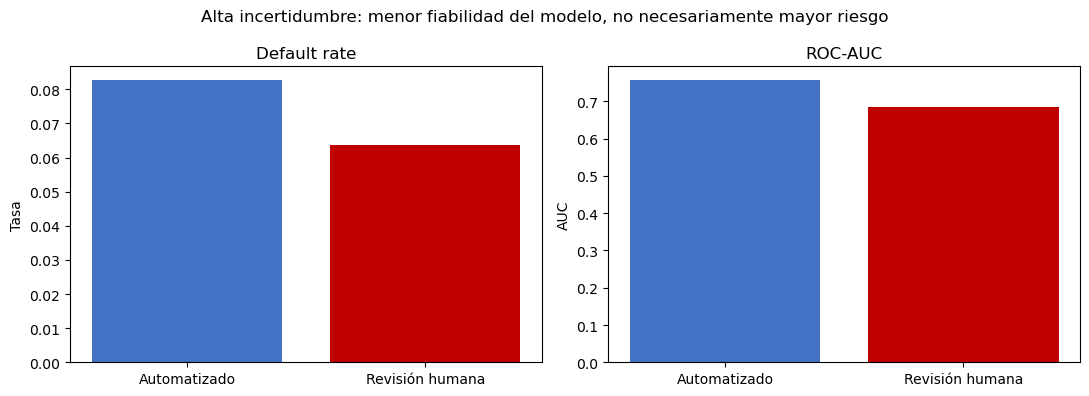

In [33]:
assert_no_batchnorm(fair_final_model)
val_mean_mc_final, val_var_mc_final, val_std_mc_final = mc_dropout_predict(
    fair_final_model,
    [X_val_keras, X_val_fin_raw],
    n_samples=N_MC_SAMPLES,
)
uncertainty_threshold_final = float(np.percentile(val_var_mc_final, 90))
test_mean_mc_final, test_var_mc_final, test_std_mc_final = mc_dropout_predict(
    fair_final_model,
    [X_test_keras, X_test_fin_raw],
    n_samples=N_MC_SAMPLES,
)
test_pred_class_final = (test_mean_mc_final >= best_threshold_fair_final).astype(int)
high_uncertainty_final = test_var_mc_final >= uncertainty_threshold_final
automated_final = ~high_uncertainty_final
review_final = high_uncertainty_final

roc_auc_automated = _safe_roc_auc(y_test_np[automated_final], test_mean_mc_final[automated_final])
roc_auc_human_review = _safe_roc_auc(y_test_np[review_final], test_mean_mc_final[review_final])
default_rate_automated = float(np.mean(y_test_np[automated_final]))
default_rate_human_review = float(np.mean(y_test_np[review_final]))

if pd.notna(roc_auc_human_review) and pd.notna(roc_auc_automated) and roc_auc_human_review < roc_auc_automated:
    reliability_interpretation = (
        "Alta incertidumbre indica menor fiabilidad: el modelo discrimina peor en los casos enviados a revisión humana."
    )
else:
    reliability_interpretation = (
        "La alta incertidumbre no muestra peor discriminación en este experimento; debe interpretarse con cautela."
    )
if default_rate_human_review <= default_rate_automated:
    reliability_interpretation += " Alta incertidumbre no implica mayor tasa de default."

selective_prediction_policy_results_final = pd.DataFrame([{
    "policy_name": "MC Dropout p90 validation final",
    "uncertainty_threshold_source": "validation",
    "uncertainty_threshold_value": uncertainty_threshold_final,
    "coverage_automated": float(automated_final.mean()),
    "coverage_human_review": float(review_final.mean()),
    "n_total_test": int(len(y_test_np)),
    "n_automated": int(automated_final.sum()),
    "n_human_review": int(review_final.sum()),
    "default_rate_automated": default_rate_automated,
    "default_rate_human_review": default_rate_human_review,
    "roc_auc_automated": roc_auc_automated,
    "roc_auc_human_review": roc_auc_human_review,
    "pr_auc_automated": _safe_pr_auc(y_test_np[automated_final], test_mean_mc_final[automated_final]),
    "pr_auc_human_review": _safe_pr_auc(y_test_np[review_final], test_mean_mc_final[review_final]),
    "mean_variance_automated": float(np.mean(test_var_mc_final[automated_final])),
    "mean_variance_human_review": float(np.mean(test_var_mc_final[review_final])),
    "interpretation": reliability_interpretation,
}])
selective_prediction_policy_results_final.to_csv(TABLE_DIR / "selective_prediction_policy_results_final.csv", index=False)
display(selective_prediction_policy_results_final)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(["Automatizado", "Revisión humana"], [default_rate_automated, default_rate_human_review], color=["#4472C4", "#C00000"])
axes[0].set_title("Default rate")
axes[0].set_ylabel("Tasa")
axes[1].bar(["Automatizado", "Revisión humana"], [roc_auc_automated, roc_auc_human_review], color=["#4472C4", "#C00000"])
axes[1].set_title("ROC-AUC")
axes[1].set_ylabel("AUC")
fig.suptitle("Alta incertidumbre: menor fiabilidad del modelo, no necesariamente mayor riesgo")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "selective_policy_reliability_not_risk.png", dpi=140, bbox_inches="tight")
plt.show()


## Tabla general: benchmark predictivo vs modelo de la práctica

HistGradientBoosting es el mejor benchmark predictivo tabular si lidera la tabla, pero el modelo principal de la práctica es la red FAIR final porque integra capa custom, FAIR loss e incertidumbre.


In [34]:
def assign_role(row):
    name = str(row.get("model", ""))
    scope = row.get("evaluation_scope", "full_test")
    if scope == "selective_coverage":
        return "política selectiva"
    if "HistGradientBoosting" in name:
        return "benchmark predictivo"
    if "AutoML" in name or "Keras Tuner" in name:
        return "automl predictivo"
    if "FAIR" in name:
        return "modelo neuronal fair"
    if "Base" in name or "Neural" in name or "NN" in name:
        return "modelo neuronal base"
    return "benchmark predictivo"


existing_results = results_df.copy() if "results_df" in globals() else pd.DataFrame(results_full_test)
final_rows_for_general = pd.DataFrame([base_final_test_metrics, fair_final_test_metrics])
model_comparison_results = pd.concat([existing_results, final_rows_for_general], ignore_index=True, sort=False)
model_comparison_results["evaluation_scope"] = model_comparison_results.get("evaluation_scope", "full_test").fillna("full_test")
model_comparison_results["role"] = model_comparison_results.apply(assign_role, axis=1)
model_comparison_results.to_csv(TABLE_DIR / "model_comparison_results.csv", index=False)
display(model_comparison_results.sort_values("roc_auc", ascending=False))


,model,threshold_strategy,threshold,accuracy,balanced_accuracy,roc_auc,pr_auc,brier_score,precision,recall,f1,tn,fp,fn,tp,mean_prediction,default_rate_real,corr_pred_gender,demographic_parity_gap_score,demographic_parity_gap_label,equal_opportunity_gap,fpr_gap,evaluation_scope,validation_best_f1,lambda_corr,role
2,HistGradientBoosting,best_f1_validation,0.1600,0.8588,0.6513,0.7605,0.2552,0.0674,0.2594,0.4039,0.3159,38110,4293,2220,1504,0.0809,0.0807,0.1172,0.0194,0.0645,0.1009,0.0514,full_test,0.3083,NaN,benchmark predictivo
6,Base NN Final sin FAIR,best_f1_validation,0.6500,0.8437,0.6526,0.7537,0.2407,0.1958,0.2379,0.4248,0.3050,37335,5068,2142,1582,0.4141,0.0807,0.1438,0.0590,0.0817,0.1175,0.0686,full_test,NaN,0.0000,modelo neuronal fair
5,AutoML Keras Tuner,best_f1_validation,0.6600,0.8463,0.6498,0.7529,0.2435,0.1971,0.2395,0.4154,0.3039,37492,4911,2177,1547,0.4145,0.0807,0.1431,0.0599,0.0812,0.1118,0.0688,full_test,NaN,NaN,automl predictivo
3,Base NN Custom Layer original sin FAIR,best_f1_validation,0.6500,0.8404,0.6521,0.7529,0.2402,0.1995,0.2334,0.4275,0.3019,37173,5230,2132,1592,0.4213,0.0807,0.1408,0.0563,0.0810,0.1096,0.0686,full_test,NaN,0.0000,modelo neuronal fair
7,FAIR NN Final,best_f1_validation,0.6600,0.8433,0.6481,0.7515,0.2397,0.2014,0.2345,0.4154,0.2997,37352,5051,2177,1547,0.4225,0.0807,0.0428,0.0174,0.0430,0.0435,0.0335,full_test,NaN,0.8000,modelo neuronal fair
4,FAIR NN Custom Layer candidato original,best_f1_validation,0.6600,0.8451,0.6475,0.7513,0.2397,0.2003,0.2364,0.4119,0.3004,37448,4955,2190,1534,0.4200,0.0807,0.0375,0.0154,0.0427,0.0408,0.0334,full_test,NaN,1.0000,modelo neuronal fair
1,Logistic Regression,best_f1_validation,0.6600,0.8396,0.6494,0.7470,0.2346,0.2051,0.2306,0.4227,0.2984,37152,5251,2150,1574,0.4249,0.0807,0.1338,0.0563,0.0751,0.0904,0.0641,full_test,0.2919,NaN,benchmark predictivo
0,Dummy prior,best_f1_validation,0.0100,0.0807,0.5000,0.5000,0.0807,0.0742,0.0807,1.0000,0.1494,0,42403,0,3724,0.0807,0.0807,NaN,0.0000,0.0000,0.0000,0.0000,full_test,0.1494,NaN,benchmark predictivo


## Resumen, guion y README finales


In [35]:
best_predictive_model = model_comparison_results[
    model_comparison_results["evaluation_scope"].eq("full_test")
].sort_values("roc_auc", ascending=False).iloc[0]["model"]
delta_auc_final = (
    tabla_base_vs_fair_test_final.loc[1, "roc_auc_test"]
    - tabla_base_vs_fair_test_final.loc[0, "roc_auc_test"]
)
delta_corr_final = (
    tabla_base_vs_fair_test_final.loc[1, "abs_corr_pred_gender_test"]
    - tabla_base_vs_fair_test_final.loc[0, "abs_corr_pred_gender_test"]
)
auc_diff_ci = bootstrap_ci_base_vs_fair_final[
    bootstrap_ci_base_vs_fair_final["metric"].eq("delta_roc_auc_fair_minus_base")
].iloc[0]
auc_loss_text = (
    "La pérdida de AUC no es estadísticamente clara porque el intervalo bootstrap incluye 0."
    if auc_diff_ci["ci_95_low"] <= 0 <= auc_diff_ci["ci_95_high"]
    else "La diferencia de AUC no incluye 0 en el intervalo bootstrap y debe reportarse como coste o mejora."
)

summary_final = f"""# Resumen ejecutivo final

## 1. Selección metodológica
El modelo final se selecciona únicamente con validation y auditoría de saturación en train. El test se reserva para evaluación final.

## 2. Benchmark predictivo
El mejor benchmark predictivo puede ser `{best_predictive_model}`. Se reporta honestamente, pero no es el modelo central del taller.

## 3. Modelo de la práctica
La red FAIR final usa capa `{final_custom_layer_type}`, FAIR loss e incertidumbre MC Dropout. La capa adaptativa solo se elige si validation y la auditoría de saturación la justifican.

## 4. Fairness y coste predictivo
Delta AUC FAIR - Base: {delta_auc_final:.4f}. Delta dependencia absoluta con género FAIR - Base: {delta_corr_final:.4f}. {auc_loss_text}

## 5. Incertidumbre
MC Dropout devuelve clase y varianza por observación. Alta incertidumbre significa menor fiabilidad del modelo, no necesariamente mayor riesgo de default.

## 6. Calibración
Las probabilidades brutas de la red son scores. Las probabilidades calibradas son necesarias para interpretarlas como PD o elegir thresholds de decisión.

## 7. Limitaciones
AutoML es predictivo + análisis de fairness, no multiobjetivo Pareto puro. FAIR loss penaliza correlación lineal, no toda dependencia. MC Dropout es una aproximación de incertidumbre.
"""
Path("resumen_presentacion_5min_final.md").write_text(summary_final, encoding="utf-8")
Path("resumen_presentacion_5min.md").write_text(summary_final, encoding="utf-8")

guion_final = f"""# Guion presentación 5 minutos

## Slide 1 — Problema
Trabajo con Home Credit Default Risk. TARGET mide dificultad de pago y CODE_GENDER se usa solo para auditar fairness.

## Slide 2 — Capa custom
La capa custom calcula ratios financieros sobre importes reales. La versión adaptativa se elige solo si validation y la auditoría en train muestran que corrige la saturación de CREDIT_INCOME_RATIO sin perder AUC relevante.

## Slide 3 — FAIR loss
La pérdida es BCE + lambda * corr(predicción, género)^2. El lambda se selecciona en validation, no en test.

## Slide 4 — Resultados Base vs FAIR
El modelo FAIR final reduce dependencia con género con delta AUC {delta_auc_final:.4f}. {auc_loss_text}

## Slide 5 — Incertidumbre
MC Dropout devuelve clase y varianza. La varianza no mide riesgo directo; mide fiabilidad o estabilidad de la predicción. Los casos menos fiables pueden ir a revisión humana.

## Slide 6 — Limitaciones
HistGradientBoosting puede ganar como benchmark predictivo. AutoML no es multiobjetivo Pareto puro. Las probabilidades brutas necesitan calibración. FAIR loss solo penaliza correlación lineal.

## Cierre
El modelo final no maximiza únicamente AUC: equilibra predicción, justicia demográfica e incertidumbre.
"""
Path("guion_presentacion_5min_final.md").write_text(guion_final, encoding="utf-8")

readme_final = f"""# Taller B4-T1: Redes Confiables para Credit Scoring

## Objetivo
Construir y auditar un sistema de credit scoring con capa custom financiera, FAIR loss, calibración e incertidumbre.

## Decisiones metodológicas finales
- El test no se usa para seleccionar modelos.
- La capa adaptativa se elige por validation y auditoría de saturación en train.
- LayerNormalization sustituye BatchNormalization en modelos usados con MC Dropout.
- El umbral de incertidumbre se fija en validation.
- La política de revisión humana no se mezcla con la tabla general de modelos.
- Las probabilidades se calibran para interpretarse como PD.
- AutoML es predictivo + análisis de fairness, no AutoML fairness multiobjetivo completo.

## Cómo interpretar los resultados
- `{best_predictive_model}` puede ser el mejor benchmark predictivo tabular.
- La red FAIR final es el modelo principal de la práctica porque integra custom layer, FAIR loss e incertidumbre.
- Alta incertidumbre no significa necesariamente mayor riesgo, sino menor confianza del modelo.

## Archivos
Ver `tables/`, `figures/`, `resumen_presentacion_5min_final.md` y `guion_presentacion_5min_final.md`.
"""
Path("README.md").write_text(readme_final, encoding="utf-8")

display(Markdown(summary_final))


# Resumen ejecutivo final

## 1. Selección metodológica
El modelo final se selecciona únicamente con validation y auditoría de saturación en train. El test se reserva para evaluación final.

## 2. Benchmark predictivo
El mejor benchmark predictivo puede ser `HistGradientBoosting`. Se reporta honestamente, pero no es el modelo central del taller.

## 3. Modelo de la práctica
La red FAIR final usa capa `adaptive_tanh`, FAIR loss e incertidumbre MC Dropout. La capa adaptativa solo se elige si validation y la auditoría de saturación la justifican.

## 4. Fairness y coste predictivo
Delta AUC FAIR - Base: -0.0022. Delta dependencia absoluta con género FAIR - Base: -0.1010. La diferencia de AUC no incluye 0 en el intervalo bootstrap y debe reportarse como coste o mejora.

## 5. Incertidumbre
MC Dropout devuelve clase y varianza por observación. Alta incertidumbre significa menor fiabilidad del modelo, no necesariamente mayor riesgo de default.

## 6. Calibración
Las probabilidades brutas de la red son scores. Las probabilidades calibradas son necesarias para interpretarlas como PD o elegir thresholds de decisión.

## 7. Limitaciones
AutoML es predictivo + análisis de fairness, no multiobjetivo Pareto puro. FAIR loss penaliza correlación lineal, no toda dependencia. MC Dropout es una aproximación de incertidumbre.


## Control final de calidad v4


In [36]:
required_files_final = [
    "tables/final_model_selection_validation_only.csv",
    "tables/lambda_adaptive_seed_results_validation.csv",
    "tables/lambda_adaptive_seed_results_test.csv",
    "tables/lambda_adaptive_sweep_summary_by_seed.csv",
    "tables/best_lambda_adaptive_selection.csv",
    "tables/bootstrap_ci_base_vs_fair_final.csv",
    "tables/tabla_base_vs_fair_test_final.csv",
    "tables/tabla_base_vs_fair_differences_final.csv",
    "tables/model_comparison_results.csv",
    "tables/selective_prediction_policy_results_final.csv",
    "figures/selective_policy_reliability_not_risk.png",
    "resumen_presentacion_5min_final.md",
    "guion_presentacion_5min_final.md",
    "README.md",
]

for f in required_files_final:
    assert os.path.exists(f), f"Falta archivo obligatorio: {f}"

print("Notebook v4 final corregido generado correctamente. Todos los archivos clave existen.")


Notebook v4 final corregido generado correctamente. Todos los archivos clave existen.
